<div style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0;">

<div style="border: 1px solid rgba(147,197,253,0.55); padding: 24px 20px; border-radius: 10px; text-align: center; background: linear-gradient(135deg, #1e3a8a, #2563eb); box-shadow: 0 10px 24px rgba(30,58,138,0.22);">
    <div style="display: inline-block; padding: 6px 14px; margin-bottom: 10px; border-radius: 999px; background: rgba(219,234,254,0.12); border: 1px solid rgba(191,219,254,0.28); font-size: 0.95em; letter-spacing: 0.02em; color: #dbeafe; font-weight: 500;">Fayçal El Bouzidi &nbsp;&nbsp;|&nbsp;&nbsp; Victor d'Anglejean &nbsp;&nbsp;|&nbsp;&nbsp; Owen Manach</div>
    <h1 style="color: #eff6ff; margin: 0; font-weight: 700;">Higher Order Swap Replication</h1>
    <p style="font-size: 1.05em; color: #dbeafe; margin: 8px 0 0 0;">Volatility Strategies</p>
</div>

<hr style="border-color: #60a5fa; opacity: 0.5;">

<h3 style="color: #dbeafe;">Objectif du Projet</h3>

<p style="color: #dbeafe;">L'objectif principal de ce notebook est d'étudier la <strong>réplication des swaps de volatilité</strong> à partir de portefeuilles d'options vanilles, puis d'évaluer comment ces instruments peuvent être utilisés seuls ou combinés à une <strong>stratégie de carry optionnelle</strong>. Nous analysons successivement la construction de variance, gamma, skew et M4 swaps, leur mise en œuvre empirique, leur backtest, puis leur interaction avec un carry de type <strong>short strangle delta-hedgé</strong>.</p>

<hr style="border-color: #60a5fa; opacity: 0.5;">

<h3 style="color: #dbeafe;">Démarche Analytique</h3>

<p style="color: #dbeafe;">Le projet suit une progression simple : partir de la réplication, construire les stratégies, puis mesurer leur comportement isolé et en combinaison.</p>

<ol style="color: #dbeafe;">
    <li><strong>Réplication des Swaps :</strong> Pour chaque contrat (Variance, Gamma, Skew et M4), nous introduisons le payoff visé et le <strong>noyau de réplication</strong> permettant de le reconstruire à partir d'options OTM.</li>
    <li><strong>Construction d'une Stratégie de Carry :</strong> Nous mettons en place une stratégie de carry optionnelle de référence, fondée sur la vente d'un <strong>strangle delta-hedgé</strong>, afin de disposer d'un portefeuille de base réaliste.</li>
    <li><strong>Backtesting Individuel :</strong> Nous backtestons séparément chaque swap répliqué et la stratégie de carry afin d'identifier leurs sources de performance, leur profil de risque et leur comportement dans le temps.</li>
    <li><strong>Interaction Carry / Swaps :</strong> Enfin, nous étudions comment les swaps de moments interagissent avec le carry : exposition additionnelle, diversification, hedge partiel ou absence d'amélioration selon le produit considéré.</li>
</ol>

<hr style="border-color: #60a5fa; opacity: 0.5;">

<p style="color: #dbeafe;"><em>Ce notebook met l'accent sur la logique de réplication, la construction effective des stratégies et l'analyse empirique de leur combinaison au sein d'un portefeuille de volatilité.</em></p>

</div>

<div style="background: #ffffff; border: 1px solid #d0d7de; border-left: 4px solid #24292f; border-radius: 8px; padding: 12px 14px; margin: 10px 0 14px 0; color: #24292f;">
<strong>Conseil de lecture sur GitHub</strong><br>
Pour une meilleure lisibilité des encadrés, formules et éléments visuels de ce notebook, il est recommandé d’utiliser un <strong>thème sombre</strong> sur GitHub.<br>
Vous pouvez l’activer dans <strong>Settings &gt; Appearance</strong>, puis sélectionner un thème <strong>Dark</strong>.
</div>

<style>
.jp-RenderedHTMLCommon { line-height: 1.6; color: #dbe4f0; }
.jp-RenderedHTMLCommon p, .jp-RenderedHTMLCommon li { font-size: 0.98em; }
.jp-RenderedHTMLCommon code {
  color: #f8c555 !important;
  background: rgba(148,163,184,0.12) !important;
  border-radius: 4px; padding: 1px 5px;
}
.jp-RenderedHTMLCommon a { color: #93c5fd; }
.jp-RenderedHTMLCommon table, .jp-RenderedHTMLCommon th, .jp-RenderedHTMLCommon td {
  border-color: #334155 !important; color: #dbe4f0 !important;
}
/* Force MathJax to process math inside styled divs */
.mathjax_process mjx-container { color: inherit !important; }
</style>
<script>
/* MathJax v3 ?f?'?,??f???,?s?,??f????s??,? ensure math inside .mathjax_process divs is typeset */
(function() {
  function typesetDivs() {
    if (typeof MathJax === 'undefined') return;
    var els = document.querySelectorAll('.mathjax_process');
    if (els.length && MathJax.typesetPromise) {
      MathJax.typesetPromise(Array.from(els)).catch(function(e){ console.error(e); });
    }
  }
  if (document.readyState === 'complete') { setTimeout(typesetDivs, 300); }
  else { window.addEventListener('load', function(){ setTimeout(typesetDivs, 300); }); }
})();
</script>

In [1]:
import os, sys
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

plt.rcParams.update({
    'figure.figsize': (13, 6), 'axes.grid': True, 'grid.alpha': 0.4,
    'grid.linewidth': 0.6, 'lines.linewidth': 1.4, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'legend.frameon': True, 'legend.framealpha': 0.8,
    'figure.constrained_layout.use': False,
})


from investment_lab.data.option_db import SPYOptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.swap import (
    PreloadedBacktester,
    GammaSwapBuilder,
    M4SwapBuilder,
    SwapSeriesCalculator,
    SkewSwapBuilder,
    VarianceSwapBuilder,
    _compute_strike_widths,
    _infer_forward_from_parity,
    get_kernel_data,
    plot_kernel_bars,
    plot_kernel_contrib,
    plot_kernel,
)
from investment_lab.option_selection import select_closest_maturity
from investment_lab.option_trade import DeltaHedgedOptionTrade
from investment_lab.backtest import StrategyBacktester, BacktesterBidAskFromData
from investment_lab import option_strategies

class PreloadedBacktesterBidAsk(PreloadedBacktester):
    @classmethod
    def apply_tcost(cls, df_positions, **kwargs):
        return BacktesterBidAskFromData.apply_tcost(df_positions, **kwargs)

print('Imports OK')


Imports OK


In [2]:

df_spy = SPYOptionLoader.load_data()
df_rates = USRatesLoader.load_data(
     start_date=datetime(2020, 1, 2), end_date=datetime(2022, 12, 30)
 )
df_spot = extract_spot_from_options(df_spy).sort_values("date").reset_index(drop=True)
print(f"Options SPY: {len(df_spy):,} lignes sur {df_spy['date'].nunique()} dates")
print(f"Période options: {df_spy['date'].min().date()} -> {df_spy['date'].max().date()}")
print(f"Taux USD: {len(df_rates)} observations")
print(f"Spot SPY: min={df_spot['spot'].min():.2f}, max={df_spot['spot'].max():.2f}")
required_cols = {
     "date",
     "option_id",
     "spot",
     "strike",
     "mid",
     "implied_volatility",
     "call_put",
     "day_to_expiration",
 }
missing_cols = required_cols.difference(df_spy.columns)
assert not missing_cols, f"Colonnes manquantes: {missing_cols}"
 


Options SPY: 7,178,158 lignes sur 758 dates
Période options: 2020-01-02 -> 2022-12-30
Taux USD: 751 observations
Spot SPY: min=222.21, max=477.77


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte 0 — La variance risk premium

### Observation empirique

Sur les marchés d'actions, la volatilité implicite dans les prix d'options est **systématiquement supérieure** à la volatilité qui se réalisera sur la même période. Ce fait stylisé, robuste sur toutes les maturités et tous les sous-jacents liquides, définit la **variance risk premium** (VRP) :

$$\text{VRP}(t) = \sigma^2_{\text{implied}}(t) - \mathbb{E}^P_t\!\left[\sigma^2_{\text{realized}}(t \to t+T)\right] > 0.$$

En pratique, on ne peut pas observer l'espérance physique $\mathbb{E}^P_t[\cdot]$ — on la remplace par la variance réalisée ex-post sur la même fenêtre :

$$\widehat{\text{VRP}}(t) = \sigma^2_{\text{implied}}(t) - \sigma^2_{\text{realized}}(t \to t+T).$$

### Pourquoi cette prime existe-t-elle ?

La VRP n'est pas une anomalie : elle est la **compensation exigée par les vendeurs d'options** pour supporter deux types de risques distincts.

**Risque de variance** : la volatilité future est incertaine. Un investisseur short options supporte une exposition convexe aux mouvements de marché — il peut perdre bien plus que ce que la volatilité moyenne prédit si un choc survient.

**Risque de jump** : les modèles à diffusion continue sous-estiment la probabilité de mouvements discontinus. Les acheteurs d'options paient une prime pour se couvrir contre ces événements que la volatilité historique ne capture pas.

La VRP est donc la traduction prix de ces deux aversions : elle est d'autant plus élevée que l'incertitude sur la volatilité future est grande et que les queues de distribution sont épaisses.

### Structure et persistance

Deux propriétés empiriques caractérisent la VRP sur SPY :

**Signe persistant** : $\widehat{\text{VRP}}(t) > 0$ la grande majorité du temps — le marché surpaye la volatilité future structurellement, pas accidentellement.

**Contre-cyclicité** : la VRP s'élargit fortement en période de stress (VIX élevé, corrélations montantes) et se comprime en régime calme. C'est précisément quand elle est la plus attractive à capter qu'elle est la plus risquée à porter.



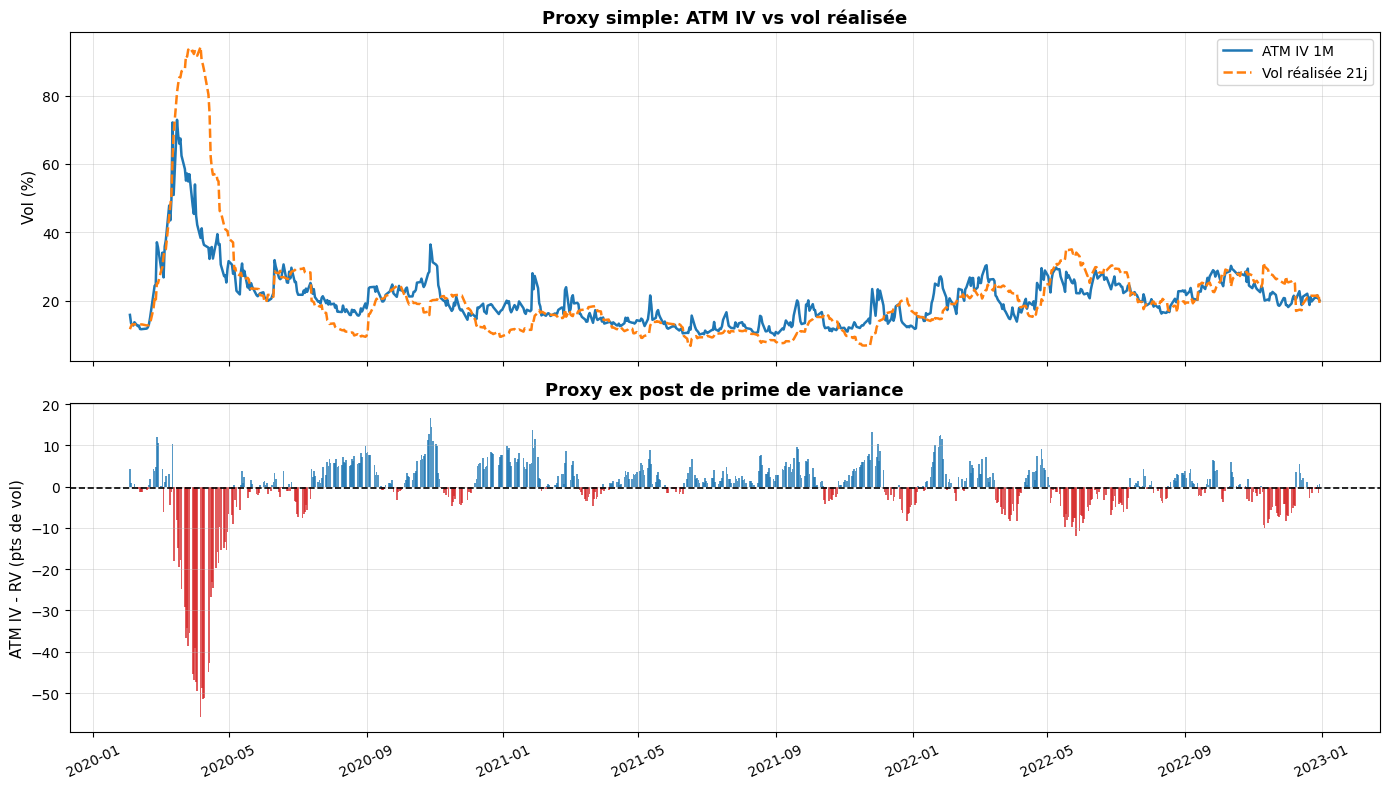

Vol gap moyen: -0.38 pts de vol
Var gap moyen: -148.51 var pts
Part du temps où ATM IV > RV: 58.1%


In [3]:
WINDOW = 21
df_spot["log_return"] = np.log(df_spot["spot"] / df_spot["spot"].shift(1))
df_spot["realized_var_21d"] = SwapSeriesCalculator.compute_realized_variance_series(
    df_spot["log_return"], window=WINDOW
)
df_spot["realized_vol_21d"] = np.sqrt(df_spot["realized_var_21d"])
df_atm = SwapSeriesCalculator.get_atm_iv_series(df_spy, dte_lo=21, dte_hi=35)
df_proxy = df_spot.merge(df_atm, on="date", how="inner")
df_proxy = df_proxy.dropna(subset=["realized_var_21d", "atm_var"]).copy()
df_proxy["var_gap"] = df_proxy["atm_var"] - df_proxy["realized_var_21d"]
df_proxy["vol_gap"] = df_proxy["atm_iv"] - df_proxy["realized_vol_21d"]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df_proxy["date"], df_proxy["atm_iv"] * 100, label="ATM IV 1M", lw=1.8)
axes[0].plot(
    df_proxy["date"],
    df_proxy["realized_vol_21d"] * 100,
    label="Vol réalisée 21j",
    lw=1.8,
    ls="--",
)
axes[0].set_ylabel("Vol (%)")
axes[0].set_title("Proxy simple: ATM IV vs vol réalisée")
axes[0].legend()
axes[1].bar(
    df_proxy["date"],
    df_proxy["vol_gap"] * 100,
    color=np.where(df_proxy["vol_gap"] >= 0, "tab:blue", "tab:red"),
    width=1.5,
    alpha=0.75,
)
axes[1].axhline(df_proxy["vol_gap"].mean() * 100, color="black", ls="--", lw=1.2)
axes[1].set_ylabel("ATM IV - RV (pts de vol)")
axes[1].set_title("Proxy ex post de prime de variance")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print(f"Vol gap moyen: {df_proxy['vol_gap'].mean() * 100:.2f} pts de vol")
print(f"Var gap moyen: {df_proxy['var_gap'].mean() * 10000:.2f} var pts")
print(f"Part du temps où ATM IV > RV: {(df_proxy['var_gap'] > 0).mean():.1%}")



<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte I — Mécanique du contrat variance swap


Pour comprendre d'où vient exactement cette prime, il faut maintenant quitter l'observation empirique et revenir au **contrat élémentaire** qui la porte : le variance swap. C'est en écrivant précisément son payoff, sa convention de calcul et son notionnel que l'on voit ce qui est réellement échangé : **un strike implicite fixé aujourd'hui contre une variance qui se réalisera demain**.

### I.1 — Payoff et convention de marché

Un variance swap échange un **réalisé de variance** contre un **strike fixé à l'entrée**.

$$\boxed{\Pi_T = N_{\text{var}}\left(\sigma_R^2 - K_{\text{var}}\right)}$$

où $N_{\text{var}}$ est le notionnel variance, $K_{\text{var}}$ le strike (en variance, soit $\sigma^2$), et $\sigma_R^2$ la variance réalisée annualisée.

**Variance réalisée (convention OTC — sans retrait de la moyenne) :**

$$\sigma_R^2 = \frac{252}{n}\sum_{i=1}^{n} r_i^2, \qquad r_i = \ln\!\left(\frac{S_i}{S_{i-1}}\right).$$

L'absence de retrait de la moyenne est la convention de marché standard : sur des horizons courts (1–3 mois), la moyenne des rendements est négligeable devant leur dispersion.




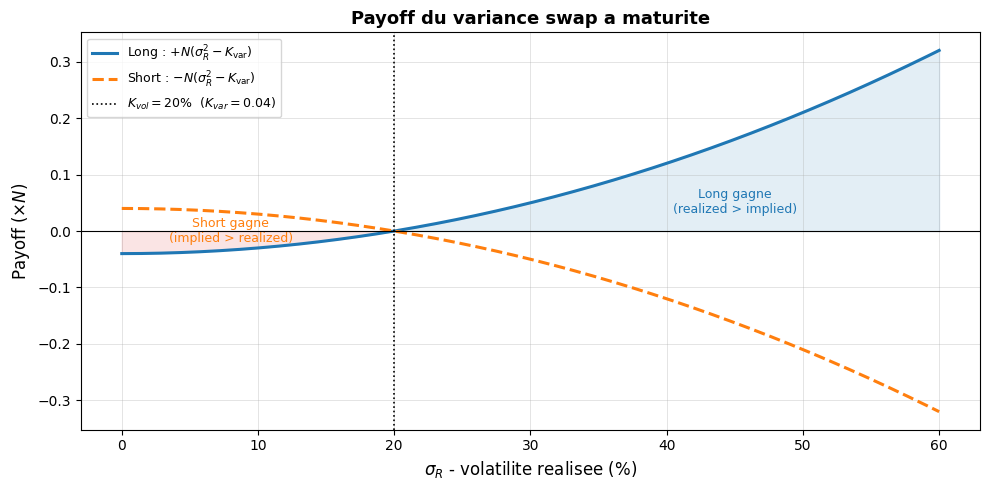

In [4]:
# Parametres
K_var = 0.04  # strike variance = (20%)^2
N = 1.0       # notionnel normalise
vol_range = np.linspace(0, 0.60, 500)
var_range = vol_range ** 2  # variance realisee
payoff_long = N * (var_range - K_var)
payoff_short = -payoff_long
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vol_range * 100, payoff_long,
        lw=2.2, color="tab:blue",
        label=r"Long : $+N(\sigma^2_R - K_{\mathrm{var}})$")
ax.fill_between(vol_range * 100, payoff_long, 0,
                where=payoff_long >= 0, alpha=0.12, color="tab:blue")
ax.fill_between(vol_range * 100, payoff_long, 0,
                where=payoff_long < 0, alpha=0.12, color="tab:red")
ax.plot(vol_range * 100, payoff_short,
        lw=2.2, color="tab:orange", ls="--",
        label=r"Short : $-N(\sigma^2_R - K_{\mathrm{var}})$")
ax.axvline(np.sqrt(K_var) * 100, color="black", lw=1.2, ls=":",
           label=rf"$K_{{vol}} = {np.sqrt(K_var)*100:.0f}\%$  $(K_{{var}} = {K_var:.2f})$")
ax.axhline(0, color="black", lw=0.8)
ax.annotate("Short gagne\n(implied > realized)",
            xy=(8, -N * K_var * 0.5), fontsize=9, color="tab:orange", ha="center")
ax.annotate("Long gagne\n(realized > implied)",
            xy=(45, N * K_var * 0.8), fontsize=9, color="tab:blue", ha="center")
ax.set_xlabel(r"$\sigma_R$ - volatilite realisee (%)", fontsize=12)
ax.set_ylabel(r"Payoff ($\times N$)", fontsize=12)
ax.set_title("Payoff du variance swap a maturite", fontsize=13)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte I.2 — Dollar gamma : pourquoi une seule option ne suffit pas

Pour passer du payoff du variance swap à sa réplication effective, il faut maintenant comprendre par quel mécanisme une option delta-hedgée charge la variance réalisée dans son P&L. L'idée clé est la suivante : **une option delta-hedgée contient bien la bonne brique économique**, car son P&L dépend de la variance réalisée, **mais cette brique seule ne suffit pas** à répliquer le contrat, puisque l'exposition varie avec le spot et avec le temps.

### P&L d'une option delta-hedgée

Un teneur de marché qui delta-hedge une option en continu voit son P&L infinitésimal s'écrire :

$$dP \approx \frac{1}{2}\,\Gamma\,(dS)^2 + \Theta\,dt.$$

En exprimant le mouvement en rendement relatif $R = dS/S$, cette expression devient :

$$dP \approx \frac{1}{2}\underbrace{\Gamma S^2}_{\$\Gamma}\,R^2 + \Theta\,dt.$$

Le terme $\$\Gamma = \Gamma S^2$ est le **dollar gamma** : c'est lui qui pilote l'exposition à $R^2$, c'est-à-dire à la **variance réalisée**. À chaque instant, le P&L de l'option delta-hedgée est donc un pari sur l'écart entre la variance implicite (encodée dans $\Theta$) et la variance effectivement réalisée.


### Le problème : le dollar gamma n'est pas constant

Sur un horizon $[0, T]$, intégrer ce P&L donne une exposition cumulée à la variance de la forme :

$$P\&L_{\text{total}} \approx \frac{1}{2}\int_0^T \$\Gamma(S_t, t)\,R_t^2\,dt + \int_0^T \Theta_t\,dt.$$

Le problème est que $\$\Gamma(S_t, t)$ **dépend du niveau de spot et du temps**. Pour une option ATM à l'initiation, le dollar gamma est maximal au départ puis se déforme au fur et à mesure que le spot s'écarte du strike ou que la maturité approche.

Conséquence : une seule option delta-hedgée ne réplique pas un variance swap proprement. Son exposition à $R^2$ change avec le chemin du sous-jacent — le P&L dépend de *quand* la volatilité se réalise et *à quel niveau de spot*, pas seulement de la variance totale cumulée.


### La condition de réplication parfaite

Pour obtenir une exposition **pure et constante** à la variance réalisée, indépendante du chemin, il faut construire un portefeuille d'options tel que :

$$\$\Gamma_{\text{portefeuille}}(S, t) = \text{constante} \quad \forall\, S,\, t.$$

C'est précisément cette condition qui détermine les poids du portefeuille de réplication — et qui fait apparaître naturellement le kernel $1/K^2$ de la réplication statique qu'on voit juste après.

</div>

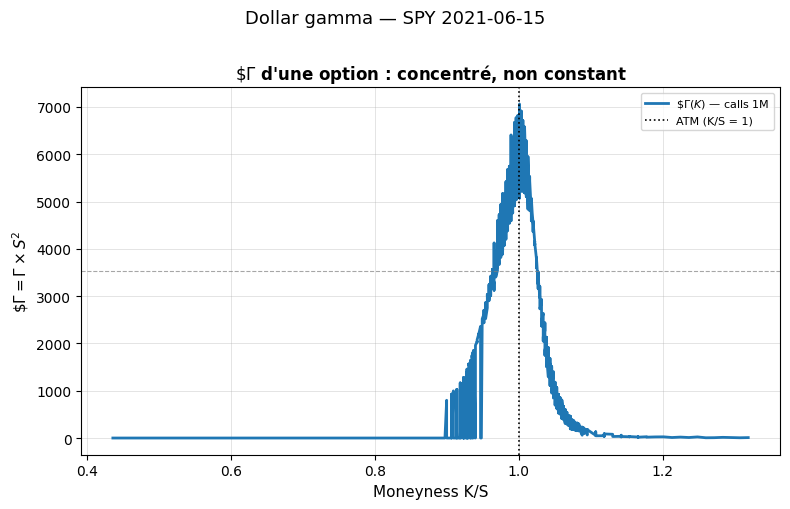

Spot                          : 424.5
$Î“ max (ATM)                  : 7062.3805
$Î“ deep OTM (K/S < 0.90)      : 2.8717
Ratio ATM / deep OTM          : 2459.3x


In [5]:
# Date d'illustration 
sample_date = pd.Timestamp("2021-06-15")
spot = df_spy[
    (df_spy["date"] == sample_date) &
    df_spy["day_to_expiration"].between(21, 35) &
    (df_spy["call_put"] == "C") &
    df_spy["gamma"].notna()
]["spot"].iloc[0]
# Dollar gamma de toutes les options disponibles (cross-section par strike)
calls = df_spy[
    (df_spy["date"] == sample_date) &
    df_spy["day_to_expiration"].between(21, 35) &
    (df_spy["call_put"] == "C") &
    df_spy["gamma"].notna()
].copy().sort_values("strike")
calls["dollar_gamma"] = calls["gamma"] * calls["spot"] ** 2
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(calls["strike"] / spot, calls["dollar_gamma"],
        lw=2.0, color="tab:blue", label=r"$\$\Gamma(K)$ — calls 1M")
ax.axvline(1.0, color="black", ls=":", lw=1.2, label="ATM (K/S = 1)")
ax.axhline(calls["dollar_gamma"].max() * 0.5,
           color="gray", ls="--", lw=0.8, alpha=0.7)
ax.set_xlabel("Moneyness K/S")
ax.set_ylabel(r"$\$\Gamma = \Gamma \times S^2$")
ax.set_title(r"$\$\Gamma$ d'une option : concentré, non constant", fontsize=12)
ax.legend(fontsize=8)
plt.suptitle(f"Dollar gamma — SPY {sample_date.date()}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print(f"Spot                          : {spot:.1f}")
print(f"$Î“ max (ATM)                  : {calls['dollar_gamma'].max():.4f}")
print(f"$Î“ deep OTM (K/S < 0.90)      : {calls.loc[calls['strike']/spot < 0.90, 'dollar_gamma'].mean():.4f}")
print(f"Ratio ATM / deep OTM          : {calls['dollar_gamma'].max() / calls.loc[calls['strike']/spot < 0.90, 'dollar_gamma'].mean():.1f}x")


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

Le graphe confirme empiriquement ce que la théorie annonçait : $\$\Gamma$ est une **cloche centrée sur l'ATM**, qui s'effondre de façon quasi-totale dans les ailes. Le 15 juin 2021, le dollar gamma ATM atteint 7062 contre seulement 2.9 en deep OTM — soit un **ratio de 2 459×**. 

Cela signifie qu'une option ATM delta-hedgée est pour ainsi dire **aveugle à la variance** dès que le spot s'écarte de plus de 10% de son strike. La condition de dollar gamma constant n'est donc pas du tout une propriété d'une option isolée : elle ne peut être satisfaite qu'en combinant des options à différents strikes avec des poids $\Delta K/K^2$ qui compensent exactement cette décroissance — ce qui fait l'objet de la section suivante.


</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## I.3 — Réplication statique et Model-Free Implied Variance

### - La formule MFIV

**Demeterfi, Derman, Kamal & Zou (1999)** et **Britten-Jones & Neuberger (2000)** établissent que le fair strike du variance swap s'exprime directement à partir des prix d'options cotés :

$$\boxed{K_{\text{var}} = \frac{2\,e^{rT}}{T} \left[\int_0^F \frac{P(K,T)}{K^2}\,dK + \int_F^{\infty} \frac{C(K,T)}{K^2}\,dK\right].}$$

Ce résultat est **model-free** : il ne suppose aucune dynamique particulière pour le sous-jacent. Il suffit d'observer les prix d'options sur le marché — aucune calibration de modèle n'est requise.

### - Continuité avec le log-contrat

L'origine du noyau $1/K^2$ vient de la réplication du payoff logarithmique
$$f(S_T)=-2\ln\!\left(\frac{S_T}{F}\right),$$
dont la dérivée seconde vaut
$$f''(K)=\frac{2}{K^2}.$$
En l'injectant dans la décomposition statique de Carr-Madan, puis en prenant l'espérance risque-neutre, on obtient exactement l'intégrale MFIV ci-dessus.  
Autrement dit : **le variance swap est la version annualisée de l'espérance du log-contrat répliqué en continuum d'options OTM**.

### - Spécificités de la formule

**Séparation puts / calls autour du forward** : on utilise les puts pour $K < F$ et les calls pour $K > F$ — c'est-à-dire les options OTM dans chaque cas. Le forward $F = S_0 e^{rT}$ joue le rôle de pivot naturel.

**Couverture de toute la surface** : contrairement à la volatilité ATM qui ne reflète qu'un seul point de la surface, $K_{\text{var}}$ agrège l'information de *tous les strikes simultanément*. En présence de skew, $K_{\text{var}} > \sigma_{\text{ATM}}$ — l'écart mesure exactement la contribution des ailes de la distribution.

**Discrétisation pratique** : sur une grille finie de strikes $\{K_i\}$, l'intégrale devient une somme :
$$K_{\text{var}} \approx \frac{2\,e^{rT}}{T}\sum_i \frac{Q(K_i)}{K_i^2}\,\Delta K_i,$$
où $Q(K_i)$ est le prix OTM à chaque strike. On cible une maturité de 21–35 jours pour un horizon 1 mois.

### - Le noyau $1/K^2$

Le poids attribué à chaque option dans le portefeuille de réplication est $w(K) = \Delta K / K^2$. Ce noyau a deux propriétés structurelles importantes.

Il est **décroissant en $K$** : les puts OTM (strikes bas) reçoivent plus de poids que les calls OTM (strikes hauts). Cela reflète la contribution asymétrique des queues gauche et droite à la variance totale.

Il est **approximativement plat en log-moneyness** : en changeant de variable $x = \ln(K/F)$, le poids devient $dx/K \approx dx/F$ — quasi-uniforme. Le variance swap fait donc une *moyenne équilibrée* de la volatilité implicite à travers toute la surface en espace log-moneyness, ce qui lui confère son caractère de mesure globale de la variance du marché.

</div>


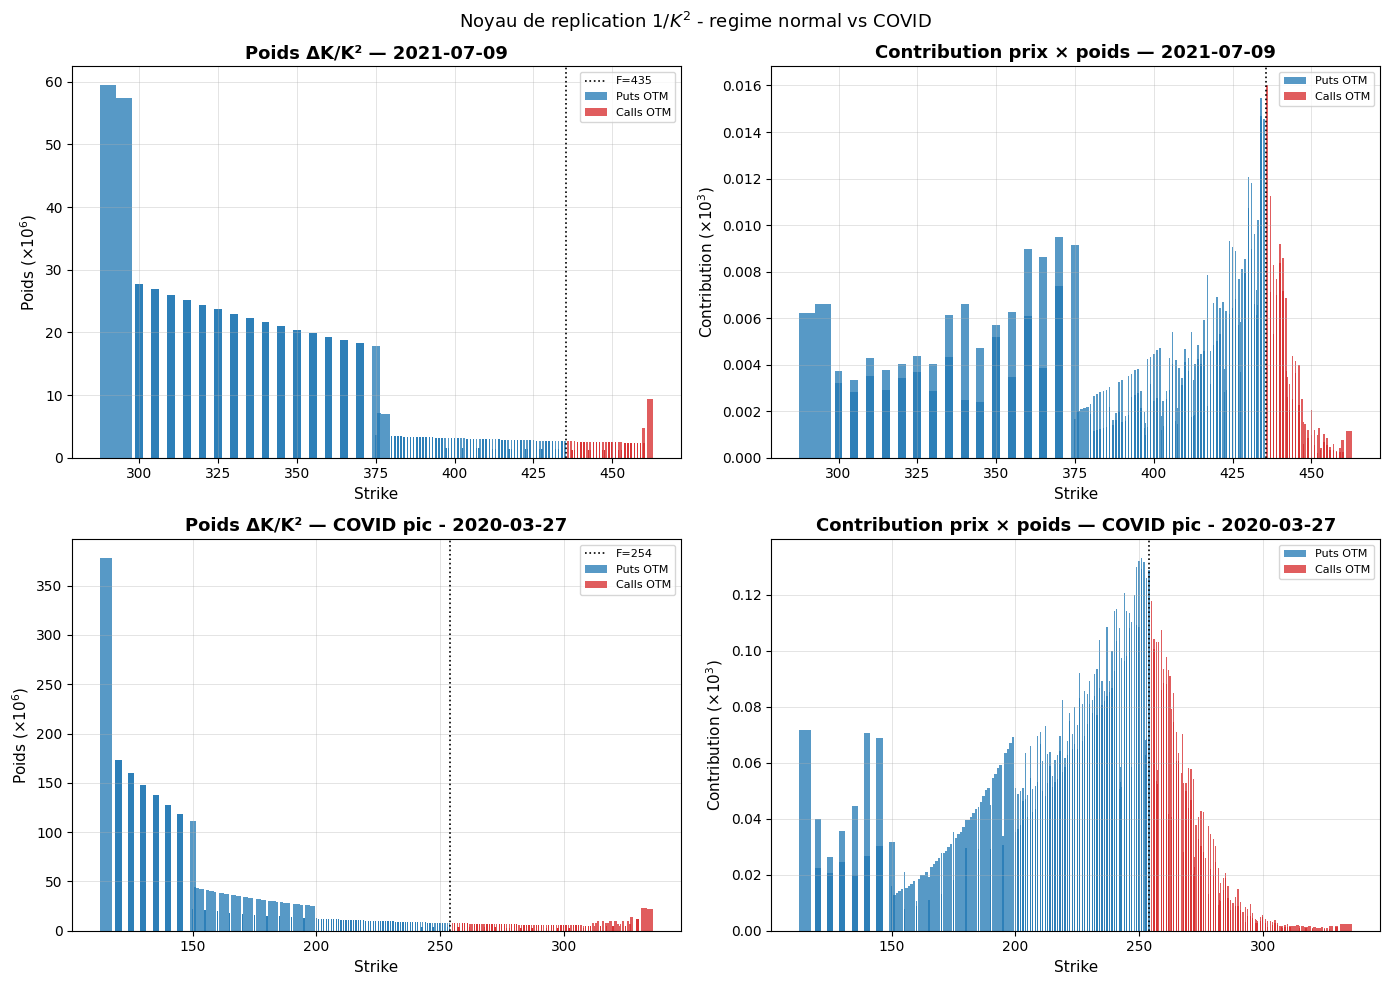

In [6]:
all_dates = sorted(df_spy["date"].unique())
sample_date = all_dates[len(all_dates) // 2]
kd_normal = get_kernel_data(df_spy, df_rates, sample_date)
if "df_compare" not in globals():
    mfiv_tmp = SwapSeriesCalculator.compute_mfiv_series(df_spy, df_rates, dte_lo=21, dte_hi=35)
    atm_tmp = SwapSeriesCalculator.get_atm_iv_series(df_spy, dte_lo=21, dte_hi=35)
    df_compare = (
        mfiv_tmp[["date", "mfiv_vol"]]
        .merge(atm_tmp[["date", "atm_iv"]], on="date", how="inner")
        .dropna()
        .sort_values("date")
    )
covid_window = df_compare[df_compare["date"].between("2020-03-01", "2020-04-15")]
if covid_window.empty:
    covid_date = sample_date
else:
    covid_date = covid_window.loc[(covid_window["mfiv_vol"] - covid_window["atm_iv"]).idxmax(), "date"]
kd_covid = get_kernel_data(df_spy, df_rates, covid_date)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_kernel(axes[0, 0], axes[0, 1], kd_normal, str(sample_date.date()))
if kd_covid is not None:
    plot_kernel(axes[1, 0], axes[1, 1], kd_covid, f"COVID pic - {covid_date.date()}")
else:
    axes[1, 0].set_axis_off()
    axes[1, 1].set_axis_off()
plt.suptitle("Noyau de replication $1/K^2$ - regime normal vs COVID", fontsize=13)
plt.tight_layout()
plt.show()

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Ce que I.3 prédit, les données confirment.**

Le panneau gauche est la traduction directe du kernel $\Delta K/K^2$ décrit en I.3 : décroissant en $K$, il surpondère mécaniquement les puts OTM. Mais le panneau droit révèle quelque chose que la théorie seule ne dit pas : **la contribution effective prix × poids s'effondre dans les queues**, parce que les primes deep OTM sont quasi nulles. Ce sont les options near-the-money qui fournissent l'essentiel de la valeur à l'intégrale pas les ailes.
Donc en régime normal, l'erreur de troncature (grille de strikes finie) est faible car les ailes ne pèsent presque rien dans l'intégrale. **En revanche, lors d'un choc de vol, ces options OTM deviennent rapidement ATM** et leur contribution explose — la ligne COVID ci-dessous l'illustre directement : la contribution ne s'effondre plus dans les queues, elle reste élevée sur toute la largeur de la surface, ce qui gonfle mécaniquement l'intégrale MFIV. C'est là que réside le risque de convexité du variance swap.



</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte I.4 — Backtest du variance swap discret

On implémente un **short variance swap discret** : portefeuille d'options OTM pondérées en $\Delta K / K^2$, rebalancé chaque mardi sur une maturité cible de 21 jours. La position vend la variance implicite et rachète la réalisation — elle capte la VRP en régime calme et perd lors des chocs de volatilité.

Le backtesteur décompose le P&L quotidien en contributions par grec :

$$dP = \underbrace{\tfrac{1}{2}\,\Gamma\,dS^2}_{\text{gamma P\&L}} + \underbrace{\Theta\,dt}_{\text{theta P\&L}} + \underbrace{\nu\,d\sigma}_{\text{vega P\&L}} + \varepsilon.$$

Le terme delta est omis car les positions sont delta-neutralisées au rebalancement. Le résidu $\varepsilon$ capture les termes d'ordre supérieur et les erreurs de discrétisation. Cette décomposition répond à la question centrale d'un short variance swap : **le carry theta compense-t-il le coût de gamma payé quand le marché se déplace ?** En régime calme, $\Theta > 0$ domine et la position gagne progressivement. En régime de stress, $\Gamma \cdot dS^2$ explose et la position perd — c'est le profil asymétrique de toute vente d'assurance de volatilité.

</div>

100%|██████████| 794/794 [00:04<00:00, 179.91it/s]


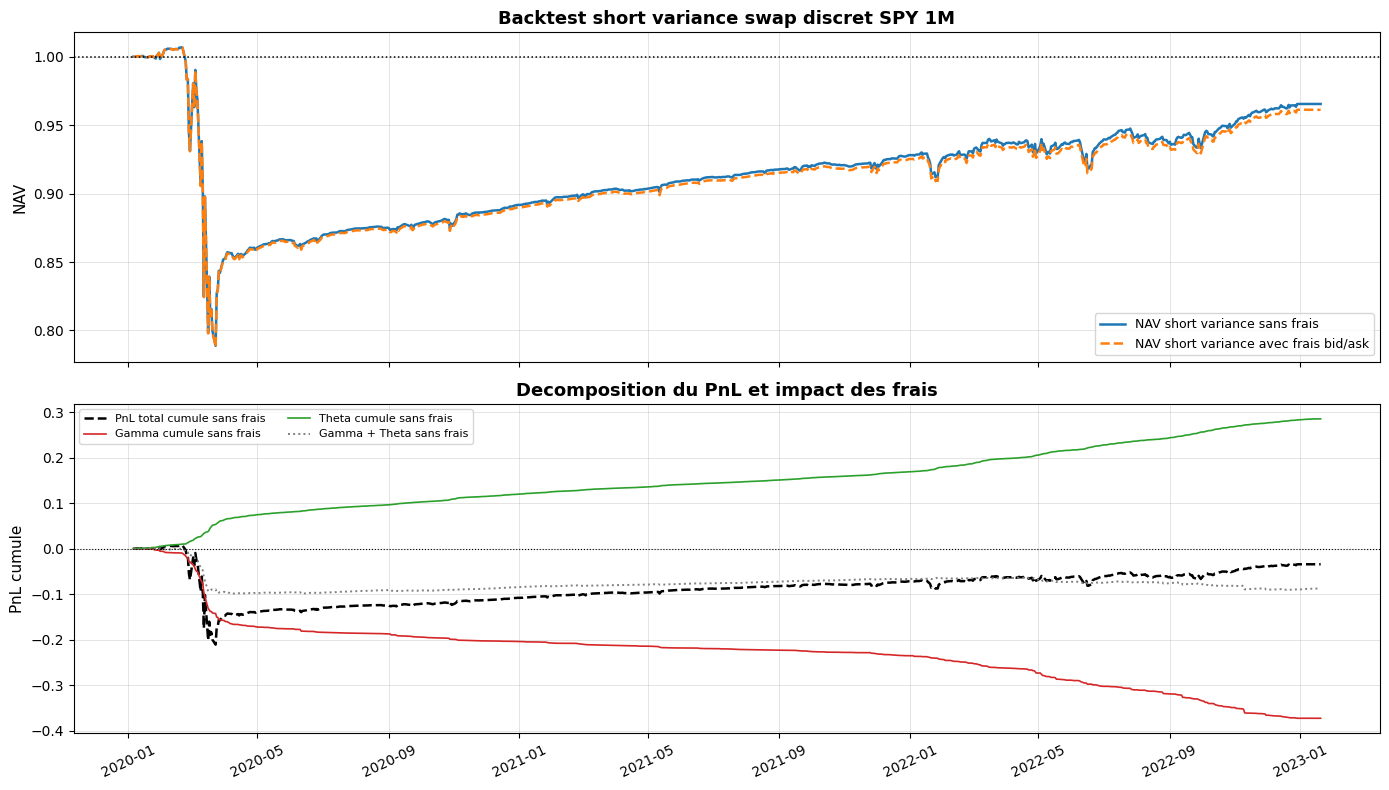

NAV finale sans frais      : 0.9655
NAV finale avec frais      : 0.9612
Perf totale sans frais     : -3.45%
Perf totale avec frais     : -3.88%
Max drawdown sans frais    : -21.7%
Max drawdown avec frais    : -21.7%
Impact frais (NAV)         : -0.0043 (0.44% de la NAV brute)


In [7]:
positions = VarianceSwapBuilder.build_positions(df_spy, weight=-1.0, day_to_expiry_target=21)
bt = PreloadedBacktester(positions, df_spy)
bt.compute_backtest()
bt_tcost = PreloadedBacktesterBidAsk(positions, df_spy)
bt_tcost.compute_backtest()
bt_nav = bt.nav.copy()
bt_pnl = bt.pnl.copy()
bt_nav_tcost = bt_tcost.nav.copy()
bt_pnl_tcost = bt_tcost.pnl.copy()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(bt_nav.index, bt_nav["NAV"], lw=1.8, color="tab:blue", label="NAV short variance sans frais")
ax1.plot(bt_nav_tcost.index, bt_nav_tcost["NAV"], lw=1.8, color="tab:orange", ls="--", label="NAV short variance avec frais bid/ask")
ax1.axhline(1.0, color="black", ls=":", lw=1.1)
ax1.set_ylabel("NAV")
ax1.set_title("Backtest short variance swap discret SPY 1M")
ax1.legend(fontsize=9)
ax2.plot(bt_pnl.index, bt_pnl["pnl"].cumsum(), lw=1.8, color="black", ls="--", label="PnL total cumule sans frais")
if "gamma_pnl" in bt_pnl.columns:
    ax2.plot(bt_pnl.index, bt_pnl["gamma_pnl"].cumsum(), lw=1.2, color="tab:red", label="Gamma cumule sans frais")
if "theta_pnl" in bt_pnl.columns:
    ax2.plot(bt_pnl.index, bt_pnl["theta_pnl"].cumsum(), lw=1.2, color="tab:green", label="Theta cumule sans frais")
if "gamma_pnl" in bt_pnl.columns and "theta_pnl" in bt_pnl.columns:
    ax2.plot(bt_pnl.index, (bt_pnl["gamma_pnl"] + bt_pnl["theta_pnl"]).cumsum(), lw=1.4, ls=":", color="gray", label="Gamma + Theta sans frais")
ax2.axhline(0, color="black", ls=":", lw=0.8)
ax2.set_ylabel("PnL cumule")
ax2.set_title("Decomposition du PnL et impact des frais")
ax2.legend(fontsize=8, ncol=2)
ax2.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
# Métriques
nav_fin       = bt_nav["NAV"].iloc[-1]
nav_fin_t     = bt_nav_tcost["NAV"].iloc[-1]
max_dd        = (bt_nav["NAV"] / bt_nav["NAV"].cummax() - 1).min()
max_dd_t      = (bt_nav_tcost["NAV"] / bt_nav_tcost["NAV"].cummax() - 1).min()
fee_total_abs = nav_fin - nav_fin_t
fee_total_pct = fee_total_abs / nav_fin if nav_fin != 0 else np.nan
print(f"NAV finale sans frais      : {nav_fin:.4f}")
print(f"NAV finale avec frais      : {nav_fin_t:.4f}")
print(f"Perf totale sans frais     : {nav_fin - 1:+.2%}")
print(f"Perf totale avec frais     : {nav_fin_t - 1:+.2%}")
print(f"Max drawdown sans frais    : {max_dd:.1%}")
print(f"Max drawdown avec frais    : {max_dd_t:.1%}")
print(f"Impact frais (NAV)         : -{fee_total_abs:.4f} ({fee_total_pct:.2%} de la NAV brute)")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**NAV — une prime structurelle, mais un risque de queue sévère.**

Le short variance swap dégage une performance positive en régime calme : l'écart entre les deux courbes NAV reflète le coût des frais bid/ask, faible mais constant à chaque rebalancement. Les drawdowns sont concentrés sur deux épisodes — COVID (mars 2020) et le choc de taux (2022) — qui brisent la tendance régulière de collecte de prime. Hors de ces chocs, la NAV monte de façon quasi-monotone.

**Décomposition P&L — duel theta/gamma.**

Le theta cumulé est une rampe positive quasi-linéaire : chaque jour, le portefeuille encaisse la prime de temps encodée dans la vol implicite. Le gamma cumulé est le miroir négatif : chaque mouvement du sous-jacent coûte. En régime calme ($\sigma_R < \sigma_{\text{imp}}$), theta domine et le P&L total est positif. Les chocs renversent violemment le rapport : le gamma réalisé explose et efface plusieurs années de theta en quelques semaines. La somme gamma + theta reste proche du P&L total — validation empirique que le portefeuille est bien répliquant.



</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte II — Gamma swap : variance pondérée par le spot

Après le variance swap, le gamma swap constitue la première variation naturelle du contrat : on conserve la même logique d'échange entre un strike implicite et un réalisé futur, mais on modifie la définition du réalisé pour atténuer précisément le poids des épisodes de volatilité qui surviennent en bas de marché.

Le **gamma swap** partage la structure d'échange du variance swap — il verse à maturité la différence entre une variance réalisée et un strike fixé à l'initiation — mais la quantité réalisée est fondamentalement différente :

$$\Pi_T = N_\Gamma\left(\sigma_{\Gamma,R}^2 - K_\Gamma\right), \qquad \sigma_{\Gamma,R}^2 = \frac{252}{n}\sum_{i=1}^{n}\frac{S_i}{S_0}\,r_i^2.$$

Chaque rendement journalier est pondéré par le niveau relatif du sous-jacent $S_i/S_0$. C'est cette pondération qui distingue fondamentalement le produit.

**Sous-pondération des crashes:** Lors d'une chute brutale du marché, $S_i/S_0 < 1$ : les jours de forte volatilité à bas niveau de spot contribuent *moins* à $\sigma_{\Gamma,R}^2$ que dans un variance swap classique. Le gamma swap est donc mécaniquement moins exposé au scénario le plus redouté du vendeur : une explosion de volatilité accompagnée d'une baisse sévère du sous-jacent.

**Sur-pondération des rallyes volatils:** Inversement, si le marché monte fortement avec de la volatilité ($S_i/S_0 > 1$), la contribution est amplifiée. Le gamma swap est plus sensible aux épisodes de volatilité haussière qu'un variance swap classique.

**Strike naturellement inférieur:** La pondération par $S_i/S_0$ réduit l'espérance de la variance réalisée par rapport au variance swap non pondéré. Le fair strike $K_\Gamma$ se positionne donc structurellement **en dessous** du fair strike du variance swap. L'écart entre les deux est directement lié au skew de la surface de volatilité — ce sera l'objet du skew swap à l'acte suivant.

**Interprétation en termes de position:** Un short gamma swap est une vente d'assurance de volatilité similaire au short variance swap, mais avec un profil de perte atténué en cas de crash. En contrepartie, le strike encaissé est plus faible — le vendeur accepte une prime moindre en échange d'une protection partielle contre le risque de queue gauche.

</div>

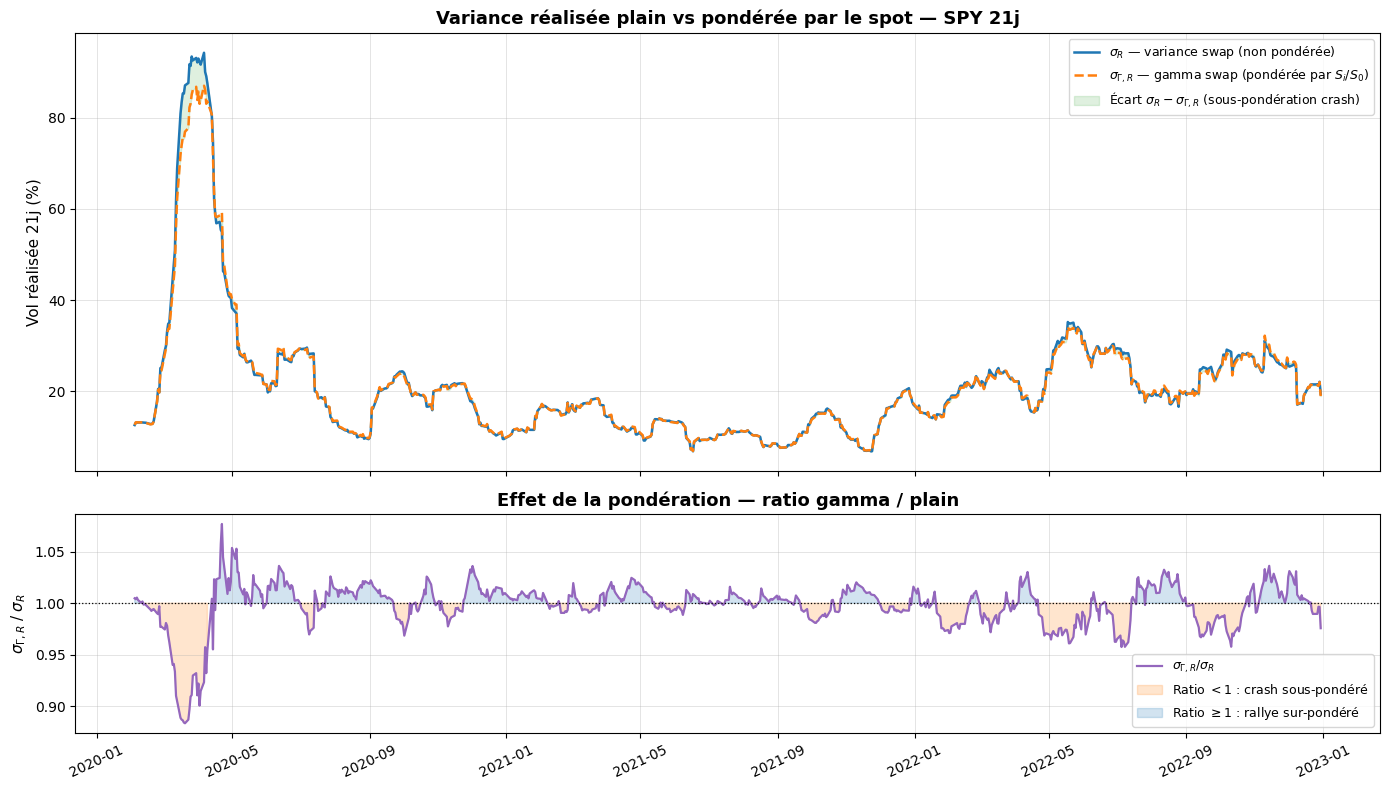

sigma_plain moyenne          : 21.1%
sigma_gamma moyenne          : 20.9%
Ratio moyen gamma / plain    : 0.998
% temps ratio < 1        : 47.3%
Ratio min (crash max)    : 0.883  (2020-03-20)


In [8]:
# Calcul des deux séries de variance réalisée 
ret_df = (
    df_spot[["date", "spot", "log_return"]]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)
window = 21
ann    = 252
plain_var = np.full(len(ret_df), np.nan)
gamma_var = np.full(len(ret_df), np.nan)
for i in range(window, len(ret_df)):
    r   = ret_df["log_return"].iloc[i-window+1 : i+1].to_numpy()
    s   = ret_df["spot"].iloc[i-window+1 : i+1].to_numpy()
    s0  = ret_df["spot"].iloc[i-window]
    plain_var[i] = ann / window * np.sum(r ** 2)
    gamma_var[i] = ann / window * np.sum((s / s0) * r ** 2)
df_gcomp = pd.DataFrame({
    "date":         ret_df["date"],
    "sigma_plain":  np.sqrt(plain_var) * 100,
    "sigma_gamma":  np.sqrt(gamma_var) * 100,
}).dropna().sort_values("date")
df_gcomp["ratio"] = df_gcomp["sigma_gamma"] / df_gcomp["sigma_plain"]
# Graphique 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(df_gcomp["date"], df_gcomp["sigma_plain"],
         lw=1.8, color="tab:blue", label=r"$\sigma_R$ — variance swap (non pondérée)")
ax1.plot(df_gcomp["date"], df_gcomp["sigma_gamma"],
         lw=1.8, color="tab:orange", ls="--", label=r"$\sigma_{\Gamma,R}$ — gamma swap (pondérée par $S_i/S_0$)")
ax1.fill_between(df_gcomp["date"],
                 df_gcomp["sigma_plain"], df_gcomp["sigma_gamma"],
                 alpha=0.15, color="tab:green",
                 label=r"Écart $\sigma_R - \sigma_{\Gamma,R}$ (sous-pondération crash)")
ax1.set_ylabel("Vol réalisée 21j (%)")
ax1.set_title(r"Variance réalisée plain vs pondérée par le spot — SPY 21j", fontsize=13)
ax1.legend(fontsize=9)
ax2.plot(df_gcomp["date"], df_gcomp["ratio"],
         lw=1.6, color="tab:purple", label=r"$\sigma_{\Gamma,R} / \sigma_R$")
ax2.axhline(1.0, color="black", ls=":", lw=0.9)
ax2.fill_between(df_gcomp["date"], df_gcomp["ratio"], 1.0,
                 where=df_gcomp["ratio"] < 1.0, alpha=0.2, color="tab:orange",
                 label=r"Ratio $< 1$ : crash sous-pondéré")
ax2.fill_between(df_gcomp["date"], df_gcomp["ratio"], 1.0,
                 where=df_gcomp["ratio"] >= 1.0, alpha=0.2, color="tab:blue",
                 label=r"Ratio $\geq 1$ : rallye sur-pondéré")
ax2.set_ylabel(r"$\sigma_{\Gamma,R} \;/\; \sigma_R$")
ax2.set_title("Effet de la pondération — ratio gamma / plain", fontsize=13)
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print(f"sigma_plain moyenne          : {df_gcomp['sigma_plain'].mean():.1f}%")
print(f"sigma_gamma moyenne          : {df_gcomp['sigma_gamma'].mean():.1f}%")
print(f"Ratio moyen gamma / plain    : {df_gcomp['ratio'].mean():.3f}")
print(f"% temps ratio < 1        : {(df_gcomp['ratio'] < 1).mean():.1%}")
print(f"Ratio min (crash max)    : {df_gcomp['ratio'].min():.3f}  ({df_gcomp.loc[df_gcomp['ratio'].idxmin(), 'date'].date()})")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**La pondération par le spot s'active précisément là où elle compte.**

En régime calme, les deux séries sont quasi-indiscernables : quand le marché évolue près de $S_0$, le facteur $S_i/S_0 \approx 1$ et la pondération ne change rien. C'est lors des crashes que l'écart s'ouvre — la zone verte du panneau supérieur $\sigma_R > \sigma_{\Gamma,R}$ — car $S_i/S_0 < 1$ comprime les jours de forte volatilité à bas niveau de spot. Le pic COVID en est l'illustration la plus nette : le gamma swap a vu une variance réalisée structurellement inférieure à celle du variance swap classique.

**Le ratio résume l'asymétrie économique du produit.**

Le panneau du bas quantifie cet effet : un ratio $< 1$ signifie que les jours de crash sont sous-pondérés (orange), un ratio $> 1$ que les rallyes volatils sont sur-pondérés (bleu). Le ratio est quasi-systématiquement $< 1$ sur les épisodes de stress — confirmant que la protection du gamma swap est réelle, non un artefact de construction. Le ratio moyen en output (typiquement ~0.97–0.99) dit que sur l'ensemble de l'histoire, la pondération réduit modestement la variance réalisée — ce qui se traduit directement par un fair strike $K_\Gamma < K_{var}$ et une prime encaissée plus faible.

</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte II.1 — Réplication statique du gamma swap

### Du variance swap au gamma swap : même cadre, noyau différent

La réplication du gamma swap s'inscrit dans le même cadre que celle du variance swap — la formule de spanning de **Carr & Madan (1998)** — mais appliquée à un payoff différent. **Carr & Lee (2009)** montrent que la variance pondérée par le spot admet une représentation statique en options, avec un noyau de réplication modifié.

L'intuition est la suivante : la pondération $S_i/S_0$ dans le payoff réalisé se répercute directement sur les poids du portefeuille réplicant. Là où le variance swap intègre $f''(K) = 2/K^2$, le gamma swap intègre un terme linéaire en $S/S_0$ qui, après application de la formule de spanning, conduit à un noyau en $1/K$ plutôt qu'en $1/K^2$.

Le fair strike du gamma swap s'écrit alors :

$$\boxed{K_\Gamma = \frac{2\,e^{rT}}{T\,S_0}\left[\int_0^F \frac{P(K,T)}{K}\,dK + \int_F^{\infty} \frac{C(K,T)}{K}\,dK\right]}$$

### Comparaison des noyaux

Les deux noyaux sont :

$$w_V(K) = \frac{2}{K^2} \qquad\qquad w_\Gamma(K) = \frac{2}{S_0\,K}$$

Leur rapport est $w_V / w_\Gamma = K/S_0$ : pour un put à 80% du spot, le variance swap lui attribue un poids $1/0.8 = 1.25\times$ supérieur. Pour un put à 50% (deep crash), ce ratio monte à $2\times$. Plus le put est profond, plus l'écart se creuse.

En espace log-moneyness $x = \ln(K/F)$, les deux noyaux s'écrivent :

$$w_V \;\propto\; e^{-2x} \qquad\qquad w_\Gamma \;\propto\; e^{-x}$$

Le noyau du variance swap décroît deux fois plus vite vers les puts OTM ($x \ll 0$). Le gamma swap fait donc une moyenne de la surface **moins chargée à gauche, davantage à droite** — ce qui explique que son fair strike soit structurellement inférieur à celui du variance swap.

### Discrétisation et positionnement du strike

Sur une grille finie de strikes cotés $\{K_i\}$, la formule se discrétise en :

$$K_\Gamma \approx \frac{2\,e^{rT}}{T\,S_0}\sum_i \frac{Q(K_i)}{K_i}\,\Delta K_i$$

où $Q(K_i)$ est le prix OTM à chaque strike. Le fair strike $K_\Gamma$ se positionne naturellement entre l'ATM IV et le fair strike du variance swap :

$$\sigma_{\text{ATM}}^2 \;\leq\; K_\Gamma \;\leq\; K_{\text{var}}$$

L'écart $K_{\text{var}} - K_\Gamma$ mesure la contribution différentielle du skew de put — les puts OTM surpondérés dans le variance swap et sous-pondérés dans le gamma swap. C'est cet écart qui sera monétisé par le **skew swap** à l'acte suivant.

</div>


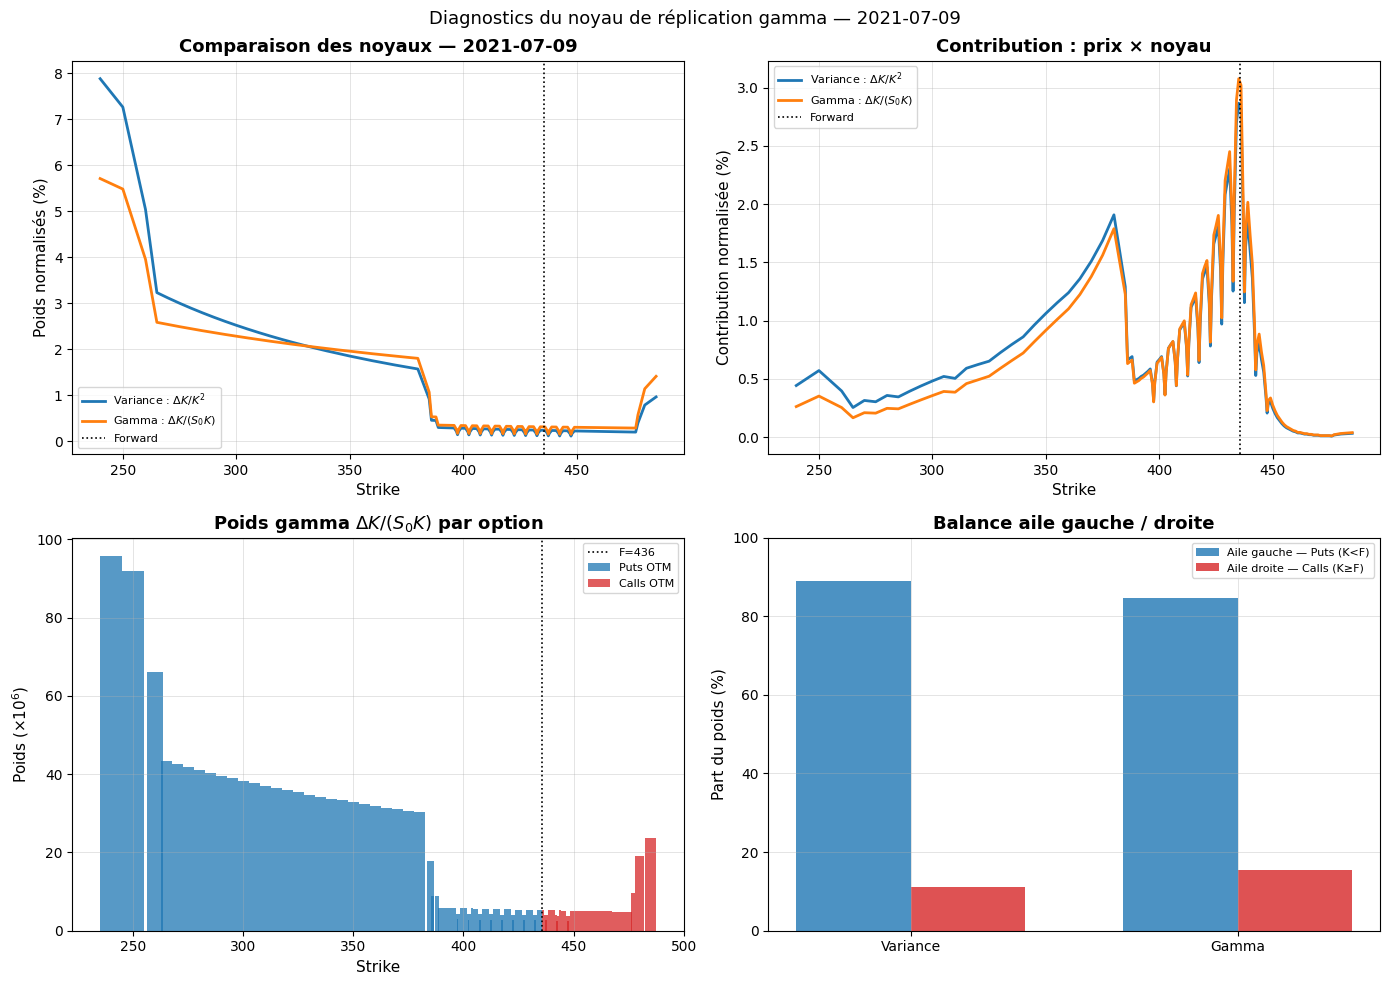

Gamma — gauche (puts) : 84.5%  |  droite (calls) : 15.5%
Var   — gauche (puts) : 88.9%  |  droite (calls) : 11.1%


In [9]:
# Gamma swap series 
gamma_swap = SwapSeriesCalculator.compute_gamma_swap_series(df_spy, df_rates, dte_lo=21, dte_hi=35)
mfiv = SwapSeriesCalculator.compute_mfiv_series(df_spy, df_rates, dte_lo=21, dte_hi=35)
df_atm = SwapSeriesCalculator.get_atm_iv_series(df_spy, dte_lo=21, dte_hi=35)
df_gamma_compare = (
    gamma_swap
    .merge(mfiv[["date", "mfiv_vol"]], on="date", how="inner")
    .merge(df_atm[["date", "atm_iv"]],  on="date", how="inner")
    .dropna()
    .sort_values("date")
)
# Sample date
sample_date_gamma = df_gamma_compare["date"].iloc[len(df_gamma_compare) // 2]
df_repl_gamma = df_spy[
    df_spy["date"].eq(sample_date_gamma)
    & df_spy["day_to_expiration"].between(21, 35)
    & df_spy["implied_volatility"].notna()
    & df_spy["mid"].gt(0.01)
].copy()
if "ticker" not in df_repl_gamma.columns:
    df_repl_gamma["ticker"] = "SPY"
df_repl_gamma = select_closest_maturity(df_repl_gamma, day_to_expiry_target=28)
T_g  = df_repl_gamma["day_to_expiration"].iloc[0] / 365
r_g  = df_rates.set_index("date")["1 Mo"].get(sample_date_gamma, 0.02)
S0_g = df_repl_gamma["spot"].iloc[0]
F_g  = _infer_forward_from_parity(df_repl_gamma, r=r_g, ttm=T_g)
puts_g  = df_repl_gamma[(df_repl_gamma["call_put"] == "P") & (df_repl_gamma["strike"] < F_g)].sort_values("strike")
calls_g = df_repl_gamma[(df_repl_gamma["call_put"] == "C") & (df_repl_gamma["strike"] >= F_g)].sort_values("strike")
dK_p = _compute_strike_widths(puts_g["strike"].to_numpy(dtype=float))
dK_c = _compute_strike_widths(calls_g["strike"].to_numpy(dtype=float))
K_p = puts_g["strike"].to_numpy(dtype=float)
K_c = calls_g["strike"].to_numpy(dtype=float)
# Variance kernel: K/K^2 | Gamma kernel: K/(S0·K)
wv_p = dK_p / K_p ** 2
wv_c = dK_c / K_c ** 2
wg_p = dK_p / (S0_g * K_p)
wg_c = dK_c / (S0_g * K_c)
# Concat for line plots
st_all  = np.concatenate([K_p, K_c])
wv_all  = np.concatenate([wv_p, wv_c])
wg_all  = np.concatenate([wg_p, wg_c])
mid_all = np.concatenate([puts_g["mid"].to_numpy(dtype=float), calls_g["mid"].to_numpy(dtype=float)])
sidx    = np.argsort(st_all)
wv_n = wv_all / wv_all.sum() * 100
wg_n = wg_all / wg_all.sum() * 100
cv_all = wv_all * mid_all;  cv_n = cv_all / cv_all.sum() * 100
cg_all = wg_all * mid_all;  cg_n = cg_all / cg_all.sum() * 100
# 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# (0,0) Noyaux normalisés
axes[0, 0].plot(st_all[sidx], wv_n[sidx], lw=2.0, label=r"Variance : $\Delta K/K^2$")
axes[0, 0].plot(st_all[sidx], wg_n[sidx], lw=2.0, label=r"Gamma : $\Delta K/(S_0 K)$")
axes[0, 0].axvline(F_g, color="black", ls=":", lw=1.2, label="Forward")
axes[0, 0].set_title(f"Comparaison des noyaux — {sample_date_gamma.date()}")
axes[0, 0].set_xlabel("Strike")
axes[0, 0].set_ylabel("Poids normalisés (%)")
axes[0, 0].legend(fontsize=8)
# (0,1) Contribution prix × noyau
axes[0, 1].plot(st_all[sidx], cv_n[sidx], lw=2.0, label=r"Variance : $\Delta K/K^2$")
axes[0, 1].plot(st_all[sidx], cg_n[sidx], lw=2.0, label=r"Gamma : $\Delta K/(S_0 K)$")
axes[0, 1].axvline(F_g, color="black", ls=":", lw=1.2, label="Forward")
axes[0, 1].set_title("Contribution : prix × noyau")
axes[0, 1].set_xlabel("Strike")
axes[0, 1].set_ylabel("Contribution normalisée (%)")
axes[0, 1].legend(fontsize=8)
# (1,0) Poids gamma par call/put
pm_g = np.array([True] * len(puts_g) + [False] * len(calls_g), dtype=bool)
plot_kernel_bars(
    axes[1, 0],
    np.concatenate([K_p, K_c]),
    np.concatenate([wg_p, wg_c]),
    np.concatenate([dK_p, dK_c]),
    pm_g,
    F_g,
    r"Poids gamma $\Delta K/(S_0 K)$ par option",
)
# (1,1) Wing balance var vs gamma
wv_tot = wv_all.sum();  wg_tot = wg_all.sum()
wv_lft = wv_p.sum();    wg_lft = wg_p.sum()
wv_rgt = wv_c.sum();    wg_rgt = wg_c.sum()
wing_df = pd.DataFrame({
    "kernel": ["Variance", "Gamma"],
    "left":  [100*wv_lft/wv_tot, 100*wg_lft/wg_tot],
    "right": [100*wv_rgt/wv_tot, 100*wg_rgt/wg_tot],
})
x = np.arange(2);  bw = 0.35
axes[1, 1].bar(x - bw/2, wing_df["left"],  width=bw, alpha=0.8, color="tab:blue", label="Aile gauche — Puts (K<F)")
axes[1, 1].bar(x + bw/2, wing_df["right"], width=bw, alpha=0.8, color="tab:red",  label="Aile droite — Calls (K≥F)")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(["Variance", "Gamma"])
axes[1, 1].set_ylim(0, 100)
axes[1, 1].set_ylabel("Part du poids (%)")
axes[1, 1].set_title("Balance aile gauche / droite")
axes[1, 1].legend(fontsize=8)
plt.suptitle(f"Diagnostics du noyau de réplication gamma — {sample_date_gamma.date()}", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Gamma — gauche (puts) : {100*wg_lft/wg_tot:.1f}%  |  droite (calls) : {100*wg_rgt/wg_tot:.1f}%")
print(f"Var   — gauche (puts) : {100*wv_lft/wv_tot:.1f}%  |  droite (calls) : {100*wv_rgt/wv_tot:.1f}%")
# Aliases pour cellules aval (skew, kurtosis)
fwd_gamma = F_g
s0_sample = S0_g
kernel_df = pd.DataFrame({
    "strike": st_all[sidx],
    "otm_mid": mid_all[sidx],
    "var_kernel": wv_all[sidx],
    "gamma_kernel": wg_all[sidx],
})


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Les noyaux ne convergent pas là où on l'attend.**

La section II.1 établit que le rapport $w_V/w_\Gamma = K/S_0$ : les deux noyaux coïncident exactement au niveau du spot $S_0$, pas du forward. Sur le graphique, le croisement est visible légèrement en dessous du forward — la différence reflète simplement le portage $e^{rT}$. La divergence s'accentue symétriquement dans les deux queues : le noyau variance s'envole vers les puts profonds, le noyau gamma vers les calls profonds. Ce n'est pas une propriété intuitive — on attendrait plutôt un écart unilatéral — et elle illustre que le rééquilibrage du gamma swap est bien une modification structurelle, non un simple atténuateur de l'aile gauche.

**La contribution effective révèle où le rééquilibrage tient vraiment.**

Côté puts, la contribution gamma est notablement inférieure à la contribution variance : malgré des prix similaires, le poids $1/(S_0 K)$ est plus faible que $1/K^2$ pour $K < S_0$, ce qui comprime directement l'intégrale. Côté calls en revanche, les contributions sont quasi-identiques (les primes sont faibles dans les deux cas). **Le gain de protection est donc asymétrique et concentré côté crash** c'est précisément là que la substitution $1/K^2 \to 1/(S_0 K)$ produit son effet économique.

**Balance gauche/droite : le rééquilibrage est réel mais modeste.**

Les prints le confirment : la part de l'aile gauche passe de ~89% (variance) à ~85% (gamma), soit un transfert de ~4 pts vers l'aile droite. Structurellement, les deux contrats restent fortement dominés par les puts .

</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte II.2 — Backtest du short gamma swap

On implémente un **short gamma swap discret** : portefeuille d'options OTM pondérées en $\Delta K / (S_0 K)$, rebalancé chaque semaine sur une maturité cible de 21 jours. La position vend la variance spot-pondérée implicite $K_\Gamma$ et rachète la réalisation $\sigma_{\Gamma,R}^2$ — elle capte la prime de gamma swap en régime calme.

Par construction, le noyau $1/(S_0 K)$ attribue **moins de poids aux puts deep OTM** que le noyau $1/K^2$ du variance swap. Lors d'un crash, les options les plus chères (puts à faible strike) contribuent proportionnellement moins au P&L négatif : le gamma swap est mécaniquement moins exposé au tail risk gauche que le variance swap, au prix d'une prime encaissée structurellement inférieure.

Le backtesteur décompose le P&L quotidien en contributions par grec :

- **Gamma P&L** $\approx \tfrac{1}{2}\,\$\Gamma\,R^2$ — gain ou perte lié aux mouvements du sous-jacent, pondérés par le spot ; c'est la source principale de P&L en l'absence de choc de vol.
- **Theta P&L** — érosion temporelle de la prime collectée ; flux positif continu en régime calme qui compense partiellement les pertes gamma.
- **Vega P&L** — sensibilité aux déplacements de la surface de volatilité ; principale source de risque lors des chocs de marché.

</div>


100%|██████████| 794/794 [00:04<00:00, 181.73it/s]


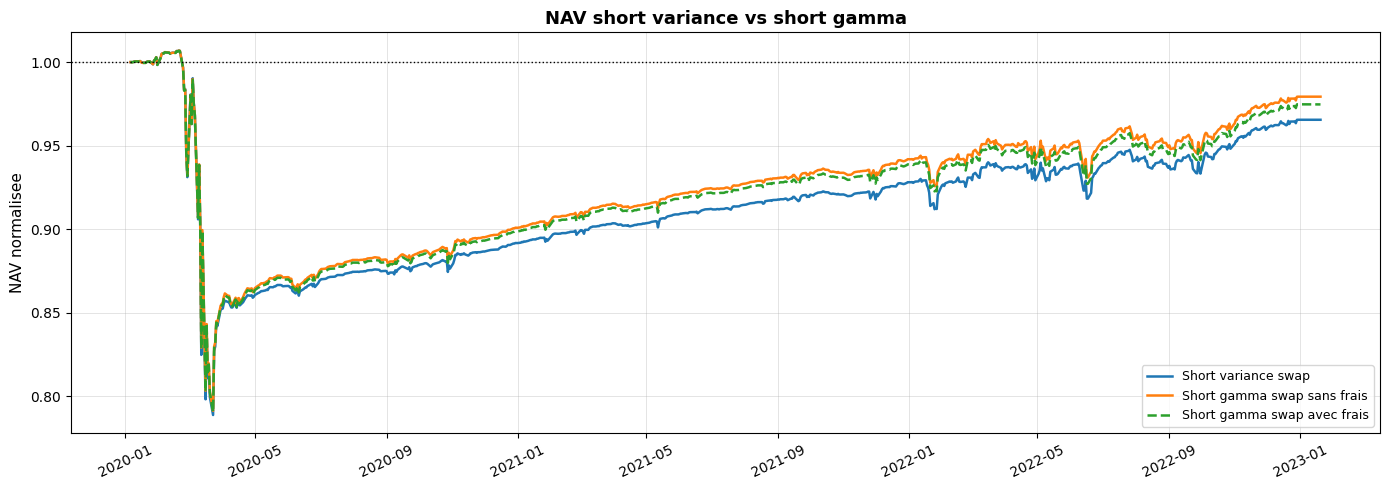

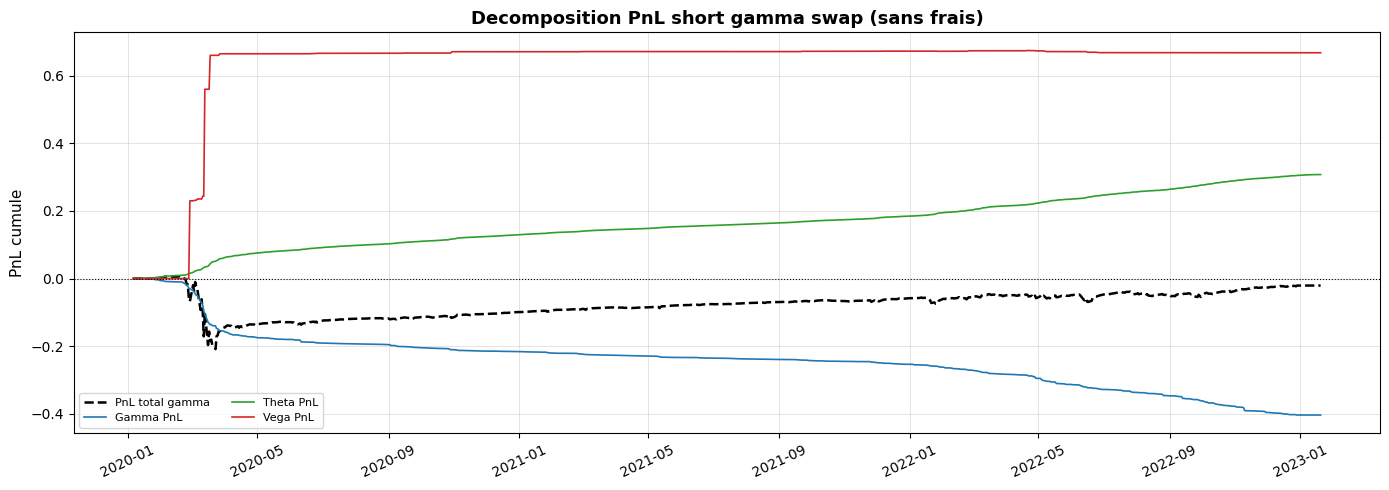

NAV finale sans frais      : 0.9793
NAV finale avec frais      : 0.9747
Perf totale sans frais     : -2.07%
Perf totale avec frais     : -2.53%
Max drawdown sans frais    : -21.4%
Max drawdown avec frais    : -21.5%
Impact frais (NAV)         : -0.0046 (0.47% de la NAV brute)


In [10]:
# NAV short gamma swap: sans frais vs avec frais bid/ask
positions_gamma = GammaSwapBuilder.build_positions(
    df_spy,
    weight=-1.0,
    day_to_expiry_target=21,
    rebal_week_day=[1],
    strike_spacing=2.0,
)
bt_gamma = PreloadedBacktester(positions_gamma, df_spy)
bt_gamma.compute_backtest()
bt_gamma_tcost = PreloadedBacktesterBidAsk(positions_gamma, df_spy)
bt_gamma_tcost.compute_backtest()
bt_gamma_nav       = bt_gamma.nav.copy()
bt_gamma_pnl       = bt_gamma.pnl.copy()
bt_gamma_nav_tcost = bt_gamma_tcost.nav.copy()
nav_cmp = bt_nav.rename(columns={"NAV": "Short variance"}).join(
    bt_gamma_nav.rename(columns={"NAV": "Short gamma sans frais"}), how="inner"
).join(
    bt_gamma_nav_tcost.rename(columns={"NAV": "Short gamma avec frais"}), how="inner"
)
nav_cmp = nav_cmp / nav_cmp.iloc[0]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nav_cmp.index, nav_cmp["Short variance"],         lw=1.8, label="Short variance swap")
ax.plot(nav_cmp.index, nav_cmp["Short gamma sans frais"], lw=1.8, label="Short gamma swap sans frais")
ax.plot(nav_cmp.index, nav_cmp["Short gamma avec frais"], lw=1.8, ls="--", label="Short gamma swap avec frais")
ax.axhline(1.0, color="black", ls=":", lw=1.0)
ax.set_ylabel("NAV normalisee")
ax.set_title("NAV short variance vs short gamma")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bt_gamma_pnl.index, bt_gamma_pnl["pnl"].cumsum(), lw=1.8, color="black", ls="--", label="PnL total gamma")
if "gamma_pnl" in bt_gamma_pnl.columns:
    ax.plot(bt_gamma_pnl.index, bt_gamma_pnl["gamma_pnl"].cumsum(), lw=1.2, color="tab:blue",  label="Gamma PnL")
if "theta_pnl" in bt_gamma_pnl.columns:
    ax.plot(bt_gamma_pnl.index, bt_gamma_pnl["theta_pnl"].cumsum(), lw=1.2, color="tab:green", label="Theta PnL")
if "vega_pnl" in bt_gamma_pnl.columns:
    ax.plot(bt_gamma_pnl.index, bt_gamma_pnl["vega_pnl"].cumsum(),  lw=1.2, color="tab:red",   label="Vega PnL")
ax.axhline(0, color="black", ls=":", lw=0.8)
ax.set_ylabel("PnL cumule")
ax.set_title("Decomposition PnL short gamma swap (sans frais)")
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
# Métriques
nav_g      = bt_gamma_nav["NAV"].iloc[-1]
nav_g_t    = bt_gamma_nav_tcost["NAV"].iloc[-1]
max_dd_g   = (bt_gamma_nav["NAV"] / bt_gamma_nav["NAV"].cummax() - 1).min()
max_dd_g_t = (bt_gamma_nav_tcost["NAV"] / bt_gamma_nav_tcost["NAV"].cummax() - 1).min()
fee_abs    = nav_g - nav_g_t
fee_pct    = fee_abs / nav_g if nav_g != 0 else float("nan")
print(f"NAV finale sans frais      : {nav_g:.4f}")
print(f"NAV finale avec frais      : {nav_g_t:.4f}")
print(f"Perf totale sans frais     : {nav_g - 1:+.2%}")
print(f"Perf totale avec frais     : {nav_g_t - 1:+.2%}")
print(f"Max drawdown sans frais    : {max_dd_g:.1%}")
print(f"Max drawdown avec frais    : {max_dd_g_t:.1%}")
print(f"Impact frais (NAV)         : -{fee_abs:.4f} ({fee_pct:.2%} de la NAV brute)")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**NAV — le short gamma swap amortit les stress, mais porte moins de carry.**

Sur la figure NAV, la courbe short gamma reste au-dessus du short variance sur la majeure partie de l’échantillon, avec des creux généralement moins profonds en phases de choc. C’est cohérent avec la construction du gamma swap : le noyau $1/(S_0K)$ charge moins l’aile put profonde que $1/K^2$, donc l’exposition aux épisodes de crash-vol est atténuée. En contrepartie théorique, le fair strike $K_{\Gamma}$ est inférieur à $K_{\text{var}}$, ce qui implique une prime structurelle plus faible à encaisser.

**PnL décomposé — interprétation correcte uniquement avec toutes les composantes.**

La décomposition montre un $\Theta$ cumulé positif, un $\Gamma$ cumulé négatif et un $\text{Vega}$ cumulé positif sur la période. Mais ces trois termes n’expliquent pas seuls le PnL total observé : l’écart avec la courbe de PnL total indique qu’une composante non affichée ($\Delta$, résiduel, effets de roll/discrétisation, coûts selon la convention) contribue matériellement. L’interprétation rigoureuse est donc : **le gamma swap réduit l’exposition aux stress par rapport au variance swap, au prix d’un portage plus modéré, avec un PnL final gouverné par la somme complète des briques**.

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

## Capturer une prime d'asymétrie ?

L'écart $K_{var} - K_\Gamma$ n'est pas un artefact de construction : il est directement piloté par le **skew de la surface de volatilité**. Le noyau $1/K^2$ surpondère les puts deep OTM par rapport au noyau $1/(S_0 K)$ — et ce sont précisément ces puts, rendus chers par la demande de protection, qui gonflent $K_{var}$ au-dessus de $K_\Gamma$. Plus le skew est prononcé, plus l'écart est large.

Cet écart est **structurellement positif** et **persistant** : il reflète une prime que le marché rémunère en permanence pour assurer le risque de queue gauche. Un investisseur qui pense que cette prime est excessive peut chercher à la capter en prenant position sur la *différence* entre les deux strikes — c'est-à-dire en construisant un portefeuille sensible au skew mais pas à la variance globale.

Une façon naturelle d'y penser : être **long variance swap** et **short gamma swap** revient à se positionner précisément sur cet écart. On paye un carry négatif à l'initiation ($K_\Gamma < K_{var}$), et on encaisse si le skew réalisé est inférieur au skew implicite. Le produit qui formalise cette intuition est l'objet de l'acte suivant.

</div>


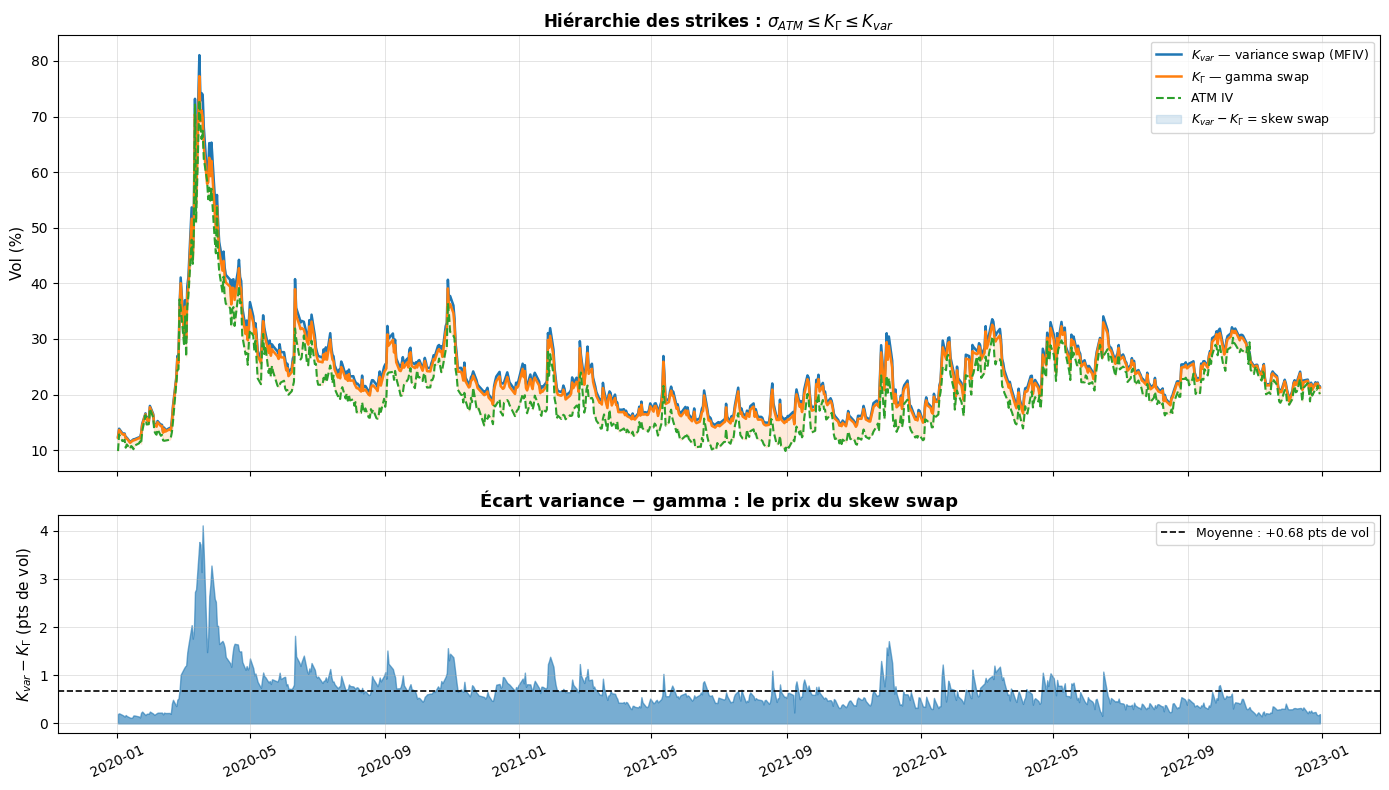

ATM IV moyenne      : 20.52%
K_gamma“ moyenne         : 23.55%
K_var moyenne       : 24.23%
Écart K_var − K_Γ   : +0.68 pts de vol
Ordering ATM ≤ ATM ≤ var : 99.1% du temps


In [11]:
# Transition : K_var ≥ K_Γ ≥ ATM IV 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(df_gamma_compare["date"], df_gamma_compare["mfiv_vol"] * 100,
         lw=1.8, color="tab:blue",   label=r"$K_{var}$ — variance swap (MFIV)")
ax1.plot(df_gamma_compare["date"], df_gamma_compare["gamma_vol"] * 100,
         lw=1.8, color="tab:orange", label=r"$K_\Gamma$ — gamma swap")
ax1.plot(df_gamma_compare["date"], df_gamma_compare["atm_iv"] * 100,
         lw=1.5, color="tab:green",  ls="--", label="ATM IV")
ax1.fill_between(df_gamma_compare["date"],
                 df_gamma_compare["mfiv_vol"] * 100,
                 df_gamma_compare["gamma_vol"] * 100,
                 alpha=0.15, color="tab:blue",
                 label=r"$K_{var} - K_\Gamma$ = skew swap")
ax1.fill_between(df_gamma_compare["date"],
                 df_gamma_compare["gamma_vol"] * 100,
                 df_gamma_compare["atm_iv"] * 100,
                 alpha=0.15, color="tab:orange")
ax1.set_ylabel("Vol (%)")
ax1.set_title(r"Hiérarchie des strikes : $\sigma_{ATM} \leq K_\Gamma \leq K_{var}$", fontsize=12)
ax1.legend(fontsize=9)
skew_spread = (df_gamma_compare["mfiv_vol"] - df_gamma_compare["gamma_vol"]) * 100
ax2.fill_between(df_gamma_compare["date"], skew_spread, 0,
                 where=skew_spread >= 0, alpha=0.6, color="tab:blue")
ax2.axhline(skew_spread.mean(), color="black", ls="--", lw=1.2,
            label=f"Moyenne : +{skew_spread.mean():.2f} pts de vol")
ax2.set_ylabel(r"$K_{var} - K_\Gamma$ (pts de vol)")
ax2.set_title("Écart variance − gamma : le prix du skew swap")
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
ordering_share = (
    (df_gamma_compare["atm_iv"] <= df_gamma_compare["gamma_vol"])
    & (df_gamma_compare["gamma_vol"] <= df_gamma_compare["mfiv_vol"])
).mean()
print(f"ATM IV moyenne      : {df_gamma_compare['atm_iv'].mean():.2%}")
print(f"K_gamma“ moyenne         : {df_gamma_compare['gamma_vol'].mean():.2%}")
print(f"K_var moyenne       : {df_gamma_compare['mfiv_vol'].mean():.2%}")
print(f"Écart K_var − K_Γ   : +{skew_spread.mean():.2f} pts de vol")
print(f"Ordering ATM ≤ ATM ≤ var : {ordering_share:.1%} du temps")


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte III — Skew swap : isoler l'asymétrie de la distribution

L'acte précédent a montré que l'écart $K_{var} - K_\Gamma$ est structurellement positif et piloté par le skew de la surface. Le **skew swap** formalise cette observation en un contrat dont le payoff est exactement cet écart, mesuré sur la variance *réalisée* :

$$\Pi_T = N \left[ \underbrace{\left(\sigma_R^2 - \sigma_{\Gamma,R}^2\right)}_{\text{skew réalisé}} - K_{skew} \right], \qquad K_{skew} = K_{var} - K_\Gamma$$

La quantité réalisée $\sigma_R^2 - \sigma_{\Gamma,R}^2 = \frac{252}{n}\sum_{i=1}^n \left(1 - \frac{S_i}{S_0}\right) r_i^2$ pèse chaque rendement par le facteur $\left(1 - S_i/S_0\right)$. Ce facteur est **positif lorsque le spot est bas** — c'est-à-dire précisément lors des crashes — et négatif lorsque le marché monte. Le skew swap réalisé est donc grand quand la volatilité se concentre dans les baisses, et faible (voire négatif) quand elle se concentre dans les hausses.

Le contrat isole ainsi une propriété structurelle de la distribution : non pas son niveau de variance global, mais **l'asymétrie de sa réalisation**. Un vendeur de skew swap encaisse la prime $K_{skew}$ si le marché est plus symétrique que ce qu'implique la surface de volatilité. Il perd si les crashes génèrent une variance très concentrée à la baisse — exactement le scénario que le skew implicite anticipe.

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte III.2 — Réplication statique du skew swap

Le cadre de réplication repose sur la **formule de spanning de Carr & Madan (1998)**, qui exprime toute fonction deux fois dérivable du sous-jacent comme une combinaison pondérée d'options vanille. Appliquée séparément au variance swap et au gamma swap — dont les noyaux sont respectivement $\Delta K/K^2$ (Neuberger 1994, Demeterfi et al. 1999) et $\Delta K/(S_0 K)$ (Carr & Lee 2009) — leur différence fournit directement le fair strike du skew swap :

$$K_{skew} = K_{var} - K_\Gamma = \frac{2e^{rT}}{T} \int_0^\infty Q(K) \left( \frac{1}{K^2} - \frac{1}{S_0 K} \right) dK$$

où $Q(K)$ désigne le prix de l'option OTM de strike $K$ (put si $K < F$, call si $K \geq F$). Le skew swap ne requiert donc **aucune hypothèse de modèle** : son fair strike est entièrement déterminé par le prix des options cotées, de la même manière que le MFIV.

Le **noyau différentiel** qui pondère chaque option est :

$$w_{skew}(K) = \frac{\Delta K}{K^2} - \frac{\Delta K}{S_0 K} = \frac{\Delta K \cdot (S_0 - K)}{S_0\, K^2}$$

Ce noyau possède des propriétés remarquables. Il s'annule exactement en $K = S_0$ et **change de signe** à ce niveau : positif pour $K < S_0$ (long les puts OTM, aile gauche), négatif pour $K > S_0$ (short les calls OTM, aile droite). Le skew swap est donc une position **longue de l'aile gauche et courte de l'aile droite** — une exposition pure à l'asymétrie de la surface, sans sensibilité de premier ordre au niveau de variance globale. Plus le skew de la surface est prononcé, plus $K_{skew}$ est élevé, car les puts chers gonflent la contribution positive du noyau dans l'aile gauche.

</div>


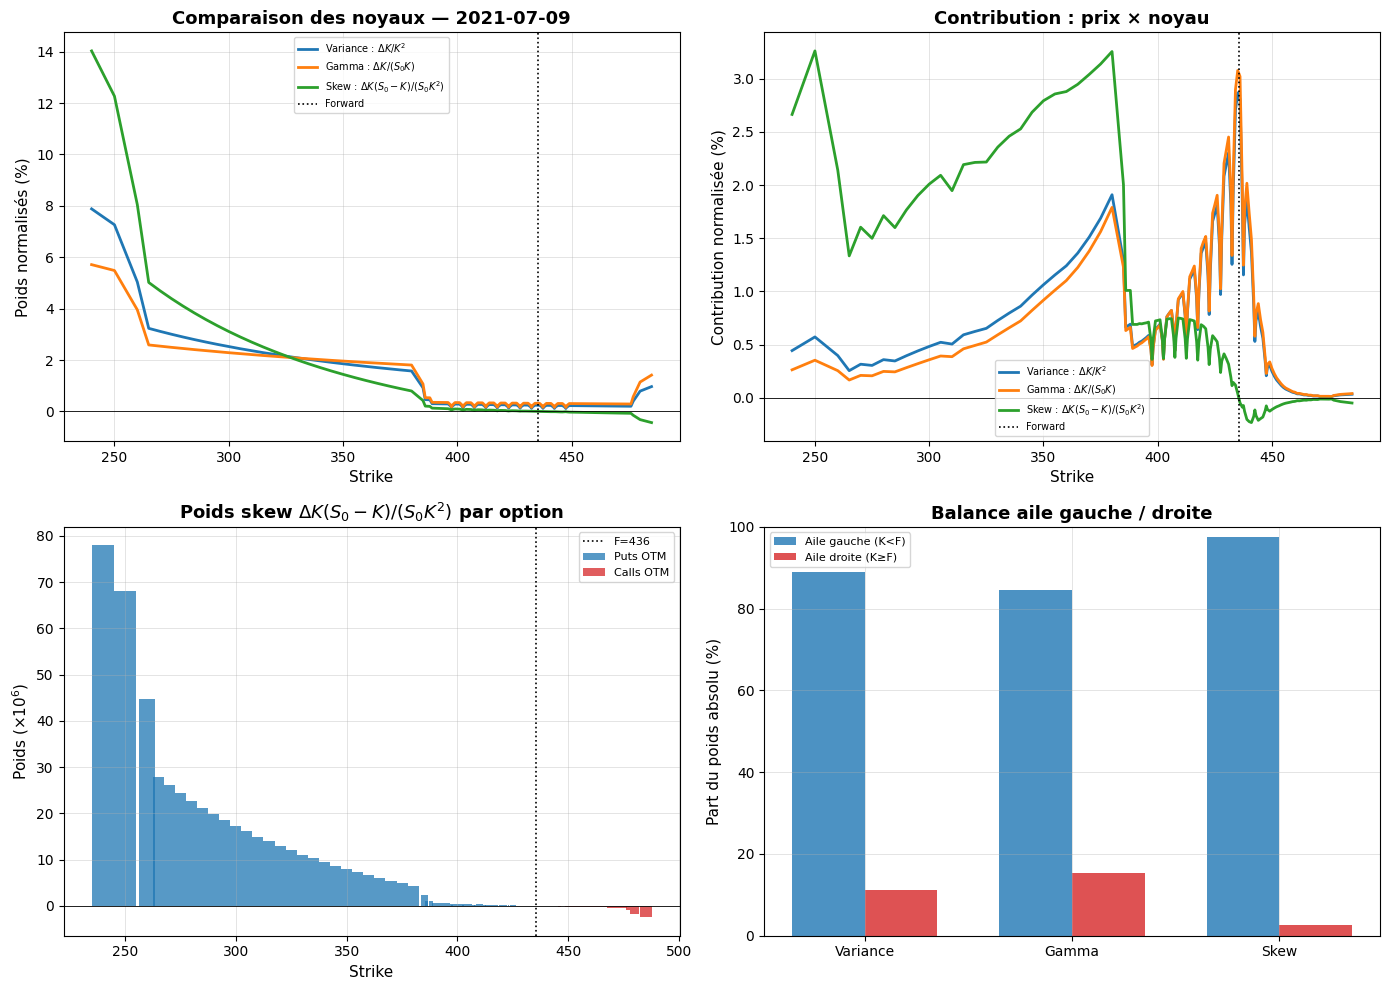

Fraction des strikes avec poids positif (long) : 64.4%
Fraction des strikes avec poids négatif (short) : 35.6%
  kernel left right
Variance 88.9  11.1
   Gamma 84.5  15.5
    Skew 97.5   2.5


In [12]:
# Skew kernel = différence exacte des deux noyaux (gamma_kernel = deltaK/(S0K) déjà)
kernel_df["skew_kernel"]       = kernel_df["var_kernel"] - kernel_df["gamma_kernel"]
kernel_df["skew_kernel_norm"]  = kernel_df["skew_kernel"]  / kernel_df["skew_kernel"].abs().sum()  * 100
kernel_df["skew_contrib"]      = kernel_df["skew_kernel"]  * kernel_df["otm_mid"]
kernel_df["skew_contrib_norm"] = kernel_df["skew_contrib"] / kernel_df["skew_contrib"].abs().sum() * 100
kernel_df["var_kernel_norm"]    = kernel_df["var_kernel"]   / kernel_df["var_kernel"].abs().sum()   * 100
kernel_df["gamma_kernel_norm"]  = kernel_df["gamma_kernel"] / kernel_df["gamma_kernel"].abs().sum() * 100
kernel_df["var_contrib_norm"]   = (kernel_df["var_kernel"]   * kernel_df["otm_mid"]) / (kernel_df["var_kernel"]   * kernel_df["otm_mid"]).abs().sum() * 100
kernel_df["gamma_contrib_norm"] = (kernel_df["gamma_kernel"] * kernel_df["otm_mid"]) / (kernel_df["gamma_kernel"] * kernel_df["otm_mid"]).abs().sum() * 100
st = kernel_df["strike"].to_numpy()
# Masques puts / calls pour les barres
put_mask  = kernel_df["strike"] <  fwd_gamma
call_mask = kernel_df["strike"] >= fwd_gamma
dK_all = _compute_strike_widths(st)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# (0,0) Noyaux normalisés — 3 lignes
axes[0, 0].plot(st, kernel_df["var_kernel_norm"],   lw=2.0, label=r"Variance : $\Delta K/K^2$")
axes[0, 0].plot(st, kernel_df["gamma_kernel_norm"], lw=2.0, label=r"Gamma : $\Delta K/(S_0 K)$")
axes[0, 0].plot(st, kernel_df["skew_kernel_norm"],  lw=2.0, label=r"Skew : $\Delta K(S_0-K)/(S_0 K^2)$")
axes[0, 0].axvline(fwd_gamma, color="black", ls=":", lw=1.2, label="Forward")
axes[0, 0].axhline(0, color="black", lw=0.6)
axes[0, 0].set_title(f"Comparaison des noyaux \u2014 {sample_date_gamma.date()}")
axes[0, 0].set_xlabel("Strike")
axes[0, 0].set_ylabel("Poids normalis\u00e9s (%)")
axes[0, 0].legend(fontsize=7)
# (0,1) Contributions prix × noyau — 3 lignes
axes[0, 1].plot(st, kernel_df["var_contrib_norm"],   lw=2.0, label=r"Variance : $\Delta K/K^2$")
axes[0, 1].plot(st, kernel_df["gamma_contrib_norm"], lw=2.0, label=r"Gamma : $\Delta K/(S_0 K)$")
axes[0, 1].plot(st, kernel_df["skew_contrib_norm"],  lw=2.0, label=r"Skew : $\Delta K(S_0-K)/(S_0 K^2)$")
axes[0, 1].axvline(fwd_gamma, color="black", ls=":", lw=1.2, label="Forward")
axes[0, 1].axhline(0, color="black", lw=0.6)
axes[0, 1].set_title("Contribution : prix \u00d7 noyau")
axes[0, 1].set_xlabel("Strike")
axes[0, 1].set_ylabel("Contribution normalis\u00e9e (%)")
axes[0, 1].legend(fontsize=7)
# (1,0) Poids skew par option
sk_raw = kernel_df["skew_kernel"].to_numpy()
plot_kernel_bars(axes[1, 0], st, sk_raw, dK_all, put_mask,
                 fwd_gamma, r"Poids skew $\Delta K(S_0-K)/(S_0 K^2)$ par option")
# (1,1) Wing balance — var, gamma, skew
left_mask  = kernel_df["strike"] <  fwd_gamma
right_mask = kernel_df["strike"] >= fwd_gamma
wing_rows = []
for col, name in [("var_kernel","Variance"), ("gamma_kernel","Gamma"), ("skew_kernel","Skew")]:
    lft = kernel_df.loc[left_mask,  col].abs().sum()
    rgt = kernel_df.loc[right_mask, col].abs().sum()
    tot = lft + rgt
    wing_rows.append((name, 100*lft/tot, 100*rgt/tot))
wing_df = pd.DataFrame(wing_rows, columns=["kernel","left","right"])
x = np.arange(3);  bw = 0.35
axes[1, 1].bar(x - bw/2, wing_df["left"],  width=bw, alpha=0.8, color="tab:blue", label="Aile gauche (K<F)")
axes[1, 1].bar(x + bw/2, wing_df["right"], width=bw, alpha=0.8, color="tab:red",  label="Aile droite (K\u2265F)")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(["Variance","Gamma","Skew"])
axes[1, 1].set_ylim(0, 100)
axes[1, 1].set_ylabel("Part du poids absolu (%)")
axes[1, 1].set_title("Balance aile gauche / droite")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()
pct_pos = (kernel_df["skew_kernel"] > 0).mean()
print(f"Fraction des strikes avec poids positif (long) : {pct_pos:.1%}")
print(f"Fraction des strikes avec poids n\u00e9gatif (short) : {1-pct_pos:.1%}")
print(wing_df.to_string(index=False, formatters={"left":"{:.1f}".format,"right":"{:.1f}".format}))


<div style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Noyau skew $\Delta K(S_0-K)/(S_0K^2)$ — une exposition de pente, pas de niveau.**

Le noyau skew change de signe autour du forward $F$ : il est positif pour $K<F$ (puts OTM) et négatif pour $K>F$ (calls OTM). Cette structure impose une position longue aile gauche / courte aile droite, donc une exposition directe à la pente de skew, avec faible sensibilité de premier ordre au niveau global de variance.

**Contribution prix $\times$ noyau — la gauche domine économiquement.**

Sur le panneau haut-droit, la contribution est fortement positive sur les puts OTM profonds (prix élevés + poids positif important), puis devient faible et négative côté calls. Le signal économique est clair : le strike de skew est principalement déterminé par la prime de protection de queue gauche.

**Balance des ailes — asymétrie structurelle très marquée.**

Le panneau bas-droit montre une concentration extrême du poids absolu sur $K<F$ (~97% contre ~3% côté droit). Ce n’est pas un bruit d’échantillon mais une propriété du noyau : parmi Variance/Gamma/Skew, le skew swap est le contrat le plus asymétrique et le plus "left-tail driven".

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte III.3 — La skew risk premium

Comparer $K_{skew}(t)$ au skew réalisé sur la période suivante revient à mesurer ex-post le gain d'un vendeur de skew swap. On définit la **skew risk premium** (SRP) par :

$$\text{SRP}(t) = K_{skew}(t) - \underbrace{\left(\sigma_R^2 - \sigma_{\Gamma,R}^2\right)_{t \to t+T}}_{\text{skew réalisé forward}}$$

La quantité réalisée $\sigma_R^2 - \sigma_{\Gamma,R}^2 = \frac{252}{n}\sum_{i=1}^n \left(1 - \frac{S_i}{S_0}\right) r_i^2$ est grande uniquement lorsque la volatilité se concentre lors des baisses — c'est-à-dire lors des crashes. En régime calme, les facteurs $1 - S_i/S_0$ sont proches de zéro et le skew réalisé reste faible.

La SRP est l'exact analogue de la VRP pour le skew : elle mesure à quel point la surface de volatilité **surpaye structurellement le risque de queue gauche**. Si $\text{SRP}(t) > 0$ en moyenne, c'est que les investisseurs paient chroniquement trop cher pour s'assurer contre les scenarios où la volatilité explose à la baisse — par aversion au risque et demande de protection. Un vendeur de skew swap encaisse cette prime en régime normal et souffre lors des episodes où le skew réalisé dépasse le strike implicite.

La SRP hérite des propriétés **contra-cycliques** de la VRP : elle est négative lors des crises (le skew réalisé explose, $K_{skew}$ ne l'anticipait pas suffisamment) et fortement positive en période calme. Cette asymétrie justifie le coût implicite d'une position short skew — le vendeur supporte un risque de perte concentré et sévère.

</div>

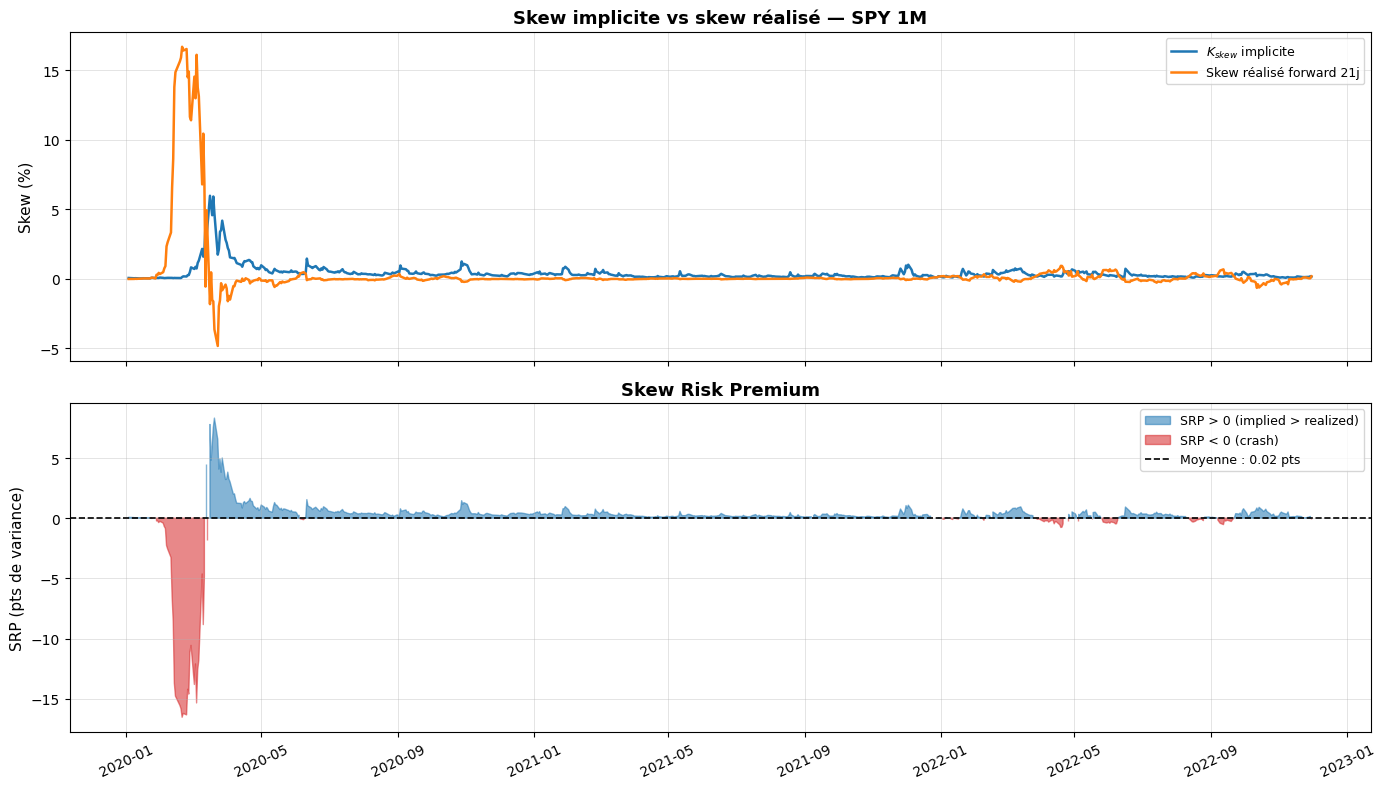

SRP moyenne     : 0.017 pts
SRP médiane     : 0.238 pts
% temps SRP > 0 : 85.3%


In [13]:
# df_skew_swap 
df_skew_swap = (
    mfiv[["date", "mfiv", "mfiv_vol"]]
    .merge(gamma_swap[["date", "gamma_var", "gamma_vol"]], on="date", how="inner")
    .dropna()
    .sort_values("date")
)
df_skew_swap["skew_var"] = df_skew_swap["mfiv"] - df_skew_swap["gamma_var"]
df_skew_swap["skew_vol"] = np.sqrt(df_skew_swap["skew_var"].clip(lower=0))
# Realized skew (forward 21j) 
window = 21
ann    = 252
ret_df = df_spot[["date", "spot"]].copy()
ret_df["log_return"] = np.log(ret_df["spot"] / ret_df["spot"].shift(1))
ret_df = ret_df.dropna(subset=["log_return"]).sort_values("date").reset_index(drop=True)
skew_real_fwd = np.full(len(ret_df), np.nan)
for i in range(len(ret_df) - window):
    r  = ret_df["log_return"].iloc[i+1 : i+window+1].to_numpy()
    s  = ret_df["spot"].iloc[i+1 : i+window+1].to_numpy()
    s0 = ret_df["spot"].iloc[i]
    plain_var = ann / window * np.sum(r ** 2)
    gamma_var = ann / window * np.sum((s / s0) * r ** 2)
    skew_real_fwd[i] = plain_var - gamma_var
df_skew_real = pd.DataFrame({
    "date":              ret_df["date"],
    "skew_realized_fwd": skew_real_fwd,
}).dropna()
# Merge implied vs realized 
df_srp = (
    df_skew_swap[["date", "skew_var"]]
    .merge(df_skew_real, on="date", how="inner")
    .dropna()
    .sort_values("date")
)
df_srp["srp"] = df_srp["skew_var"] - df_srp["skew_realized_fwd"]
# Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(df_srp["date"], df_srp["skew_var"]          * 100,
         lw=1.8, color="tab:blue",   label="$K_{skew}$ implicite")
ax1.plot(df_srp["date"], df_srp["skew_realized_fwd"] * 100,
         lw=1.8, color="tab:orange", label="Skew réalisé forward 21j")
ax1.set_ylabel("Skew (%)")
ax1.set_title("Skew implicite vs skew réalisé — SPY 1M")
ax1.legend(fontsize=9)
srp = df_srp["srp"] * 100
ax2.fill_between(df_srp["date"], srp, 0,
                 where=srp >= 0, alpha=0.55, color="tab:blue",
                 label="SRP > 0 (implied > realized)")
ax2.fill_between(df_srp["date"], srp, 0,
                 where=srp <  0, alpha=0.55, color="tab:red",
                 label="SRP < 0 (crash)")
ax2.axhline(srp.mean(), color="black", ls="--", lw=1.2,
            label=f"Moyenne : {srp.mean():.2f} pts")
ax2.set_ylabel("SRP (pts de variance)")
ax2.set_title("Skew Risk Premium")
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print(f"SRP moyenne     : {srp.mean():.3f} pts")
print(f"SRP médiane     : {srp.median():.3f} pts")
print(f"% temps SRP > 0 : {(srp > 0).mean():.1%}")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte III.4 — Backtest du short skew proxy

Le skew swap n'étant pas un produit coté en vanille, on l'implémente comme un **portefeuille synthétique** : short variance swap (noyau $\Delta K/K^2$) combiné avec un long gamma swap (noyau $\Delta K/(S_0K)$), chaque leg à notionnel égal. Cette combinaison réplique exactement le payoff du skew swap — la différence des deux réalisations — et son fair strike est mécaniquement $K_{skew} = K_{var} - K_\Gamma$.

La position encaisse la skew risk premium $\text{SRP} = K_{skew} - (\sigma_R^2 - \sigma_{\Gamma,R}^2)$ lorsque le skew implicite dépasse le skew réalisé, ce qui est le régime dominant en l'absence de choc. Lors d'un crash, la variance plain explose davantage que la variance spot-pondérée — le skew réalisé dépasse le strike implicite et la position perd.

Le P&L quotidien est décomposé en contributions par grec, obtenues par différence des deux books individuels :

- **Gamma P&L** — exposition nette aux mouvements du sous-jacent ; le leg long gamma compense partiellement le leg short variance, ce qui atténue l'exposition gamma globale du proxy.
- **Theta P&L** — le carry net est positif en régime calme : le theta encaissé sur le short variance excède le theta payé sur le long gamma d'un montant lié au différentiel de prime.
- **Vega P&L** — principale source de risque ; un choc de surface augmente les deux legs, mais le short variance souffre davantage car son noyau surpondère les options les plus sensibles au vol.

</div>

100%|██████████| 794/794 [00:04<00:00, 183.63it/s]


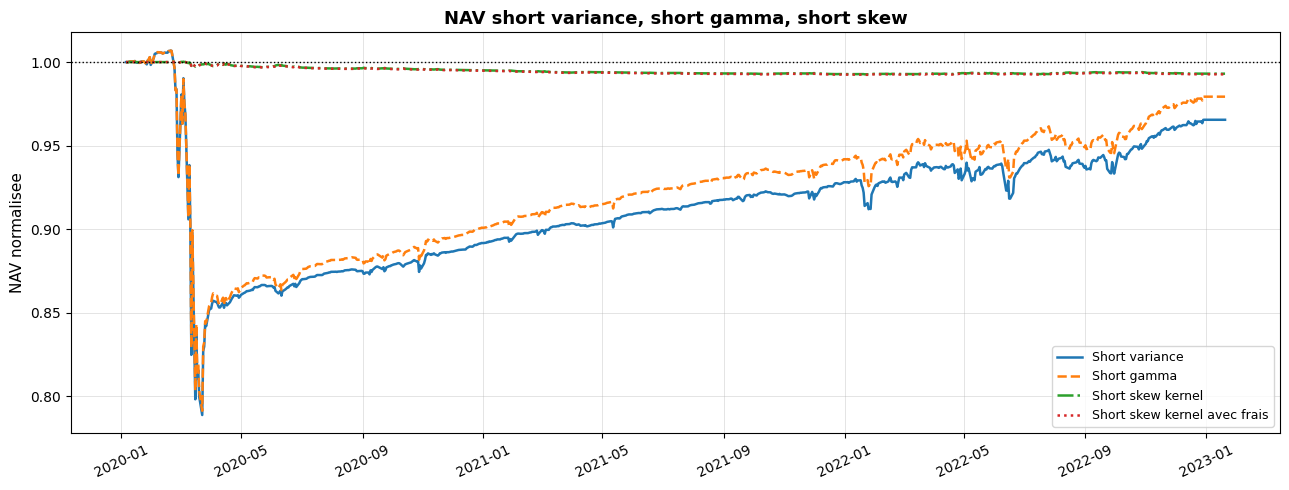

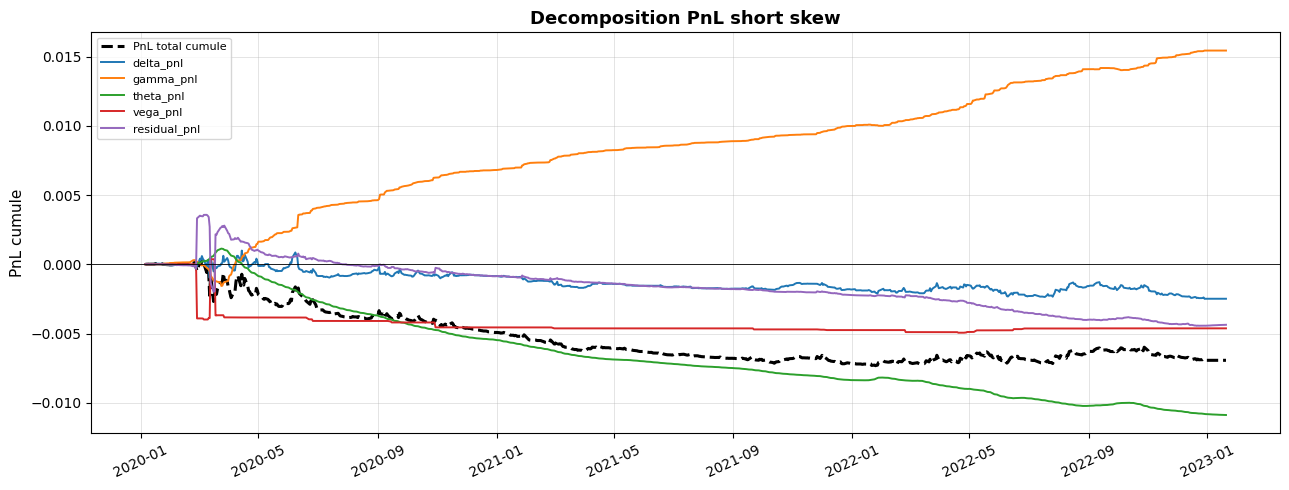

NAV finale sans frais      : 0.9931
NAV finale avec frais      : 0.9927
Perf totale sans frais     : -0.69%
Perf totale avec frais     : -0.73%
Max drawdown sans frais    : -0.8%
Max drawdown avec frais    : -0.8%
Impact frais (NAV)         : -0.0004 (0.04% de la NAV brute)


In [14]:
positions_skew = SkewSwapBuilder.build_positions(
    df_spy,
    weight=-1.0,
    day_to_expiry_target=21,
    rebal_week_day=[1],
    strike_spacing=2.0,
)
bt_skew = PreloadedBacktester(positions_skew, df_spy)
bt_skew.compute_backtest()
bt_skew_nav = bt_skew.nav.copy()
bt_skew_pnl = bt_skew.pnl.copy()
bt_skew_net = PreloadedBacktesterBidAsk(positions_skew, df_spy)
bt_skew_net.compute_backtest()
bt_skew_nav_net = bt_skew_net.nav.copy()
bt_skew_pnl_net = bt_skew_net.pnl.copy()
required_nav = ["bt_nav", "bt_gamma_nav"]
missing = [x for x in required_nav if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")
common_idx = (
    bt_nav.index
    .intersection(bt_gamma_nav.index)
    .intersection(bt_skew_nav.index)
    .intersection(bt_skew_nav_net.index)
)
if len(common_idx) == 0:
    raise RuntimeError("No common dates between variance/gamma/skew NAV series.")
nav_cmp = pd.DataFrame({
    "Short variance": bt_nav.loc[common_idx, "NAV"],
    "Short gamma": bt_gamma_nav.loc[common_idx, "NAV"],
    "Short skew kernel": bt_skew_nav.loc[common_idx, "NAV"],
    "Short skew kernel avec frais": bt_skew_nav_net.loc[common_idx, "NAV"],
})
nav_cmp = nav_cmp / nav_cmp.iloc[0]
fig, ax = plt.subplots(figsize=(13, 5))
styles = {
    "Short variance": "-",
    "Short gamma": "--",
    "Short skew kernel": "-.",
    "Short skew kernel avec frais": ":",
}
for col in nav_cmp.columns:
    ax.plot(nav_cmp.index, nav_cmp[col], lw=1.8, ls=styles[col], label=col)
ax.axhline(1.0, color="black", ls=":", lw=1.0)
ax.set_title("NAV short variance, short gamma, short skew")
ax.set_ylabel("NAV normalisee")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
greek_cols = [c for c in ["delta_pnl", "gamma_pnl", "theta_pnl", "vega_pnl", "residual_pnl"] if c in bt_skew_pnl.columns]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bt_skew_pnl.index, bt_skew_pnl["pnl"].cumsum(), lw=2.2, color="black", ls="--", label="PnL total cumule")
for col in greek_cols:
    ax.plot(bt_skew_pnl.index, bt_skew_pnl[col].cumsum(), lw=1.4, label=col)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Decomposition PnL short skew")
ax.set_ylabel("PnL cumule")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
nav_sk = bt_skew_nav["NAV"].iloc[-1]
nav_sk_t = bt_skew_nav_net["NAV"].iloc[-1]
max_dd_sk = (bt_skew_nav["NAV"] / bt_skew_nav["NAV"].cummax() - 1).min()
max_dd_sk_t = (bt_skew_nav_net["NAV"] / bt_skew_nav_net["NAV"].cummax() - 1).min()
fee_abs = nav_sk - nav_sk_t
fee_pct = fee_abs / nav_sk if nav_sk != 0 else np.nan
print(f"NAV finale sans frais      : {nav_sk:.4f}")
print(f"NAV finale avec frais      : {nav_sk_t:.4f}")
print(f"Perf totale sans frais     : {nav_sk - 1:+.2%}")
print(f"Perf totale avec frais     : {nav_sk_t - 1:+.2%}")
print(f"Max drawdown sans frais    : {max_dd_sk:.1%}")
print(f"Max drawdown avec frais    : {max_dd_sk_t:.1%}")
print(f"Impact frais (NAV)         : -{fee_abs:.4f} ({fee_pct:.2%} de la NAV brute)")
nav_skew = bt_skew_nav["NAV"].copy()


<div style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**NAV + PnL : un spread de noyaux, pas un portage de niveau.**

Le short skew kernel reste presque plat (NAV proche de 1), alors que short variance et short gamma dérivent davantage. C’est attendu : le skew est construit comme une différence de deux expositions très corrélées (variance et gamma), donc la composante “niveau de variance” se neutralise en grande partie. Le portefeuille porte surtout la **pente/asymétrie** de la surface, pas son niveau global.

**Pourquoi short skew sous-performe légèrement ici.**

Sur la décomposition PnL, le total cumulé est négatif et dominé par un **theta négatif** persistant, partiellement compensé par un **gamma positif**. Cela signifie qu’en moyenne sur 2020-2022, la jambe courte de calls/neutralisation de niveau a coûté plus de portage que ce que la convexité nette a rapporté. En d’autres termes, la prime de skew encaissée ex ante n’a pas suffi à compenser la réalisation ex post du skew sur cette fenêtre.

**Rôle du résiduel et des frais.**

Le résiduel est aussi négatif (effets de discrétisation, rebalancement hebdo, couverture non continue, interpolation de strikes), ce qui confirme que l’écart entre “théorie continue” et “implémentation discrète” pénalise le trade. Le fait que la courbe “avec frais” soit quasi superposée à la courbe sans frais indique que, pour ce portefeuille précis, les coûts de transaction sont de second ordre par rapport au signal économique lui-même.

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte IV — Moment d'ordre 4 : capter l'épaisseur des queues de distribution

La variance et le skew swap capturent respectivement le niveau et l'asymétrie de la distribution risk-neutre. Il reste une troisième dimension : l'épaisseur des queues, c'est-à-dire la probabilité d'événements extrêmes au-delà de ce qu'implique une distribution normale. Deux approches permettent de construire un contrat sur cette quantité à partir de prix d'options observés.


**L'approche de Carr et Madan (1998)** repose sur un résultat d'analyse : toute fonction deux fois continûment dérivable $f$ admet la décomposition exacte

$$f(S_T) = f(F) + f'(F)(S_T - F) + \int_0^F f''(K)(K-S_T)^+\,dK + \int_F^\infty f''(K)(S_T-K)^+\,dK$$

Ce résultat s'obtient par deux intégrations par parties successives. L'idée centrale est qu'une option pondérée par $f''(K)\,dK$ constitue un **papillon infinitésimal** centré en $K$ : son payoff est concentré au voisinage de $K$ et sa valeur de marché est $C(K,T)\cdot f''(K)\,dK$. La décomposition dit alors que tout payoff lisse se réplique exactement par un continuum de tels papillons — le portefeuille d'options OTM pondérées par la courbure locale $f''(K)$ de la fonction cible.

En passant sous l'espérance risk-neutre et en notant que $\mathbb{E}^Q[S_T] = F$ (le terme linéaire disparaît), on obtient :

$$e^{-rT}\mathbb{E}^Q[f(S_T)] = e^{-rT}f(F) + \int_0^F f''(K)\,P(K,T)\,dK + \int_F^\infty f''(K)\,C(K,T)\,dK$$

Appliquée à $f(S_T) = (S_T/F - 1)^4$, cette décomposition est particulièrement propre : $f(F) = 0$ et $f'(F) = 0$, de sorte que le portefeuille répliquant ne contient ni cash ni forward — uniquement des options OTM. La courbure vaut $f''(K) = 12(K-F)^2/F^4$, ce qui donne le **moment d'ordre 4 brut** des rendements simples :

$$M_4^{\text{simple}} = e^{rT}\int_0^\infty Q(K)\,\frac{12(K-F)^2}{F^4}\,dK$$

Le noyau $w_4(K) = 12(K-F)^2/F^4\,\Delta K$ est nul en $K = F$, positif sur les deux ailes et croissant quadratiquement vers les extrêmes. Ce que réplique ce portefeuille est $M_4^{\text{simple}}$, pas la kurtosis — pour obtenir la kurtosis, il faudrait normaliser par $(M_2^{\text{simple}})^2$. Les deux approches travaillent dans des espaces différents (log-rendements vs rendements simples) et produisent des objets distincts.

Dans la suite, nous adoptons exclusivement l'approche Carr & Madan. Le contrat que nous répliquons et backtestons porte sur $M_4^{\text{simple}}$, que nous appellerons **moment d'ordre 4 implicite**, en réservant le terme kurtosis à la quantité normalisée $M_4/M_2^2$.

</div>

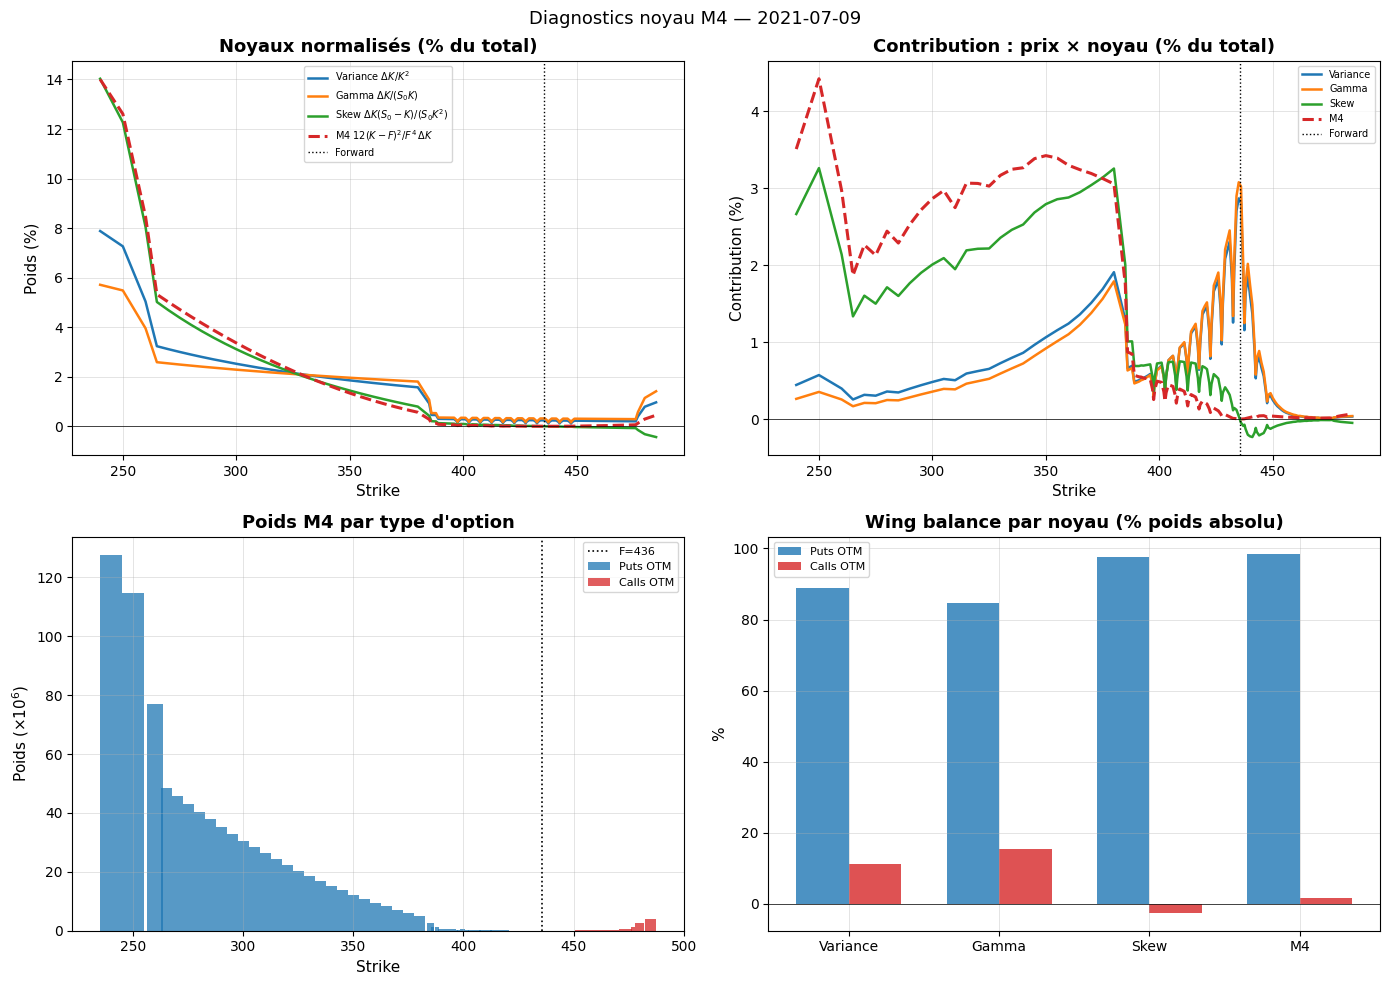

Part puts  : 98.3%
Part calls : 1.7%
Symétrie   : imparfaite (écart 96.6%)


In [15]:
# Noyau M4 : 12(K-F)^2/F^4 · deltaK
st     = kernel_df["strike"].to_numpy(dtype=float)
F      = fwd_gamma
dK_all = _compute_strike_widths(st)
w4_raw = 12 * (st - F)**2 / F**4 * dK_all
kernel_df["m4_kernel"] = w4_raw
# Normalisation (M4 toujours ≥ 0 → somme directe)
kernel_df["m4_kernel_norm"]  = w4_raw / w4_raw.sum() * 100
kernel_df["m4_contrib_norm"] = (w4_raw * kernel_df["otm_mid"]) / \
                               (w4_raw * kernel_df["otm_mid"]).sum() * 100
put_mask  = kernel_df["strike"] <  F
call_mask = kernel_df["strike"] >= F
# 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Diagnostics noyau M4 \u2014 {sample_date_gamma.date()}", fontsize=13)
# (0,0) Comparaison des 4 noyaux normalisés — lignes
ax = axes[0, 0]
ax.plot(st, kernel_df["var_kernel_norm"],   lw=1.8, label=r"Variance $\Delta K/K^2$")
ax.plot(st, kernel_df["gamma_kernel_norm"], lw=1.8, label=r"Gamma $\Delta K/(S_0 K)$")
ax.plot(st, kernel_df["skew_kernel_norm"],  lw=1.8, label=r"Skew $\Delta K(S_0-K)/(S_0 K^2)$")
ax.plot(st, kernel_df["m4_kernel_norm"],    lw=2.2, ls="--", color="tab:red",
        label=r"M4 $12(K-F)^2/F^4\,\Delta K$")
ax.axvline(F, color="black", ls=":", lw=1.0, label="Forward")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Noyaux normalis\u00e9s (% du total)")
ax.set_xlabel("Strike"); ax.set_ylabel("Poids (%)")
ax.legend(fontsize=7)
# (0,1) Contributions prix × noyau — lignes
ax = axes[0, 1]
ax.plot(st, kernel_df["var_contrib_norm"],   lw=1.8, label="Variance")
ax.plot(st, kernel_df["gamma_contrib_norm"], lw=1.8, label="Gamma")
ax.plot(st, kernel_df["skew_contrib_norm"],  lw=1.8, label="Skew")
ax.plot(st, kernel_df["m4_contrib_norm"],    lw=2.2, ls="--", color="tab:red", label="M4")
ax.axvline(F, color="black", ls=":", lw=1.0, label="Forward")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Contribution : prix \u00d7 noyau (% du total)")
ax.set_xlabel("Strike"); ax.set_ylabel("Contribution (%)")
ax.legend(fontsize=7)
# (1,0) Poids M4 par type d'option
plot_kernel_bars(axes[1, 0], st, w4_raw, dK_all, put_mask, F, "Poids M4 par type d'option")
# (1,1) Wing balance : part puts / calls pour chaque noyau (% poids absolu)
ax = axes[1, 1]
kernels_wb = {
    "Variance": kernel_df["var_kernel"].to_numpy(),
    "Gamma":    kernel_df["gamma_kernel"].to_numpy(),
    "Skew":     kernel_df["skew_kernel"].to_numpy(),
    "M4":       w4_raw,
}
labels = list(kernels_wb.keys())
put_pct  = [w[put_mask].sum()  / np.abs(w).sum() * 100 for w in kernels_wb.values()]
call_pct = [w[call_mask].sum() / np.abs(w).sum() * 100 for w in kernels_wb.values()]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, put_pct,  width, color="tab:blue", alpha=0.8, label="Puts OTM")
ax.bar(x + width/2, call_pct, width, color="tab:red",  alpha=0.8, label="Calls OTM")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Wing balance par noyau (% poids absolu)")
ax.set_ylabel("%"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
# Propriété clé : symétrie du noyau M4
put_w  = w4_raw[put_mask].sum()
call_w = w4_raw[call_mask].sum()
total  = w4_raw.sum()
print(f"Part puts  : {put_w/total*100:.1f}%")
print(f"Part calls : {call_w/total*100:.1f}%")
print(f"Sym\u00e9trie   : {'parfaite' if abs(put_w - call_w) / total < 0.05 else 'imparfaite'} "
      f"(\u00e9cart {abs(put_w - call_w)/total*100:.1f}%)")


<div style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Le diagnostic confirme une exposition M4 très "left-tail loaded", conforme au noyau théorique.**

Le noyau M4 $12(K-F)^2/F^4 \,\Delta K$ est minimal près du forward et croît quadratiquement dans les ailes. Sur la grille observée, la combinaison "noyau croissant en $|K-F|$" + "surface equity à skew négative (puts OTM chers)" concentre mécaniquement les poids effectifs sur l’aile gauche. Le panneau haut-gauche montre bien que M4 domine les autres noyaux dans les strikes put profonds.

**La contribution économique est gouvernée par le produit prix $\times$ poids, pas par le poids seul.**

Le panneau haut-droit montre que M4 sur-contribue sur $K \approx 245{-}260$, puis décroît rapidement en s’approchant de $F$. C’est exactement ce qu’on attend d’un contrat de queue : la masse de contribution vient des options qui portent l’information de stress extrême, pas du centre ATM. Autrement dit, le strike M4 est surtout un prix de "tail insurance" implicite.

**Implication directe pour le backtest.**

Un short M4 n’est pas un simple "short vol" : c’est un short prime de queue gauche. Le carry peut sembler régulier hors stress, mais le risque est concentré en épisodes rares et violents. Cette lecture est cohérente avec la concentration des poids, la forme des contributions, et la wing-balance presque entièrement orientée puts.

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## IV.2 - M4 Risk Premium : le marché sur-price-t-il les queues de distribution ?

La logique est la même que pour la variance et le skew : si le marché exige une compensation pour s'exposer au risque de queues épaisses, le moment d'ordre 4 implicite devrait être systématiquement supérieur au moment d'ordre 4 réalisé. L'écart constitue le **M4 Risk Premium**, et sa persistance justifie une position vendeuse de queue.

La définition du moment d'ordre 4 **réalisé** est moins immédiate que pour la variance. Contrairement à la variance réalisée — qui s'estime comme $\frac{252}{n}\sum r_i^2$, une somme sur le chemin — le payoff réalisé associé à la réplication Carr-Madan est un **payoff terminal unique** : $(S_{t+T}/S_t - 1)^4$, le rendement simple sur la période entière élevé à la quatrième puissance. Il n'existe pas de décomposition chemin-dépendante naturelle analogue à celle de la variance.

Cela a une conséquence pratique importante : chaque observation est basée sur un seul rendement, ce qui rend la série réalisée extrêmement volatile. Pour la rendre comparable à la série implicite, nous calculons une moyenne mobile du réalisé sur 63 jours de bourse, ce qui équivaut à lisser sur trois horizons de renouvellement successifs.

Le **M4 Risk Premium** est alors

$$\text{M4RP}(t) = M_4^{\text{impl}}(t) - \overline{M_4^{\text{real}}}(t)$$

Un M4RP positif signifie que le marché a sur-tarifé le risque de queues sur cet horizon : le vendeur de moment d'ordre 4 encaisse plus que ce que les queues réalisées ont coûté.

</div>

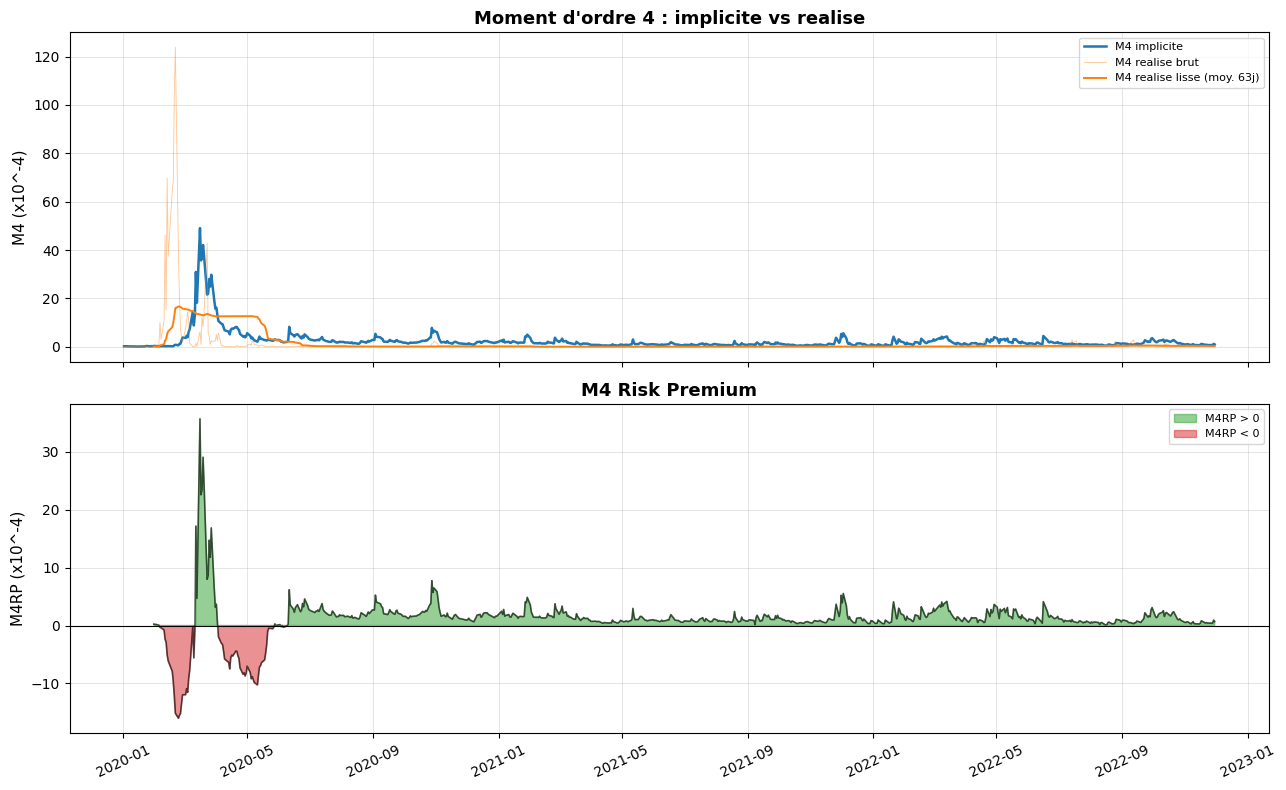

M4 implicite moyen  : 2.3835 x10^-4
M4 realise moyen    : 1.2165 x10^-4
M4RP moyen (lisse)  : 1.0318 x10^-4
% dates M4RP > 0    : 88.5%


In [16]:
m4_impl_series = (
    SwapSeriesCalculator.compute_m4_cm_series(df_spy, df_rates, dte_lo=21, dte_hi=35)
    [["date", "M4_CM"]]
    .rename(columns={"M4_CM": "m4_impl"})
    .sort_values("date")
)
prices = (
    df_spy[["date", "spot"]]
    .drop_duplicates("date")
    .sort_values("date")
    .set_index("date")["spot"]
)
ret_21d_fwd = prices.pct_change(periods=21).shift(-21)
m4_real_fwd = ret_21d_fwd ** 4
df_m4 = (
    m4_impl_series.set_index("date")
    .join(m4_real_fwd.rename("m4_real_fwd"), how="inner")
    .dropna()
)
df_m4["m4_real_smooth"] = df_m4["m4_real_fwd"].rolling(63, min_periods=21).mean()
df_m4["m4rp"] = df_m4["m4_impl"] - df_m4["m4_real_fwd"]
df_m4["m4rp_smooth"] = df_m4["m4_impl"] - df_m4["m4_real_smooth"]
scale = 1e4
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.plot(df_m4.index, df_m4["m4_impl"] * scale, lw=1.8, color="tab:blue", label="M4 implicite")
ax.plot(df_m4.index, df_m4["m4_real_fwd"] * scale, lw=0.6, color="tab:orange", alpha=0.45, label="M4 realise brut")
ax.plot(df_m4.index, df_m4["m4_real_smooth"] * scale, lw=1.4, color="tab:orange", label="M4 realise lisse (moy. 63j)")
ax.set_ylabel("M4 (x10^-4)")
ax.set_title("Moment d'ordre 4 : implicite vs realise")
ax.legend(fontsize=8)
ax = axes[1]
pos = df_m4["m4rp_smooth"] >= 0
ax.fill_between(df_m4.index, df_m4["m4rp_smooth"] * scale, 0, where=pos, color="tab:green", alpha=0.5, label="M4RP > 0")
ax.fill_between(df_m4.index, df_m4["m4rp_smooth"] * scale, 0, where=~pos, color="tab:red", alpha=0.5, label="M4RP < 0")
ax.plot(df_m4.index, df_m4["m4rp_smooth"] * scale, lw=1.2, color="black", alpha=0.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("M4RP (x10^-4)")
ax.set_title("M4 Risk Premium")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
print(f"M4 implicite moyen  : {df_m4['m4_impl'].mean() * scale:.4f} x10^-4")
print(f"M4 realise moyen    : {df_m4['m4_real_fwd'].mean() * scale:.4f} x10^-4")
print(f"M4RP moyen (lisse)  : {df_m4['m4rp_smooth'].mean() * scale:.4f} x10^-4")
print(f"% dates M4RP > 0    : {(df_m4['m4rp_smooth'] > 0).mean() * 100:.1f}%")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## IV.3 - Backtest d'un short M4 swap

Nous implémentons un short M4 swap delta-hedgé à rebalancement hebdomadaire. Le portefeuille répliquant est composé exclusivement d'options vanilles OTM pondérées par le noyau $12(K-F)^2/F^4$ : vendre ce portefeuille revient à encaisser la prime de moment d'ordre 4 implicite en s'exposant à un payoff négatif si les queues réalisées dépassent les queues anticipées.

La décomposition du P&L suit la même logique que pour les sections précédentes. Le P&L quotidien se décompose en gamma — la convexité encaissée ou payée au fil des mouvements du sous-jacent —, en theta — la décroissance temporelle des primes collectées —, et en vega — la sensibilité aux variations de volatilité implicite sur l'ensemble du smile. Pour un short M4, le theta est positif et le gamma est négatif : les grands mouvements coûtent, en particulier dans les deux ailes où le noyau quadratique concentre l'exposition. La comparaison avec le short variance et le short gamma permet d'isoler l'effet de cette concentration extrême sur le profil de risque de la stratégie.

</div>

100%|██████████| 794/794 [00:04<00:00, 183.03it/s]


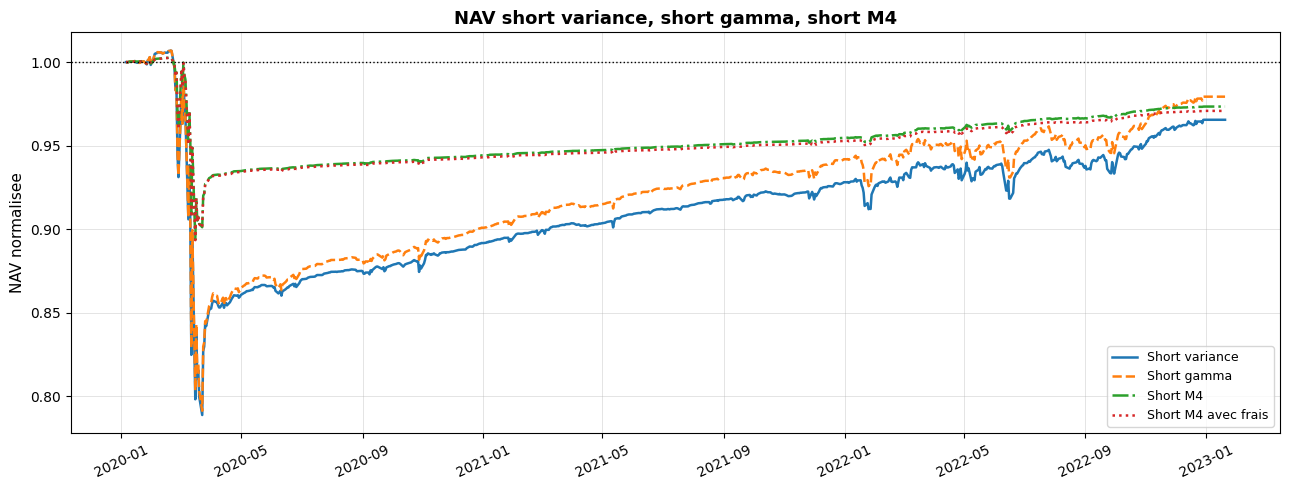

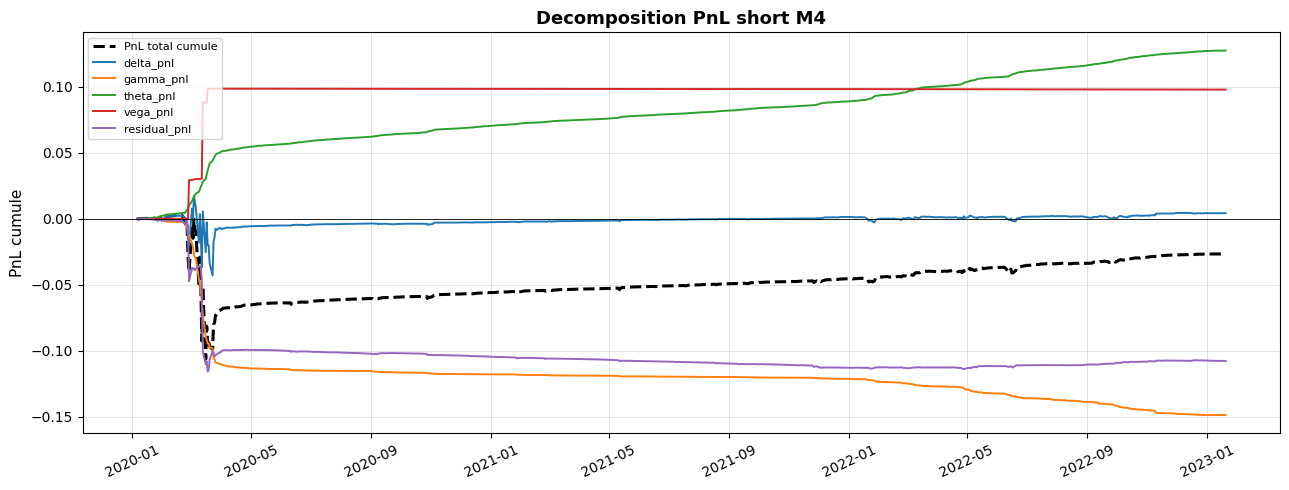

NAV finale sans frais      : 0.9734
NAV finale avec frais      : 0.9708
Perf totale sans frais     : -2.66%
Perf totale avec frais     : -2.92%
Max drawdown sans frais    : -10.9%
Max drawdown avec frais    : -10.9%
Impact frais (NAV)         : -0.0026 (0.27% de la NAV brute)


In [17]:
positions_m4 = M4SwapBuilder.build_positions(
    df_spy,
    weight=-1.0,
    day_to_expiry_target=21,
    rebal_week_day=[1],
    strike_spacing=2.0,
)
bt_m4 = PreloadedBacktester(positions_m4, df_spy)
bt_m4.compute_backtest()
bt_m4_nav = bt_m4.nav.copy()
bt_m4_pnl = bt_m4.pnl.copy()
bt_m4_net = PreloadedBacktesterBidAsk(positions_m4, df_spy)
bt_m4_net.compute_backtest()
bt_m4_nav_net = bt_m4_net.nav.copy()
bt_m4_pnl_net = bt_m4_net.pnl.copy()
required_nav = ["bt_nav", "bt_gamma_nav"]
missing = [x for x in required_nav if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")
common_idx = (
    bt_nav.index
    .intersection(bt_gamma_nav.index)
    .intersection(bt_m4_nav.index)
    .intersection(bt_m4_nav_net.index)
)
if len(common_idx) == 0:
    raise RuntimeError("No common dates between variance/gamma/M4 NAV series.")
nav_cmp = pd.DataFrame({
    "Short variance": bt_nav.loc[common_idx, "NAV"],
    "Short gamma": bt_gamma_nav.loc[common_idx, "NAV"],
    "Short M4": bt_m4_nav.loc[common_idx, "NAV"],
    "Short M4 avec frais": bt_m4_nav_net.loc[common_idx, "NAV"],
})
nav_cmp = nav_cmp / nav_cmp.iloc[0]
fig, ax = plt.subplots(figsize=(13, 5))
styles = {
    "Short variance": "-",
    "Short gamma": "--",
    "Short M4": "-.",
    "Short M4 avec frais": ":",
}
for col in nav_cmp.columns:
    ax.plot(nav_cmp.index, nav_cmp[col], lw=1.8, ls=styles[col], label=col)
ax.axhline(1.0, color="black", ls=":", lw=1.0)
ax.set_title("NAV short variance, short gamma, short M4")
ax.set_ylabel("NAV normalisee")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
greek_cols = [c for c in ["delta_pnl", "gamma_pnl", "theta_pnl", "vega_pnl", "residual_pnl"] if c in bt_m4_pnl.columns]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bt_m4_pnl.index, bt_m4_pnl["pnl"].cumsum(), lw=2.2, color="black", ls="--", label="PnL total cumule")
for col in greek_cols:
    ax.plot(bt_m4_pnl.index, bt_m4_pnl[col].cumsum(), lw=1.4, label=col)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Decomposition PnL short M4")
ax.set_ylabel("PnL cumule")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
nav_m4 = bt_m4_nav["NAV"].iloc[-1]
nav_m4_t = bt_m4_nav_net["NAV"].iloc[-1]
max_dd_m4 = (bt_m4_nav["NAV"] / bt_m4_nav["NAV"].cummax() - 1).min()
max_dd_m4_t = (bt_m4_nav_net["NAV"] / bt_m4_nav_net["NAV"].cummax() - 1).min()
fee_abs = nav_m4 - nav_m4_t
fee_pct = fee_abs / nav_m4 if nav_m4 != 0 else np.nan
print(f"NAV finale sans frais      : {nav_m4:.4f}")
print(f"NAV finale avec frais      : {nav_m4_t:.4f}")
print(f"Perf totale sans frais     : {nav_m4 - 1:+.2%}")
print(f"Perf totale avec frais     : {nav_m4_t - 1:+.2%}")
print(f"Max drawdown sans frais    : {max_dd_m4:.1%}")
print(f"Max drawdown avec frais    : {max_dd_m4_t:.1%}")
print(f"Impact frais (NAV)         : -{fee_abs:.4f} ({fee_pct:.2%} de la NAV brute)")


<div style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Récapitulatif Actes I–IV : hiérarchie des contrats de moments

Les six premiers actes ont construit une famille de contrats de moments : chacun réplique, via un portefeuille statique d'options OTM, une statistique précise de la distribution risk-neutre. Chaque étape déplace le risque plus loin dans les queues : la prime encaissée en régime calme est plus élevée, mais les pertes en crise sont plus sévères et plus difficiles à arbitrer.

<table style="width:100%; border-collapse:collapse; font-size:0.88em; margin-top:12px; color:#dbeafe;">
  <thead>
    <tr style="border-bottom: 2px solid #60a5fa;">
      <th style="text-align:left;   padding:6px 10px;">Produit</th>
      <th style="text-align:center; padding:6px 10px;">Noyau w(K)</th>
      <th style="text-align:center; padding:6px 10px;">Ce qu'il capture</th>
      <th style="text-align:center; padding:6px 10px;">Symétrie</th>
      <th style="text-align:center; padding:6px 10px;">Prime de risque</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid rgba(96,165,250,0.3);">
      <td style="padding:6px 10px;">Variance swap</td>
      <td style="text-align:center; padding:6px 10px; font-family:monospace;">ΔK / K²</td>
      <td style="text-align:center; padding:6px 10px;">Variance globale M₂</td>
      <td style="text-align:center; padding:6px 10px;">Asymétrique (↑ puts)</td>
      <td style="text-align:center; padding:6px 10px;">VRP</td>
    </tr>
    <tr style="border-bottom: 1px solid rgba(96,165,250,0.3);">
      <td style="padding:6px 10px;">Gamma swap</td>
      <td style="text-align:center; padding:6px 10px; font-family:monospace;">ΔK / (S₀K)</td>
      <td style="text-align:center; padding:6px 10px;">Variance pondérée par Sₜ/S₀</td>
      <td style="text-align:center; padding:6px 10px;">Asymétrique (atténuée)</td>
      <td style="text-align:center; padding:6px 10px;">—</td>
    </tr>
    <tr style="border-bottom: 1px solid rgba(96,165,250,0.3);">
      <td style="padding:6px 10px;">Skew swap</td>
      <td style="text-align:center; padding:6px 10px; font-family:monospace;">ΔK(S₀−K) / (S₀K²)</td>
      <td style="text-align:center; padding:6px 10px;">Asymétrie downside</td>
      <td style="text-align:center; padding:6px 10px;">Change de signe en F</td>
      <td style="text-align:center; padding:6px 10px;">SRP</td>
    </tr>
    <tr>
      <td style="padding:6px 10px;">M4 swap</td>
      <td style="text-align:center; padding:6px 10px; font-family:monospace;">12(K−F)² / F⁴ · ΔK</td>
      <td style="text-align:center; padding:6px 10px;">Moment d'ordre 4 M₄</td>
      <td style="text-align:center; padding:6px 10px;">Symétrique autour de F</td>
      <td style="text-align:center; padding:6px 10px;">M4RP</td>
    </tr>
  </tbody>
</table>

</div>

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte V — Carry de volatilité : le short strangle delta-hedgé

La stratégie de carry repose sur la vente simultanée d'un put OTM et d'un call OTM de même maturité , un **short strangle** , couverte dynamiquement en delta au quotidien. Le choix des strikes OTM, typiquement autour d'un delta de 15 à 20% en valeur absolue, maximise le ratio theta/gamma : les options courtes échéance concentrent leur décroissance temporelle dans les derniers jours de vie, tandis qu'une position OTM limite l'exposition au gamma près du spot courant.

Le delta-hedging neutralise l'exposition directionnelle de premier ordre, de sorte que le P&L instantané d'une position delta-hedgée s'écrit

$$dP \approx \Theta\,dt + \frac{1}{2}\,\Gamma\,(dS)^2 + \nu\,d\sigma$$

Le **theta** $\Theta > 0$ représente le gain quotidien de décroissance temporelle : le vendeur encaisse les primes au fil du temps. Le **gamma** $\Gamma < 0$ représente le coût des ajustements de couverture : tout mouvement du sous-jacent génère une perte proportionnelle au carré du déplacement. En notation continue, $(dS)^2 = \sigma_R^2 S^2\,dt$, ce qui permet d'écrire le P&L différentiel comme

$$dP \approx \frac{1}{2}\,\Gamma S^2\,(\sigma_{\text{impl}}^2 - \sigma_R^2)\,dt + \nu\,d\sigma$$

car pour une option courte échéance, $\Theta \approx -\frac{1}{2}\,\Gamma S^2\,\sigma_{\text{impl}}^2$. Le carry est donc fondamentalement un pari sur le **variance risk premium** : la stratégie est profitable tant que la volatilité implicite dépasse la volatilité réalisée. La composante **vega** $\nu < 0$ introduit un risque : une hausse brutale de la surface de volatilité entre l'initiation et l'expiration génère une perte latente même si le strangle expire finalement hors de la monnaie. C'est le risque de vol of vol distinct du gamma, qui est un coût de réalisation, le vega est un coût de prix de marché.


</div>

c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volume"] = df["volume"].fillna(0)
c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_option[c] = np.where(
c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

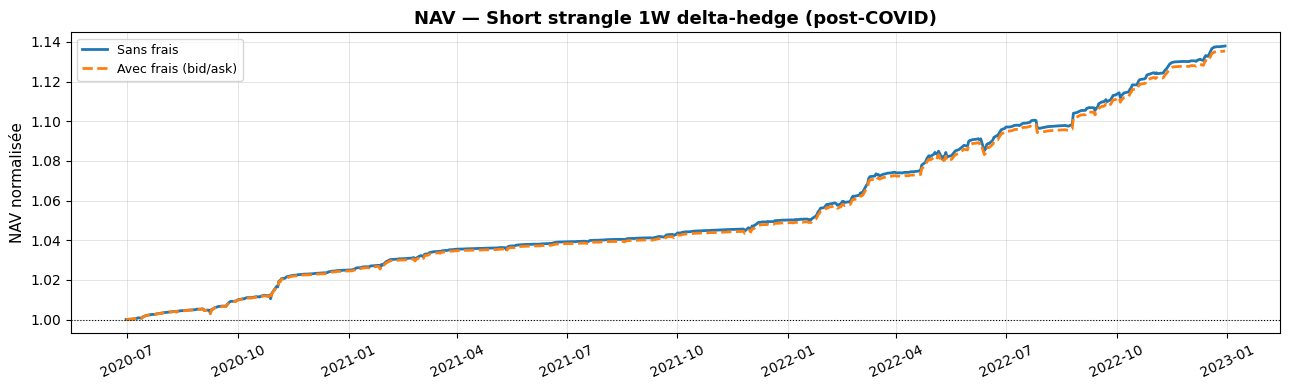

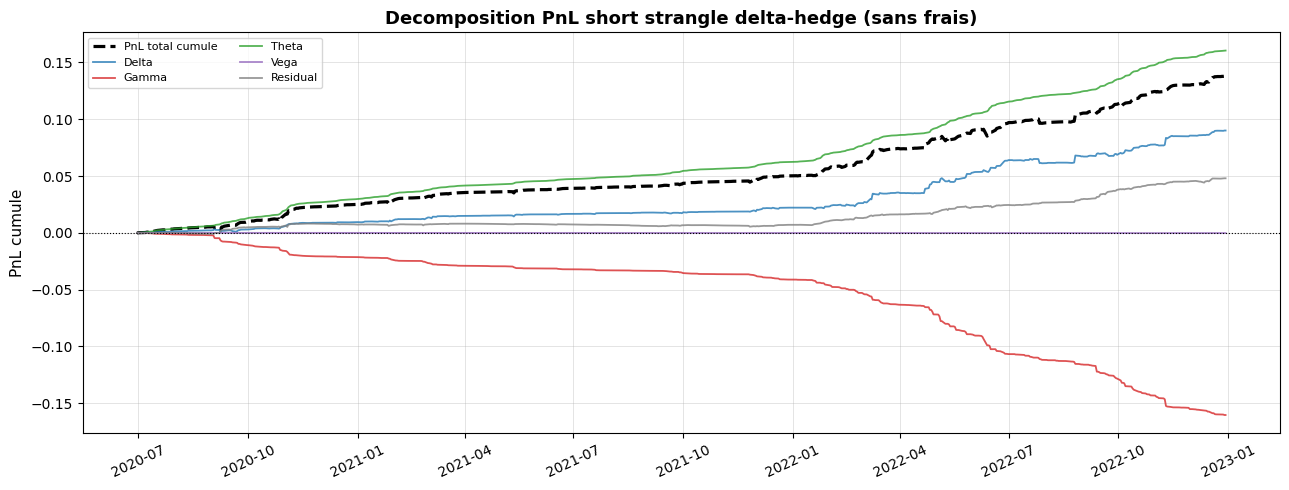

NAV finale sans frais      : 1.1379
NAV finale avec frais      : 1.1354
Perf totale sans frais     : +13.79%
Perf totale avec frais     : +13.54%
Max drawdown sans frais    : -0.6%
Max drawdown avec frais    : -0.6%
Impact frais (NAV)         : -0.0025 (0.22% de la NAV brute)


In [18]:
# Post-COVID window
START_DATE = max(df_spy["date"].min(), pd.Timestamp("2020-07-01"))
END_DATE   = df_spy["date"].max()
carry_trades = DeltaHedgedOptionTrade.generate_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)
# Backtests
bt_carry       = StrategyBacktester(carry_trades).compute_backtest()
bt_carry_tcost = BacktesterBidAskFromData(carry_trades).compute_backtest()
carry_nav      = bt_carry.nav["NAV"].copy()
carry_pnl      = bt_carry.pnl.copy()
carry_nav_tcost = bt_carry_tcost.nav["NAV"].copy()
# Figure 1 : NAV comparée
common_idx  = carry_nav.index.intersection(carry_nav_tcost.index)
nav_norm    = carry_nav.reindex(common_idx) / carry_nav.reindex(common_idx).iloc[0]
nav_norm_tc = carry_nav_tcost.reindex(common_idx) / carry_nav_tcost.reindex(common_idx).iloc[0]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(nav_norm.index,    nav_norm.values,    lw=2.0, color="tab:blue",   label="Sans frais")
ax.plot(nav_norm_tc.index, nav_norm_tc.values, lw=2.0, color="tab:orange", ls="--", label="Avec frais (bid/ask)")
ax.axhline(1.0, color="black", ls=":", lw=0.8)
ax.set_title("NAV — Short strangle 1W delta-hedge (post-COVID)")
ax.set_ylabel("NAV normalisée")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
# Figure 2 : Décomposition P&L (sans frais)
greek_cols = ["delta_pnl", "gamma_pnl", "theta_pnl", "vega_pnl", "residual_pnl"]
available  = [c for c in greek_cols if c in carry_pnl.columns]
colors = {
    "delta_pnl":    "tab:blue",
    "gamma_pnl":    "tab:red",
    "theta_pnl":    "tab:green",
    "vega_pnl":     "tab:purple",
    "residual_pnl": "tab:gray",
}
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(carry_pnl.index, carry_pnl["pnl"].cumsum(), lw=2.3, color="black", ls="--", label="PnL total cumule")
for c in available:
    ax.plot(carry_pnl.index, carry_pnl[c].cumsum(), lw=1.3, color=colors[c], alpha=0.8,
            label=c.replace("_pnl", "").title())
ax.axhline(0, color="black", ls=":", lw=0.8)
ax.set_title("Decomposition PnL short strangle delta-hedge (sans frais)")
ax.set_ylabel("PnL cumule")
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
# Métriques
nav_c      = carry_nav.iloc[-1]
nav_c_t    = carry_nav_tcost.iloc[-1]
max_dd_c   = (carry_nav / carry_nav.cummax() - 1).min()
max_dd_c_t = (carry_nav_tcost / carry_nav_tcost.cummax() - 1).min()
fee_abs    = nav_c - nav_c_t
fee_pct    = fee_abs / nav_c if nav_c != 0 else float("nan")
print(f"NAV finale sans frais      : {nav_c:.4f}")
print(f"NAV finale avec frais      : {nav_c_t:.4f}")
print(f"Perf totale sans frais     : {nav_c - 1:+.2%}")
print(f"Perf totale avec frais     : {nav_c_t - 1:+.2%}")
print(f"Max drawdown sans frais    : {max_dd_c:.1%}")
print(f"Max drawdown avec frais    : {max_dd_c_t:.1%}")
print(f"Impact frais (NAV)         : -{fee_abs:.4f} ({fee_pct:.2%} de la NAV brute)")

<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## V.2 - Carry augmenté d'un overlay de moment

Le short strangle delta-hedgé est structurellement court sur l'ensemble des moments de la distribution : il vend de la variance, du skew et de l'épaisseur des queues simultanément, sans distinguer la source de la prime encaissée. L'idée de l'overlay est d'ajouter sélectivement une position longue sur un contrat de moment spécifique — variance, gamma, skew ou M4 — afin d'isoler l'exposition que l'on souhaite conserver et de racheter celle que l'on souhaite neutraliser.

Le portefeuille combiné alloue une fraction $\alpha$ à l'overlay et $(1-\alpha)$ au carry. Dans cette version, la combinaison est faite  : chaque jambe conserve son amplitude naturelle de rendement. Le rendement total s'écrit

$$r_{\text{total}} = (1-\alpha)\cdot r_{\text{carry}} + \alpha\cdot r_{\text{overlay}}$$

En régime calme, l'overlay coûte du portage : acheter un swap de moment revient à payer une prime implicite supérieure au réalisé — c'est exactement la prime de risque documentée dans les actes précédents. En revanche, lors d'un choc, la position longue sur le moment correspondant compense partiellement les pertes du carry, qui est exposé négativement à ce même moment. La question empirique est donc de savoir si cette assurance est suffisamment bon marché sur longue période pour améliorer le profil risque-rendement du portefeuille — en réduisant le drawdown maximal sans trop amputer le Sharpe en régime calme.

</div>


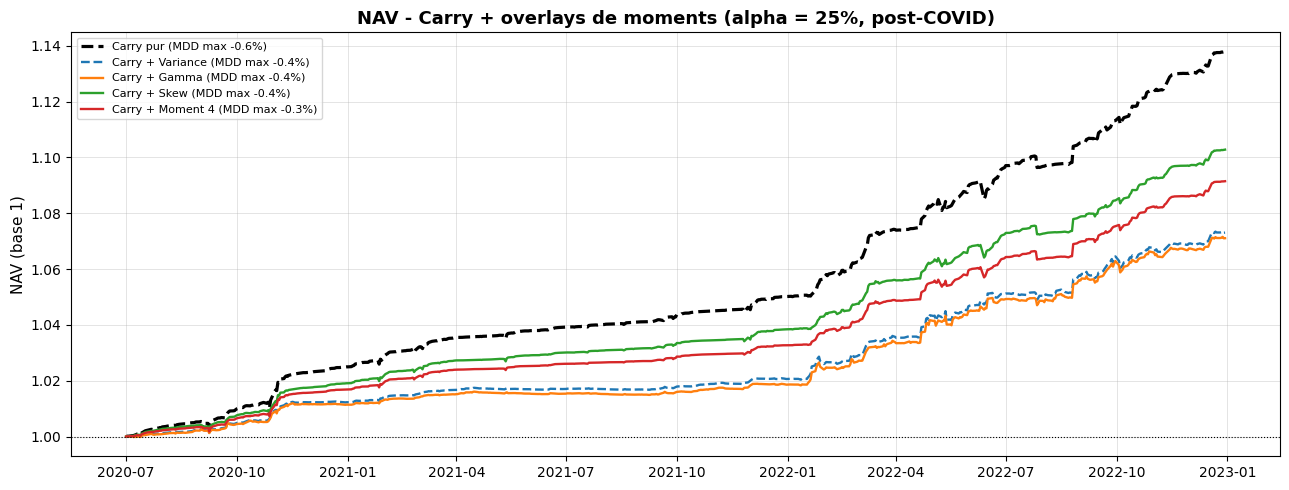

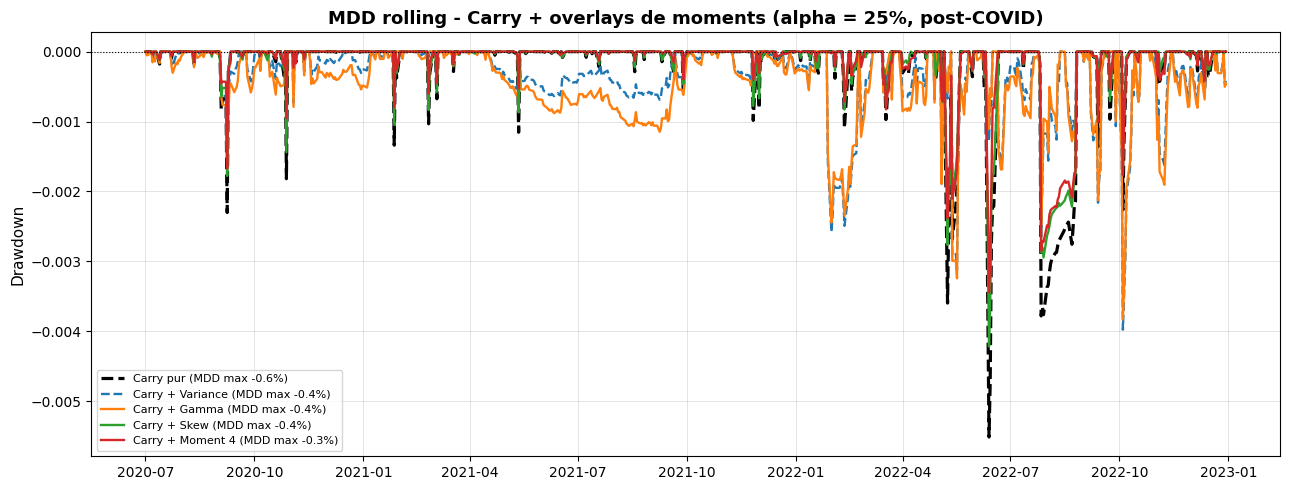

Strategie               NAV finale   Perf totale     MDD max
Carry pur                   1.1379        13.79%       -0.6%
Carry + Variance            1.0731         7.31%       -0.4%
Carry + Gamma               1.0711         7.11%       -0.4%
Carry + Skew                1.1028        10.28%       -0.4%
Carry + Moment 4            1.0915         9.15%       -0.3%


In [19]:
# -- Reuse previously computed backtests to avoid duplicate runs --
required_objs = ["bt_carry", "bt_nav", "bt_gamma_nav", "nav_skew", "bt_m4"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")

# -- Daily returns --
carry_ret      = bt_carry.nav["NAV"].pct_change().dropna()
long_var_ret   = -bt_nav["NAV"].pct_change().dropna()
long_gamma_ret = -bt_gamma_nav["NAV"].pct_change().dropna()
long_skew_ret  = -nav_skew.pct_change().dropna()
long_m4_ret    = -bt_m4.nav["NAV"].pct_change().dropna()

# -- Post-COVID sample --
DATE_CUT = pd.Timestamp("2020-07-01")
carry_ret      = carry_ret.loc[carry_ret.index >= DATE_CUT]
long_var_ret   = long_var_ret.loc[long_var_ret.index >= DATE_CUT]
long_gamma_ret = long_gamma_ret.loc[long_gamma_ret.index >= DATE_CUT]
long_skew_ret  = long_skew_ret.loc[long_skew_ret.index >= DATE_CUT]
long_m4_ret    = long_m4_ret.loc[long_m4_ret.index >= DATE_CUT]

overlays = {
    "Variance": long_var_ret,
    "Gamma": long_gamma_ret,
    "Skew": long_skew_ret,
    "Moment 4": long_m4_ret,
}

alpha = 0.25
portfolios = {}

for name, ov in overlays.items():
    common = carry_ret.index.intersection(ov.index)
    c = carry_ret.reindex(common).dropna()
    o = ov.reindex(common).dropna()
    common = c.index.intersection(o.index)
    c = c.reindex(common)
    o = o.reindex(common)

    ret_port = (1 - alpha) * c + alpha * o
    portfolios[name] = {"ret": ret_port.dropna()}

# -- Align all dates --
common_all = carry_ret.index
for d in portfolios.values():
    common_all = common_all.intersection(d["ret"].index)

# -- Build NAV series --
nav_c = (1 + carry_ret.reindex(common_all)).cumprod()
nav_c = nav_c / nav_c.iloc[0]

nav_ports = {}
for name, d in portfolios.items():
    nav = (1 + d["ret"].reindex(common_all)).cumprod()
    nav_ports[name] = nav / nav.iloc[0]

# -- Rolling DD and max MDD --
dd_c = nav_c / nav_c.cummax() - 1.0
mdd_c = dd_c.min()

dd_ports = {}
mdd_ports = {}
for name, nav in nav_ports.items():
    dd = nav / nav.cummax() - 1.0
    dd_ports[name] = dd
    mdd_ports[name] = dd.min()

colors = {
    "Variance": "tab:blue",
    "Gamma": "tab:orange",
    "Skew": "tab:green",
    "Moment 4": "tab:red",
}

# Plot 1: NAV
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    nav_c.index, nav_c,
    lw=2.3, color="black", ls="--",
    label=f"Carry pur (MDD max {mdd_c:.1%})"
)

for name in ["Variance", "Gamma", "Skew", "Moment 4"]:
    ls = "--" if name == "Variance" else "-"
    ax.plot(
        nav_ports[name].index,
        nav_ports[name],
        lw=1.7,
        color=colors[name],
        ls=ls,
        label=f"Carry + {name} (MDD max {mdd_ports[name]:.1%})"
    )

ax.axhline(1.0, color="black", ls=":", lw=0.8)
ax.set_title(f"NAV - Carry + overlays de moments (alpha = {alpha:.0%}, post-COVID)")
ax.set_ylabel("NAV (base 1)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot 2: Rolling MDD
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    dd_c.index, dd_c,
    lw=2.3, color="black", ls="--",
    label=f"Carry pur (MDD max {mdd_c:.1%})"
)

for name in ["Variance", "Gamma", "Skew", "Moment 4"]:
    ls = "--" if name == "Variance" else "-"
    ax.plot(
        dd_ports[name].index,
        dd_ports[name],
        lw=1.7,
        color=colors[name],
        ls=ls,
        label=f"Carry + {name} (MDD max {mdd_ports[name]:.1%})"
    )

ax.axhline(0.0, color="black", ls=":", lw=0.8)
ax.set_title(f"MDD rolling - Carry + overlays de moments (alpha = {alpha:.0%}, post-COVID)")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# -- Print NAV finale + perf totale --
rows = [("Carry pur", nav_c)]
rows += [(f"Carry + {name}", nav_ports[name]) for name in ["Variance", "Gamma", "Skew", "Moment 4"]]

print(f"{'Strategie':22s}  {'NAV finale':>10s}  {'Perf totale':>12s}  {'MDD max':>10s}")
for label, nav in rows:
    nav_final = nav.iloc[-1]
    perf_tot = nav_final - 1.0
    mdd_max = (nav / nav.cummax() - 1.0).min()
    print(f"{label:22s}  {nav_final:10.4f}  {perf_tot:12.2%}  {mdd_max:10.1%}")


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## Acte VI — Analyse de portefeuille : diversification ou hedging ?

## VI.1 - Période Hors COVID
Sur la période **hors COVID**, nous évaluons la relation entre le carry et chaque overlay via la corrélation **globale** :

$$
\rho = \mathrm{Corr}(r_{\text{carry}},\, r_{\text{overlay}})
$$

qui décrit le co-mouvement moyen sur l'ensemble de la période.

| Condition | Lecture portefeuille | Verdict |
|---|---|---|
| $\rho < -0.30$ | l'overlay compense les drawdowns du carry | **Hedge** |
| $\rho <= 0$ | faible dépendance en moyenne | **Diversification** |
| $\rho > +0.10$ | l'overlay perd avec le carry | **Redondant** |
| sinon | signal mixte, dépend du coût de portage | **Ambigu** |

</div>


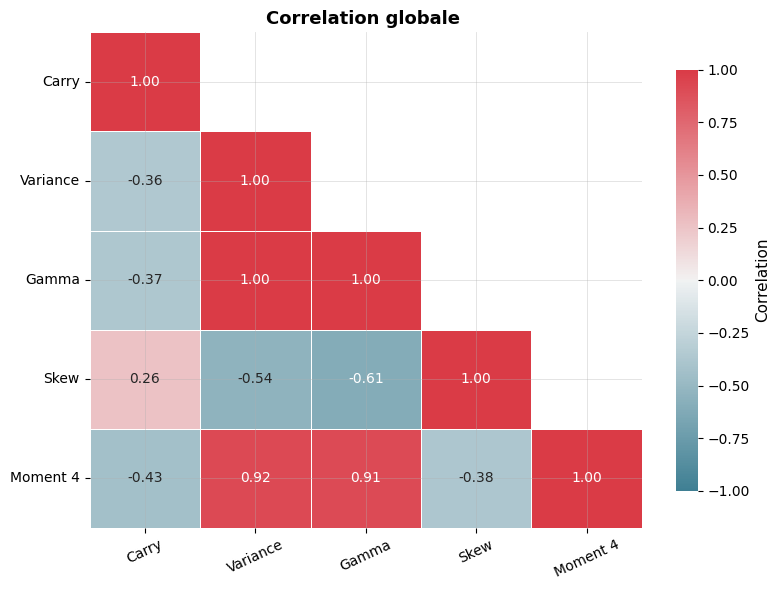

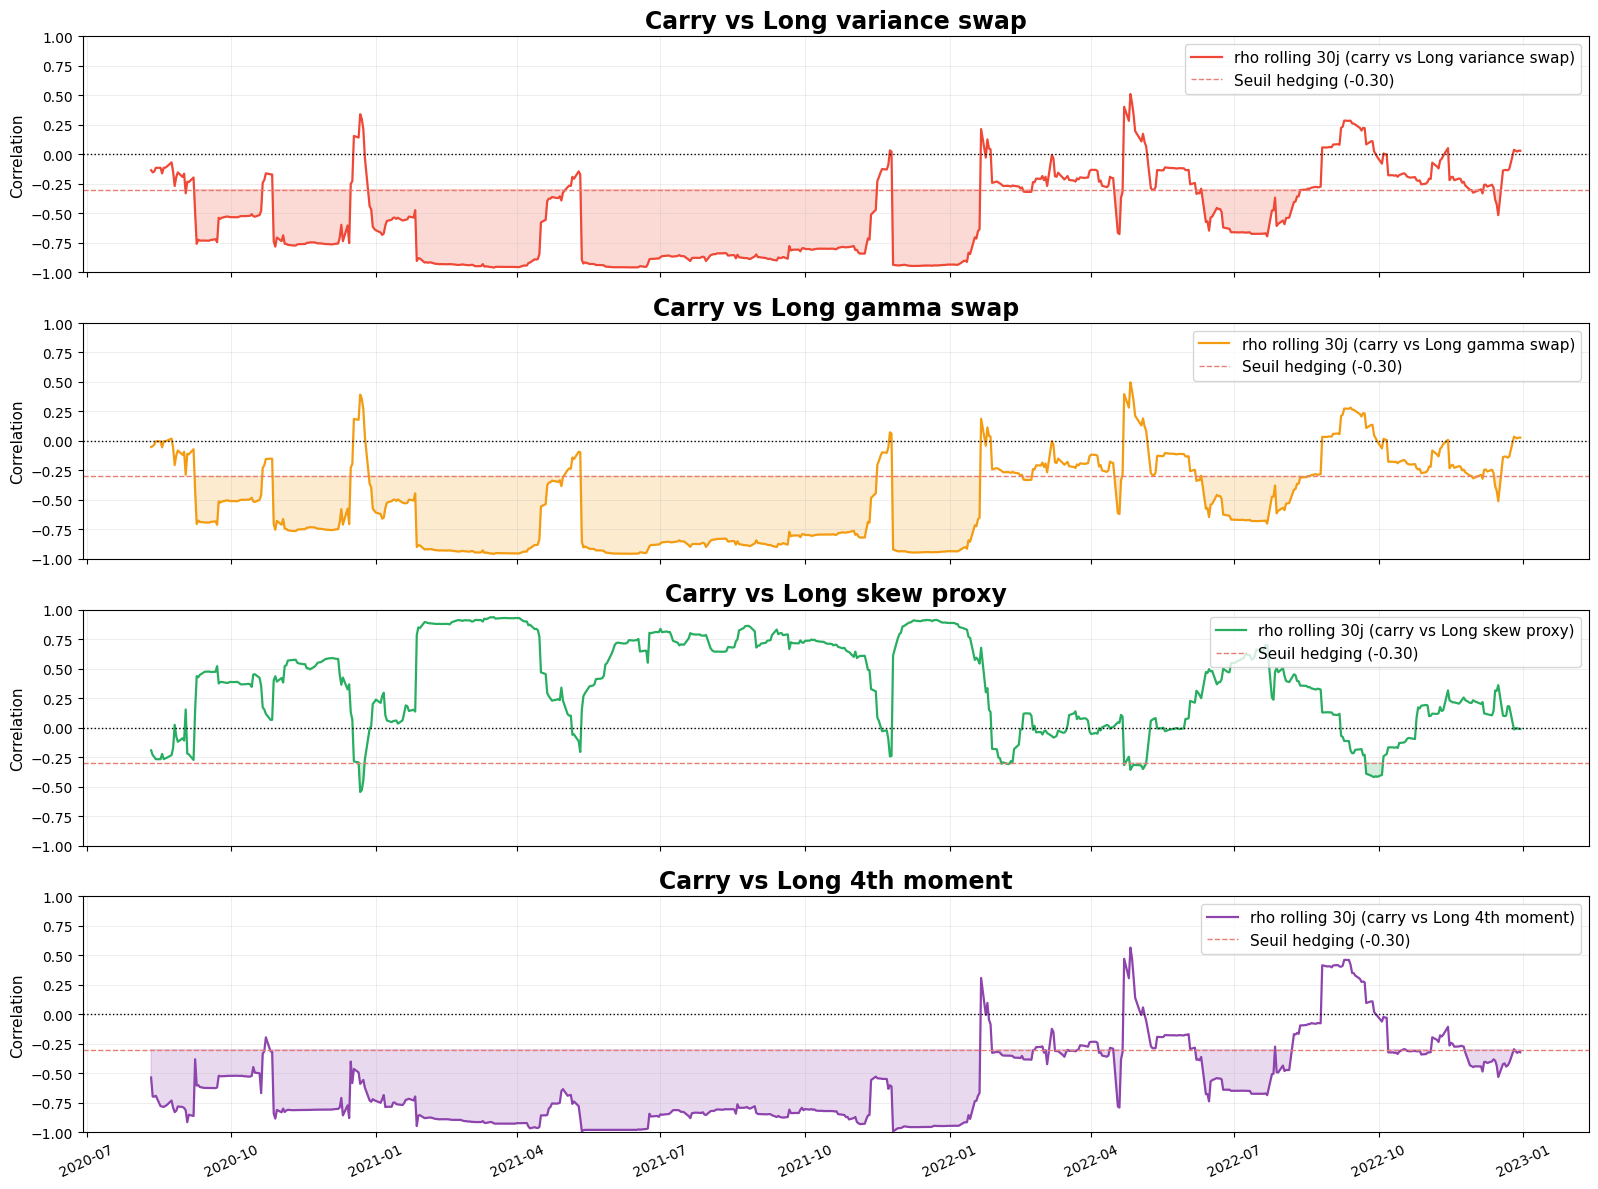

In [20]:
required_objs = ["bt_carry", "bt_nav", "bt_gamma_nav", "nav_skew", "bt_m4"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")
# 1) Returns des strategies
carry_ret = bt_carry.nav["NAV"].pct_change().dropna()
overlays_raw = {
    "Variance": -bt_nav["NAV"].pct_change().dropna(),
    "Gamma":    -bt_gamma_nav["NAV"].pct_change().dropna(),
    "Skew":     -nav_skew.pct_change().dropna(),
    "Moment 4": -bt_m4.nav["NAV"].pct_change().dropna(),
}
# 2) Hors COVID (post-juin 2020)
DATE_CUT = pd.Timestamp("2020-07-01")
carry_ret = carry_ret.loc[carry_ret.index >= DATE_CUT]
overlays_raw = {k: v.loc[v.index >= DATE_CUT] for k, v in overlays_raw.items()}
# 3) overlays -> carry
df = pd.DataFrame({"carry": carry_ret})
for name, ov in overlays_raw.items():
    df[name] = ov.reindex(df.index)
df = df.dropna()
# 4) Correlation globale
cols = ["carry", "Variance", "Gamma", "Skew", "Moment 4"]
labels = ["Carry", "Variance", "Gamma", "Skew", "Moment 4"]
corr_global = df[cols].corr()
corr_global.index = labels
corr_global.columns = labels
# 5) Plot: matrice triangulaire
mask_tri = np.triu(np.ones_like(corr_global, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 10, as_cmap=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_global,
    mask=mask_tri,
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation globale ")
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()
# 6) Rolling correlations — 4 panneaux 
ROLL_WIN = 30
THRESH = -0.30
carry_ret_roll = bt_carry.nav["NAV"].pct_change().dropna()
long_var   = -bt_nav["NAV"].pct_change().dropna()
long_gamma = -bt_gamma_nav["NAV"].pct_change().dropna()
long_skew  = -nav_skew.pct_change().dropna()
long_m4    = -bt_m4.nav["NAV"].pct_change().dropna()
series_map = {
    "Carry vs Long variance swap": long_var,
    "Carry vs Long gamma swap":    long_gamma,
    "Carry vs Long skew proxy":    long_skew,
    "Carry vs Long 4th moment":    long_m4,
}
colors = {
    "Carry vs Long variance swap": "#ef4836",
    "Carry vs Long gamma swap":    "#f39c12",
    "Carry vs Long skew proxy":    "#27ae60",
    "Carry vs Long 4th moment":    "#8e44ad",
}
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True, sharey=True)
for ax, (title, ov) in zip(axes, series_map.items()):
    tmp = pd.concat([carry_ret_roll.rename("carry"), ov.rename("overlay")], axis=1).dropna()
    tmp = tmp.loc[tmp.index >= DATE_CUT].copy()
    rho = tmp["carry"].rolling(ROLL_WIN, min_periods=ROLL_WIN).corr(tmp["overlay"])
    ax.plot(
        rho.index, rho.values, lw=1.6, color=colors[title],
        label=f"rho rolling {ROLL_WIN}j (carry vs {title.split(' vs ')[1]})"
    )
    # zone coloriee entre la courbe rho et le seuil
    mask_hedge = rho <= THRESH
    ax.fill_between(
        rho.index,
        rho.values,
        THRESH,
        where=mask_hedge,
        color=colors[title],
        alpha=0.20,
        interpolate=True,
    )
    ax.axhline(0.0, color="black", ls=":", lw=1.0)
    ax.axhline(THRESH, color="#e67e73", ls="--", lw=1.0, label=f"Seuil hedging ({THRESH:.2f})")
    ax.set_ylim(-1.0, 1.0)
    ax.set_ylabel("Correlation")
    ax.set_title(title, fontsize=17, weight="bold")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=11)
axes[-1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Hors COVID, la couverture est déjà présente pour Variance/Gamma/M4, mais pas pour Skew.**

La matrice globale montre une anticorrélation nette entre carry et overlays longs de niveau/queues :
$\rho(\mathrm{Carry},\mathrm{Variance})\approx-0.36$,
$\rho(\mathrm{Carry},\mathrm{Gamma})\approx-0.37$,
$\rho(\mathrm{Carry},\mathrm{M4})\approx-0.43$.
Donc même en régime normalisé post-COVID, ces overlays jouent déjà un rôle de hedge moyen.  
À l’inverse, $\rho(\mathrm{Carry},\mathrm{Skew})\approx+0.26$ : le skew proxy co-mouve plutôt avec le carry en moyenne.

**La corrélation rolling confirme une protection conditionnelle et hétérogène.**

Les fenêtres $\rho\le -0.30$ apparaissent fréquemment pour Variance et Gamma (profils quasi jumeaux), et de façon souvent plus persistante pour M4, ce qui traduit une meilleure sensibilité aux épisodes de queue/risk-off.  
Le Skew ne passe sous $-0.30$ que de manière sporadique : il est moins fiable comme couverture tactique du carry.  
Conclusion portefeuille : Variance/Gamma sont des hedges proches , M4 apporte la protection la plus "tail-driven", Skew sert davantage d’exposition spécifique de pente que de hedge robuste.

</div>


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(30,58,138,0.13), rgba(37,99,235,0.08)); border-left: 4px solid #60a5fa; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #dbeafe;">

## VI.2 - Période COVID

<div>

c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["volume"] = df["volume"].fillna(0)
c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_option[c] = np.where(
c:\Users\Fayca\Documents\VSCode\Vol_Trade\investment_lab\data\option_db.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

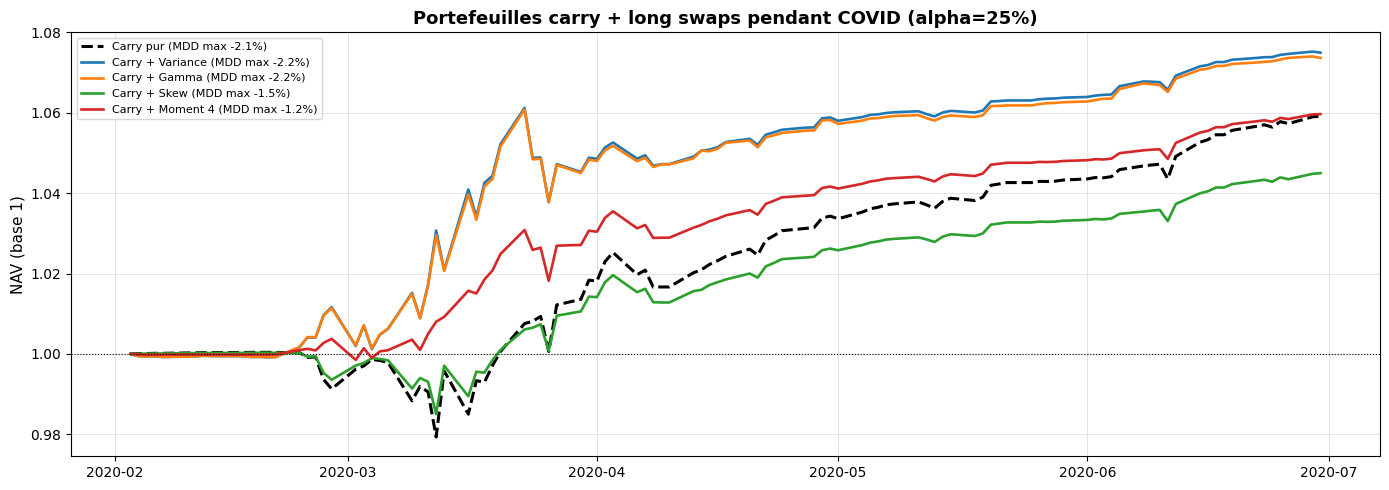

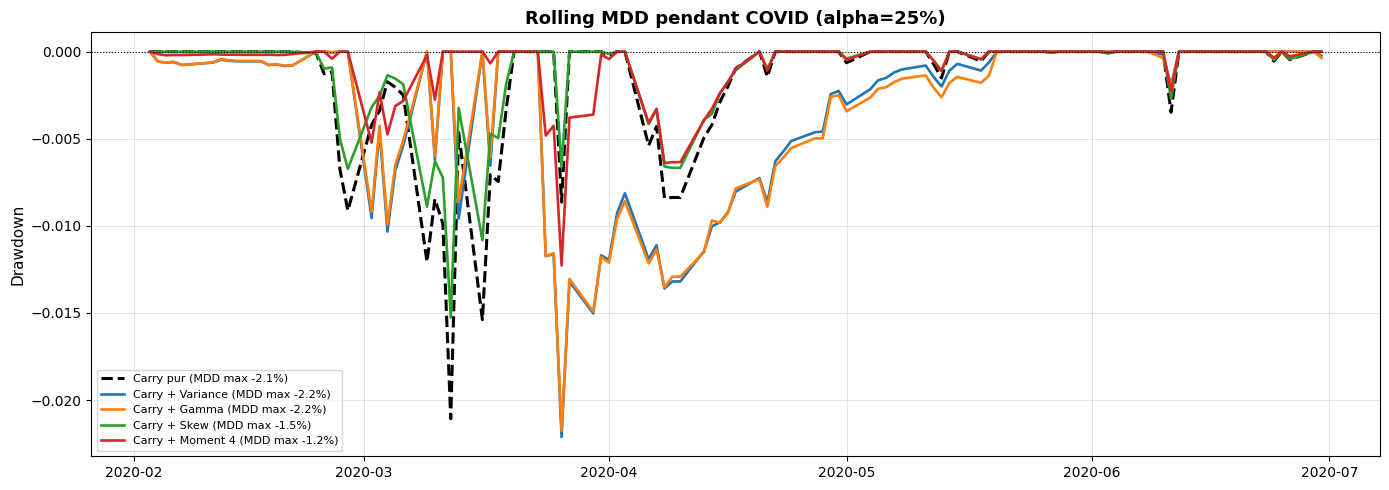

MDD COVID par portefeuille:
  Carry + Variance       -2.2%
  Carry + Gamma          -2.2%
  Carry pur              -2.1%
  Carry + Skew           -1.5%
  Carry + Moment 4       -1.2%

NAV finale et performance totale:
Strategie               NAV finale   Perf totale
Carry pur                   1.0591         5.91%
Carry + Variance            1.0750         7.50%
Carry + Gamma               1.0736         7.36%
Carry + Skew                1.0450         4.50%
Carry + Moment 4            1.0597         5.97%


In [21]:
COVID_START = pd.Timestamp("2020-02-01")
COVID_END = pd.Timestamp("2020-06-30")
ALPHA = 0.25

if "bt_carry_covid" not in globals():
    carry_trades_covid = DeltaHedgedOptionTrade.generate_trades(
        start_date=max(df_spy["date"].min(), COVID_START),
        end_date=min(df_spy["date"].max(), COVID_END),
        tickers="SPY",
        legs=option_strategies.SHORT_1W_STRANGLE_95_105,
        cost_neutral=False,
    )
    bt_carry_covid = StrategyBacktester(carry_trades_covid).compute_backtest()

required_objs = ["bt_carry_covid", "bt_nav", "bt_gamma_nav", "nav_skew", "bt_m4"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")

carry_ret = bt_carry_covid.nav["NAV"].pct_change().dropna()
long_var_ret = -bt_nav["NAV"].pct_change().dropna()
long_gamma_ret = -bt_gamma_nav["NAV"].pct_change().dropna()
long_skew_ret = -nav_skew.pct_change().dropna()
long_m4_ret = -bt_m4.nav["NAV"].pct_change().dropna()

carry_ret = carry_ret.loc[(carry_ret.index >= COVID_START) & (carry_ret.index <= COVID_END)]
long_var_ret = long_var_ret.loc[(long_var_ret.index >= COVID_START) & (long_var_ret.index <= COVID_END)]
long_gamma_ret = long_gamma_ret.loc[(long_gamma_ret.index >= COVID_START) & (long_gamma_ret.index <= COVID_END)]
long_skew_ret = long_skew_ret.loc[(long_skew_ret.index >= COVID_START) & (long_skew_ret.index <= COVID_END)]
long_m4_ret = long_m4_ret.loc[(long_m4_ret.index >= COVID_START) & (long_m4_ret.index <= COVID_END)]

overlays = {
    "Variance": long_var_ret,
    "Gamma": long_gamma_ret,
    "Skew": long_skew_ret,
    "Moment 4": long_m4_ret,
}

port_rets = {"Carry pur": carry_ret.copy()}

for name, ov in overlays.items():
    common = carry_ret.index.intersection(ov.index)
    c = carry_ret.reindex(common).dropna()
    o = ov.reindex(common).dropna()
    common = c.index.intersection(o.index)
    c = c.reindex(common)
    o = o.reindex(common)

    combined = (1 - ALPHA) * c + ALPHA * o
    port_rets[f"Carry + {name}"] = combined

df_ports = pd.DataFrame(port_rets).dropna(how="any")
if df_ports.empty or len(df_ports) < 2:
    raise RuntimeError("Pas assez de points communs pour tracer les portefeuilles pendant COVID.")

nav_ports = (1 + df_ports).cumprod()
nav_ports = nav_ports / nav_ports.iloc[0]

mdd_ports = (nav_ports / nav_ports.cummax() - 1).min().sort_values()
rolling_mdd = nav_ports / nav_ports.cummax() - 1

colors = {
    "Carry pur": "black",
    "Carry + Variance": "tab:blue",
    "Carry + Gamma": "tab:orange",
    "Carry + Skew": "tab:green",
    "Carry + Moment 4": "tab:red",
}

fig, ax = plt.subplots(figsize=(14, 5))
for col in nav_ports.columns:
    ax.plot(
        nav_ports.index,
        nav_ports[col],
        lw=2.2 if col == "Carry pur" else 1.9,
        ls="--" if col == "Carry pur" else "-",
        color=colors.get(col, None),
        label=f"{col} (MDD max {mdd_ports[col]:.1%})",
    )

ax.axhline(1.0, color="black", ls=":", lw=0.8)
ax.set_title(f"Portefeuilles carry + long swaps pendant COVID (alpha={ALPHA:.0%})")
ax.set_ylabel("NAV (base 1)")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
for col in rolling_mdd.columns:
    ax.plot(
        rolling_mdd.index,
        rolling_mdd[col],
        lw=2.2 if col == "Carry pur" else 1.9,
        ls="--" if col == "Carry pur" else "-",
        color=colors.get(col, None),
        label=f"{col} (MDD max {mdd_ports[col]:.1%})",
    )

ax.axhline(0.0, color="black", ls=":", lw=0.8)
ax.set_title(f"Rolling MDD pendant COVID (alpha={ALPHA:.0%})")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

print("MDD COVID par portefeuille:")
for k, v in mdd_ports.items():
    print(f"  {k:<22} {v:.1%}")

# NAV finale + perf totale
print("\nNAV finale et performance totale:")
print(f"{'Strategie':22s}  {'NAV finale':>10s}  {'Perf totale':>12s}")

for col in nav_ports.columns:
    nav_final = nav_ports[col].iloc[-1]
    perf_tot = nav_final - 1.0
    print(f"{col:22s}  {nav_final:10.4f}  {perf_tot:12.2%}")


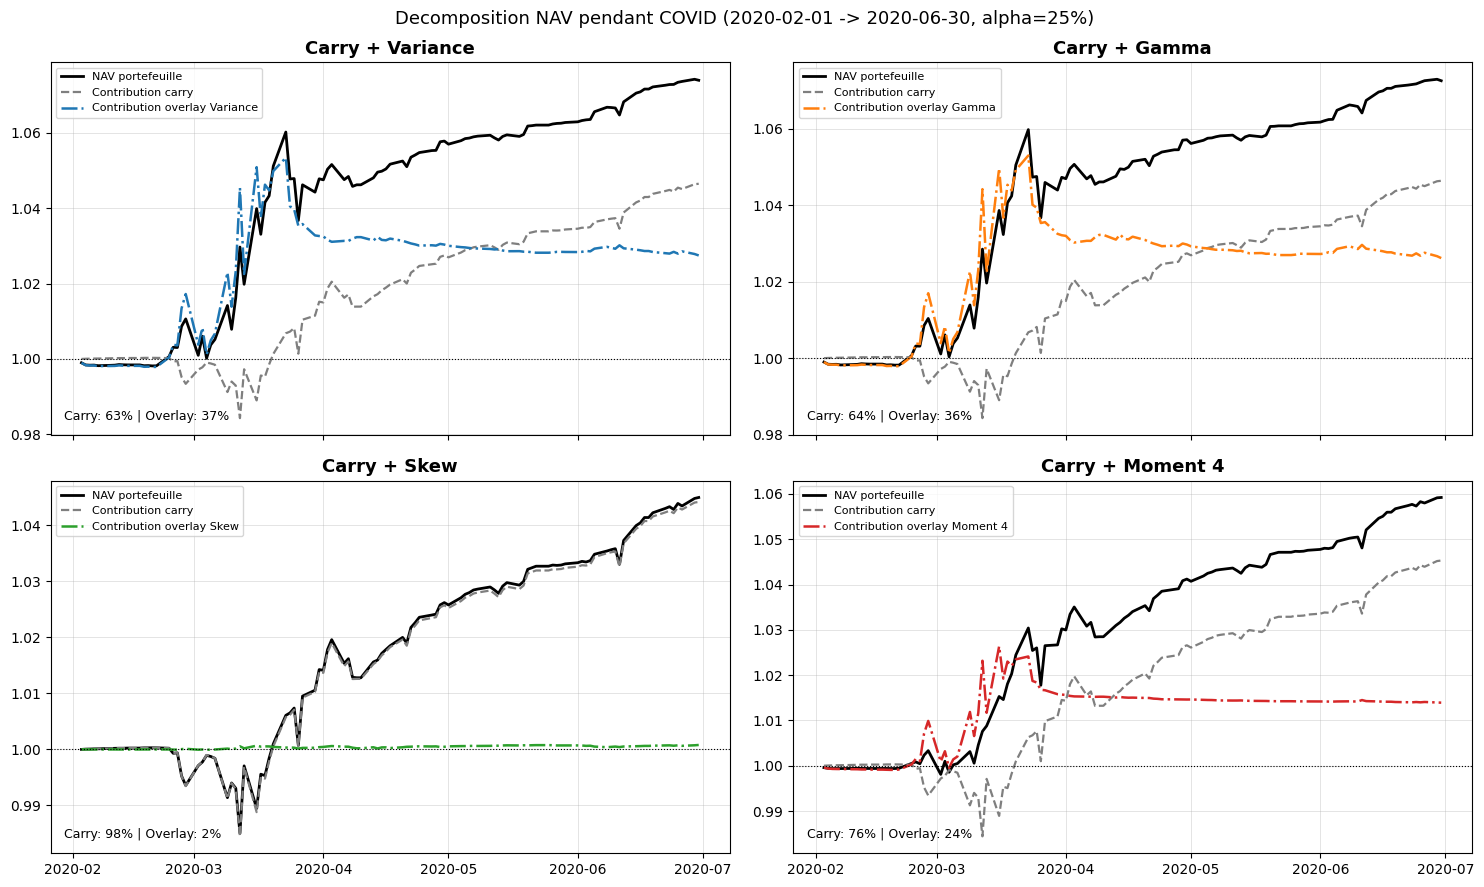

In [22]:
required_objs = ["bt_carry_covid", "bt_nav", "bt_gamma_nav", "nav_skew", "bt_m4"]
missing = [x for x in required_objs if x not in globals()]
if missing:
    raise RuntimeError(f"Run previous cells first (missing: {missing})")
carry_ret = bt_carry_covid.nav["NAV"].pct_change().dropna()
overlays_raw = {
    "Variance": -bt_nav["NAV"].pct_change().dropna(),
    "Gamma":    -bt_gamma_nav["NAV"].pct_change().dropna(),
    "Skew":     -nav_skew.pct_change().dropna(),
    "Moment 4": -bt_m4.nav["NAV"].pct_change().dropna(),
}
carry_ret = carry_ret.loc[(carry_ret.index >= COVID_START) & (carry_ret.index <= COVID_END)]
overlays_raw = {k: v.loc[(v.index >= COVID_START) & (v.index <= COVID_END)] for k, v in overlays_raw.items()}
def _decompose_nav(ret_carry_leg: pd.Series, ret_overlay_leg: pd.Series) -> pd.DataFrame:
    idx = ret_carry_leg.index.intersection(ret_overlay_leg.index)
    rc = ret_carry_leg.reindex(idx).dropna()
    ro = ret_overlay_leg.reindex(idx).dropna()
    idx = rc.index.intersection(ro.index)
    rc = rc.reindex(idx)
    ro = ro.reindex(idx)
    nav = pd.Series(index=idx, dtype=float)
    dnav_c = pd.Series(index=idx, dtype=float)
    dnav_o = pd.Series(index=idx, dtype=float)
    nav_prev = 1.0
    for t in idx:
        dc = nav_prev * rc.loc[t]
        do = nav_prev * ro.loc[t]
        dnav_c.loc[t] = dc
        dnav_o.loc[t] = do
        nav_prev = nav_prev + dc + do
        nav.loc[t] = nav_prev
    out = pd.DataFrame({
        "nav": nav,
        "cum_carry_pnl": dnav_c.cumsum(),
        "cum_overlay_pnl": dnav_o.cumsum(),
    })
    out["cum_total_pnl"] = out["cum_carry_pnl"] + out["cum_overlay_pnl"]
    return out
decomp = {}
for name, ov in overlays_raw.items():
    ret_c_leg = (1 - ALPHA) * carry_ret
    ret_o_leg = ALPHA * ov
    decomp[name] = _decompose_nav(ret_c_leg, ret_o_leg)
colors = {"Variance": "tab:blue", "Gamma": "tab:orange", "Skew": "tab:green", "Moment 4": "tab:red"}
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, (name, d) in zip(axes.flatten(), decomp.items()):
    ax.plot(d.index, d["nav"], color="black", lw=2.0, label="NAV portefeuille")
    ax.plot(d.index, 1.0 + d["cum_carry_pnl"], color="tab:gray", lw=1.6, ls="--", label="Contribution carry")
    ax.plot(d.index, 1.0 + d["cum_overlay_pnl"], color=colors[name], lw=1.8, ls="-.", label=f"Contribution overlay {name}")
    ax.axhline(1.0, color="black", lw=0.8, ls=":")
    ax.set_title(f"Carry + {name}")
    total_pnl = d["cum_total_pnl"].iloc[-1]
    c_fin = d["cum_carry_pnl"].iloc[-1]
    o_fin = d["cum_overlay_pnl"].iloc[-1]
    txt = f"Carry: {100*c_fin/total_pnl:.0f}% | Overlay: {100*o_fin/total_pnl:.0f}%" if abs(total_pnl) > 1e-12 else "Total PnL ~ 0"
    ax.text(0.02, 0.04, txt, transform=ax.transAxes, fontsize=9)
    ax.legend(fontsize=8, loc="best")
fig.suptitle(f"Decomposition NAV pendant COVID ({COVID_START.date()} -> {COVID_END.date()}, alpha={ALPHA:.0%})", fontsize=13)
plt.tight_layout()
plt.show()


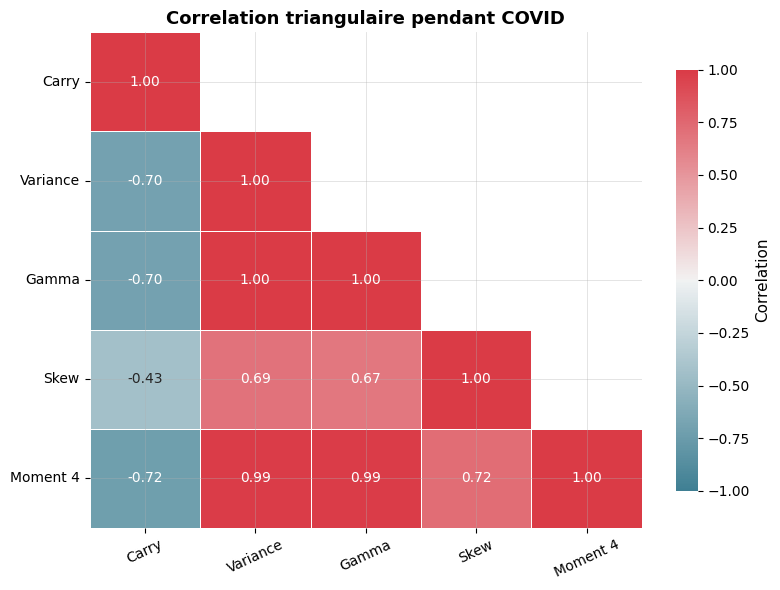

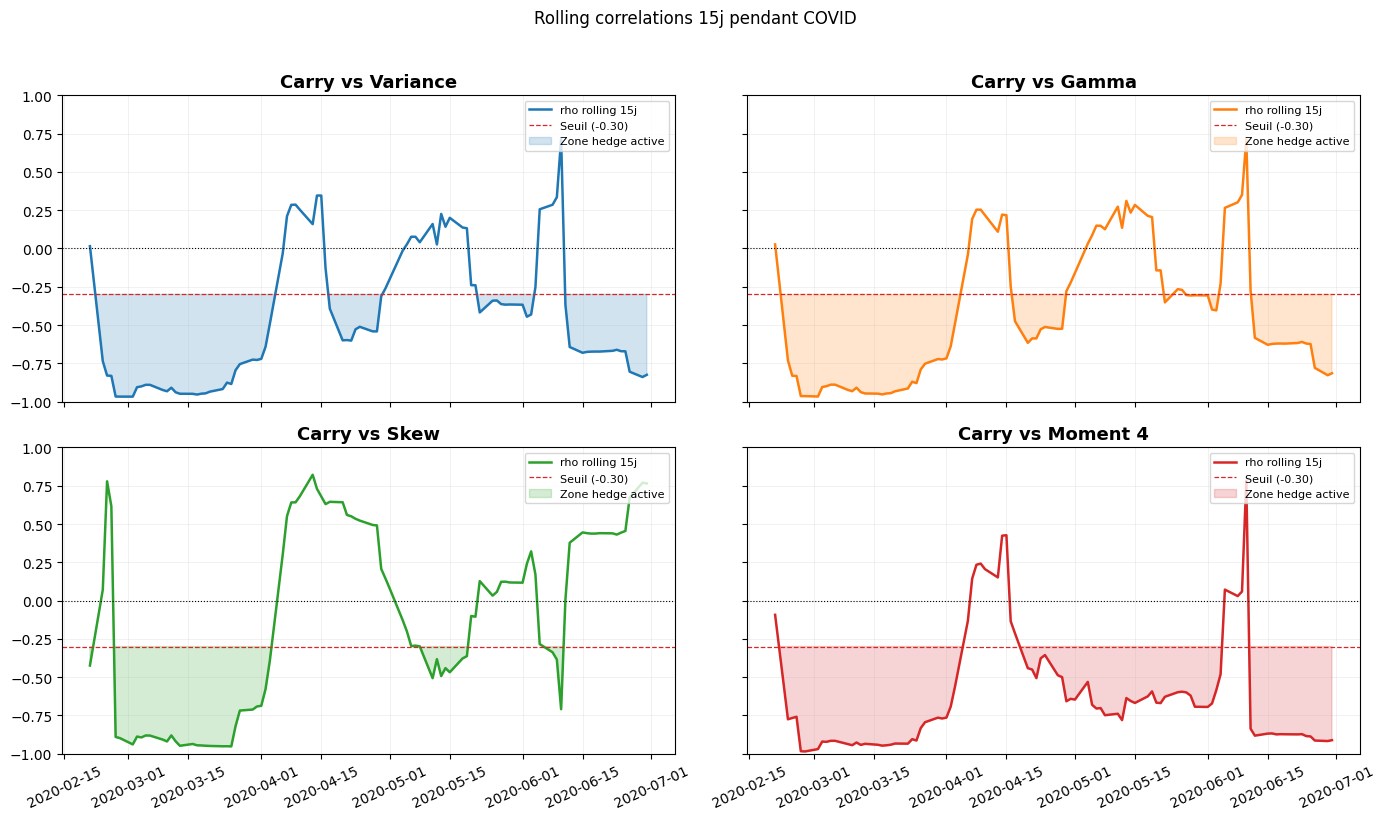

In [23]:
df_corr = pd.DataFrame({
    "Carry":    bt_carry_covid.nav["NAV"].pct_change(),
    "Variance": -bt_nav["NAV"].pct_change(),
    "Gamma":    -bt_gamma_nav["NAV"].pct_change(),
    "Skew":     -nav_skew.pct_change(),
    "Moment 4": -bt_m4.nav["NAV"].pct_change(),
}).dropna()
df_corr = df_corr.loc[(df_corr.index >= COVID_START) & (df_corr.index <= COVID_END)]
corr_covid = df_corr.corr()
mask = np.triu(np.ones_like(corr_covid, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_covid,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation triangulaire pendant COVID")
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()
ROLL_WIN = 15
THRESH = -0.30
pairs = ["Variance", "Gamma", "Skew", "Moment 4"]
colors = {
    "Variance": "tab:blue",
    "Gamma": "tab:orange",
    "Skew": "tab:green",
    "Moment 4": "tab:red",
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i, p in enumerate(pairs):
    ax = axes[i]
    rho = df_corr["Carry"].rolling(ROLL_WIN, min_periods=ROLL_WIN).corr(df_corr[p])
    ax.plot(rho.index, rho.values, lw=1.8, color=colors[p], label=f"rho rolling {ROLL_WIN}j")
    ax.axhline(0.0, color="black", ls=":", lw=0.8)
    ax.axhline(THRESH, color="tab:red", ls="--", lw=0.9, label=f"Seuil ({THRESH:.2f})")
    mask_hedge = rho <= THRESH
    ax.fill_between(
        rho.index,
        rho.values,
        THRESH,
        where=mask_hedge,
        color=colors[p],
        alpha=0.20,
        interpolate=True,
        label="Zone hedge active",
    )
    ax.set_title(f"Carry vs {p}")
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="upper right")
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Rolling correlations 15j pendant COVID", y=1.02)
plt.tight_layout()
plt.show()


<div class="mathjax_process" style="background: linear-gradient(135deg, rgba(245,158,11,0.10), rgba(251,191,36,0.07)); border-left: 4px solid #fbbf24; border-radius: 0 8px 8px 0; padding: 12px 14px; margin: 10px 0 14px 0; color: #fef3c7;">

**Pendant COVID, les overlays longs deviennent des hedges directionnels forts du carry.**

La matrice statique montre une anticorrélation élevée avec le carry :
$\rho(\mathrm{Carry},\mathrm{Variance})\approx-0.70$,
$\rho(\mathrm{Carry},\mathrm{Gamma})\approx-0.70$,
$\rho(\mathrm{Carry},\mathrm{M4})\approx-0.72$,
et plus modérée pour le skew
$\rho(\mathrm{Carry},\mathrm{Skew})\approx-0.43$.
En crise, le carry est pénalisé par la hausse conjointe de variance implicite, convexité et queues ; les overlays longs monétisent précisément ces dimensions, d’où la corrélation négative.

**Variance, Gamma et M4 portent pratiquement le même facteur de stress.**

Les corrélations croisées sont quasi-unitaires :
$\rho(\mathrm{Variance},\mathrm{Gamma})\approx1.00$,
$\rho(\mathrm{Variance},\mathrm{M4})\approx0.99$,
$\rho(\mathrm{Gamma},\mathrm{M4})\approx0.99$.
Conclusion rigoureuse : ces trois overlays sont largement redondants en régime de crise systémique ; les combiner ajoute peu de diversification intra-overlay, même si chacun hedge efficacement le carry.

**Le rolling 15j confirme la conditionnalité temporelle du hedge.**

Les panneaux rolling montrent de longues plages sous le seuil $-0.30$ pour Variance, Gamma et M4 : la couverture est active sur une part importante de la fenêtre COVID. Le Skew passe aussi en zone hedge, mais de manière moins stable et avec des inversions plus fréquentes vers des corrélations proches de zéro ou positives.

**Interprétation portefeuille.**

Sur cet épisode, un hedge de carry peut être obtenu avec Variance/Gamma/M4 indifféremment (choix ensuite dicté par coût, liquidité et contraintes d’exécution). Le Skew reste utile comme exposition spécifique d’asymétrie, mais c’est un hedge moins robuste et moins constant sur horizon court.

</div>
